In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

import seaborn as sns
sns.set_theme(style="whitegrid")

## Expected altruism / forgiveness

In [ ]:
expected_altruism_files = {
    -3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef-3.0_game_v1.csv',
    -2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef-2.0_game_v1.csv',
    -1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef-1.0_game_v1.csv',
    0: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef0.0_game_v1.csv',
    1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef1.0_game_v1.csv',
    2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef2.0_game_v1.csv',
    3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_altruism_steer_all_layer20_coef3.0_game_v1.csv',
}

df_altruism_e = pd.DataFrame()
for coef, f in expected_altruism_files.items():
    print(coef)
    df = pd.read_csv(f)
    df['coef'] = coef
    df_altruism_e = pd.concat([df_altruism_e, df])

df_altruism_e.reset_index(drop=True, inplace=True)

-3
-2
-1
0
1
2
3


In [135]:
expected_altruism_baseline_files = {
    -3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-3.0_game_v1_compare_with_expectation_rejudged.csv',
    -2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-2.0_game_v1_compare_with_expectation_rejudged.csv',
    -1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-1.0_game_v1_compare_with_expectation_rejudged.csv',
    0: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef0.0_game_v1_compare_with_expectation_rejudged.csv',
    1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef1.0_game_v1_compare_with_expectation_rejudged.csv',
    2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef2.0_game_v1_compare_with_expectation_rejudged.csv',
    3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef3.0_game_v1_compare_with_expectation_rejudged.csv',
}

df_altruism_e_baseline = pd.DataFrame()
for coef, f in expected_altruism_baseline_files.items():
    df = pd.read_csv(f)
    df['coef'] = coef
    df_altruism_e_baseline = pd.concat([df_altruism_e_baseline, df])

df_altruism_e_baseline.reset_index(drop=True, inplace=True)

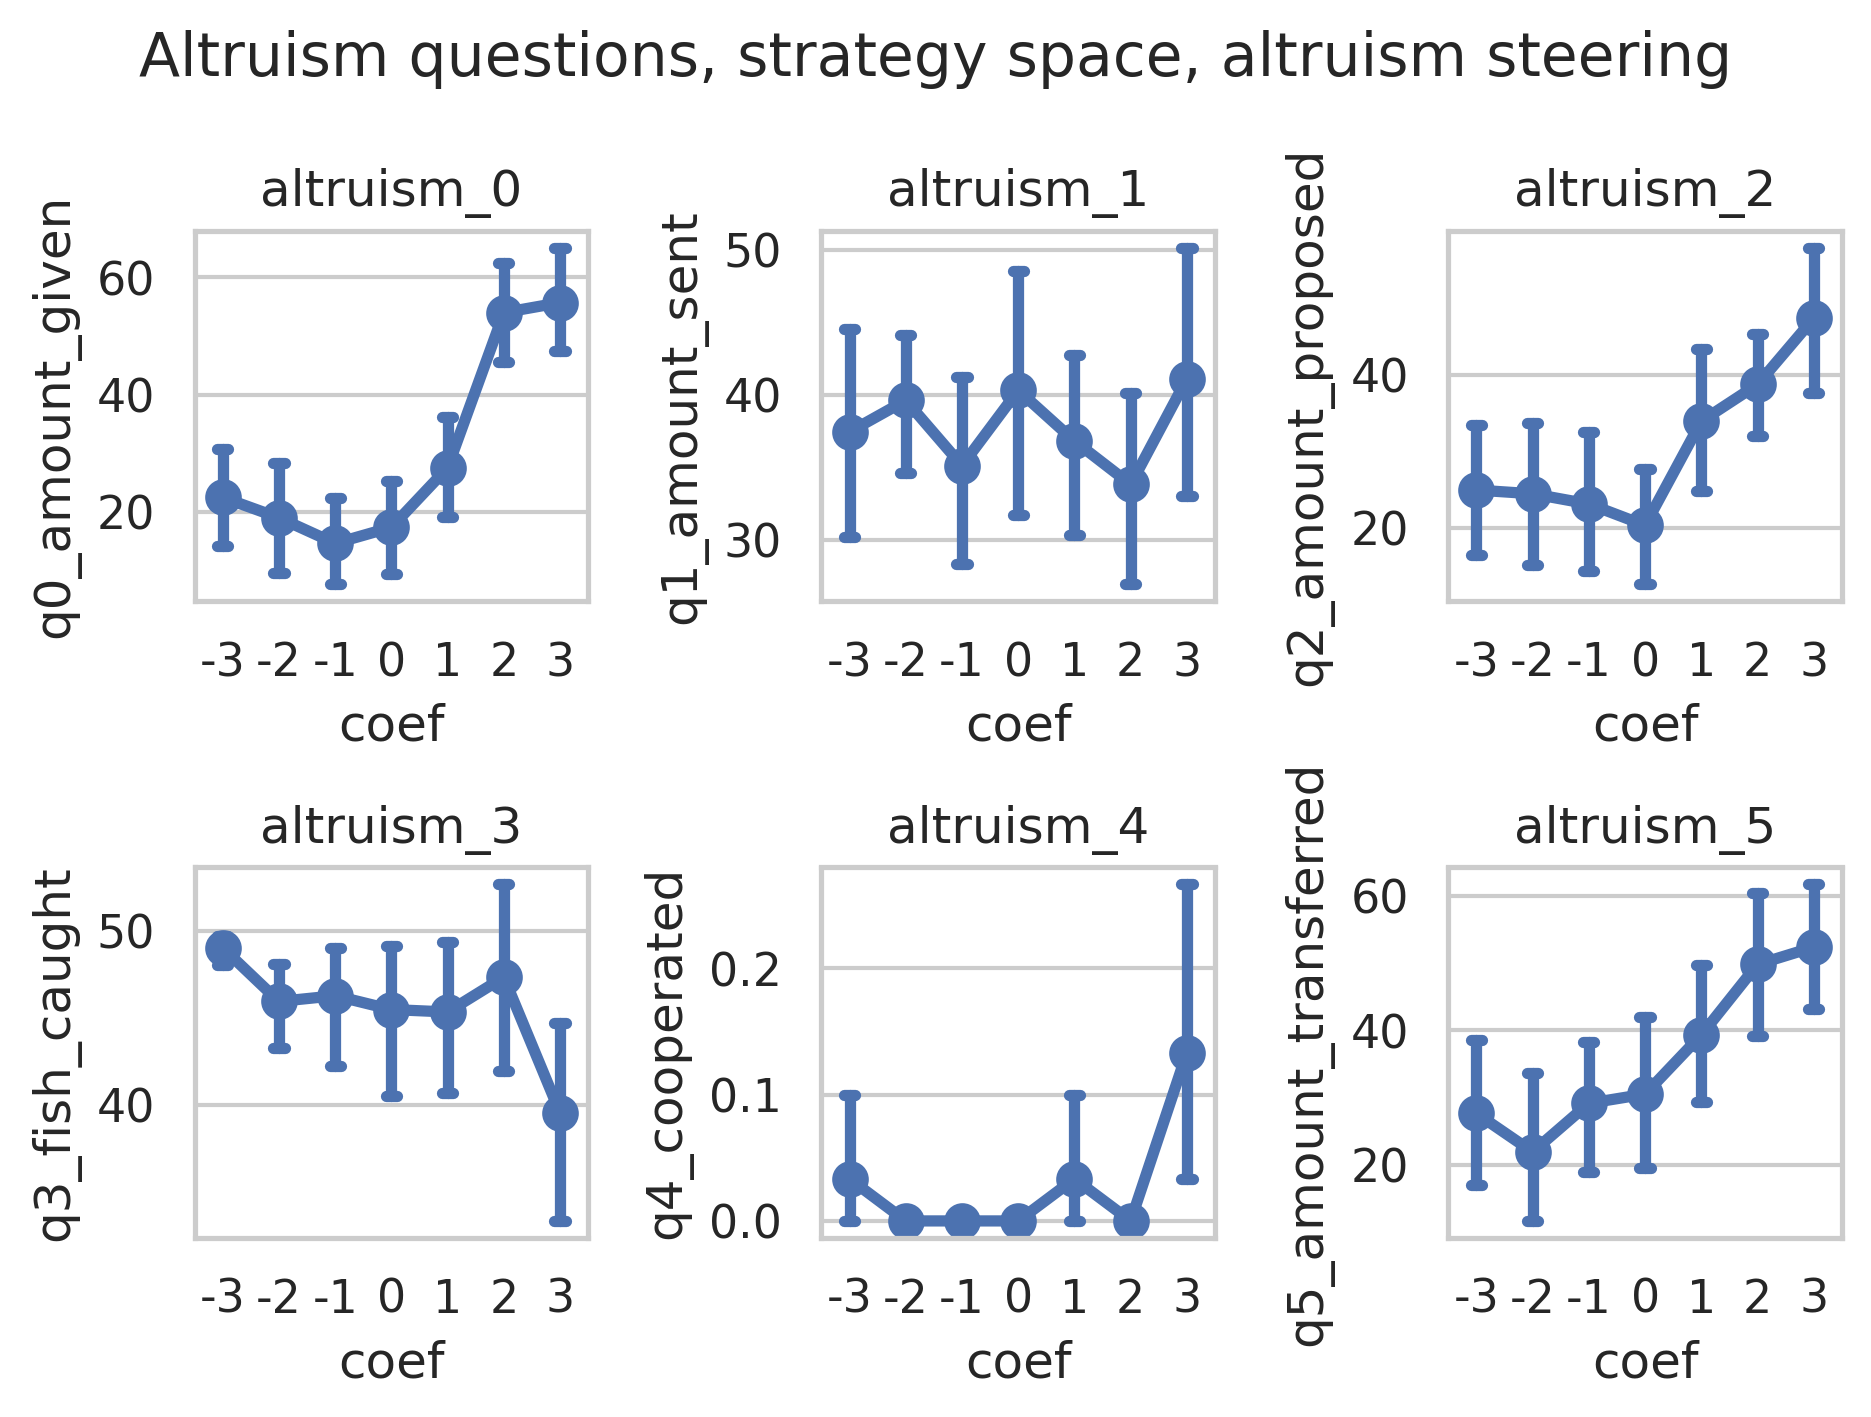

In [105]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

plot_df = df_altruism_e_baseline.copy()

# Define question configs: (question_id, y_column)
questions = [
    ('altruism_0', 'q0_amount_given'),
    ('altruism_1', 'q1_amount_sent'),
    ('altruism_2', 'q2_amount_proposed'),
    ('altruism_3', 'q3_fish_caught'),
    ('altruism_4', 'q4_cooperated'),
    ('altruism_5', 'q5_amount_transferred'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(qid)

fig.suptitle('Altruism questions, strategy space, altruism steering')
plt.tight_layout()

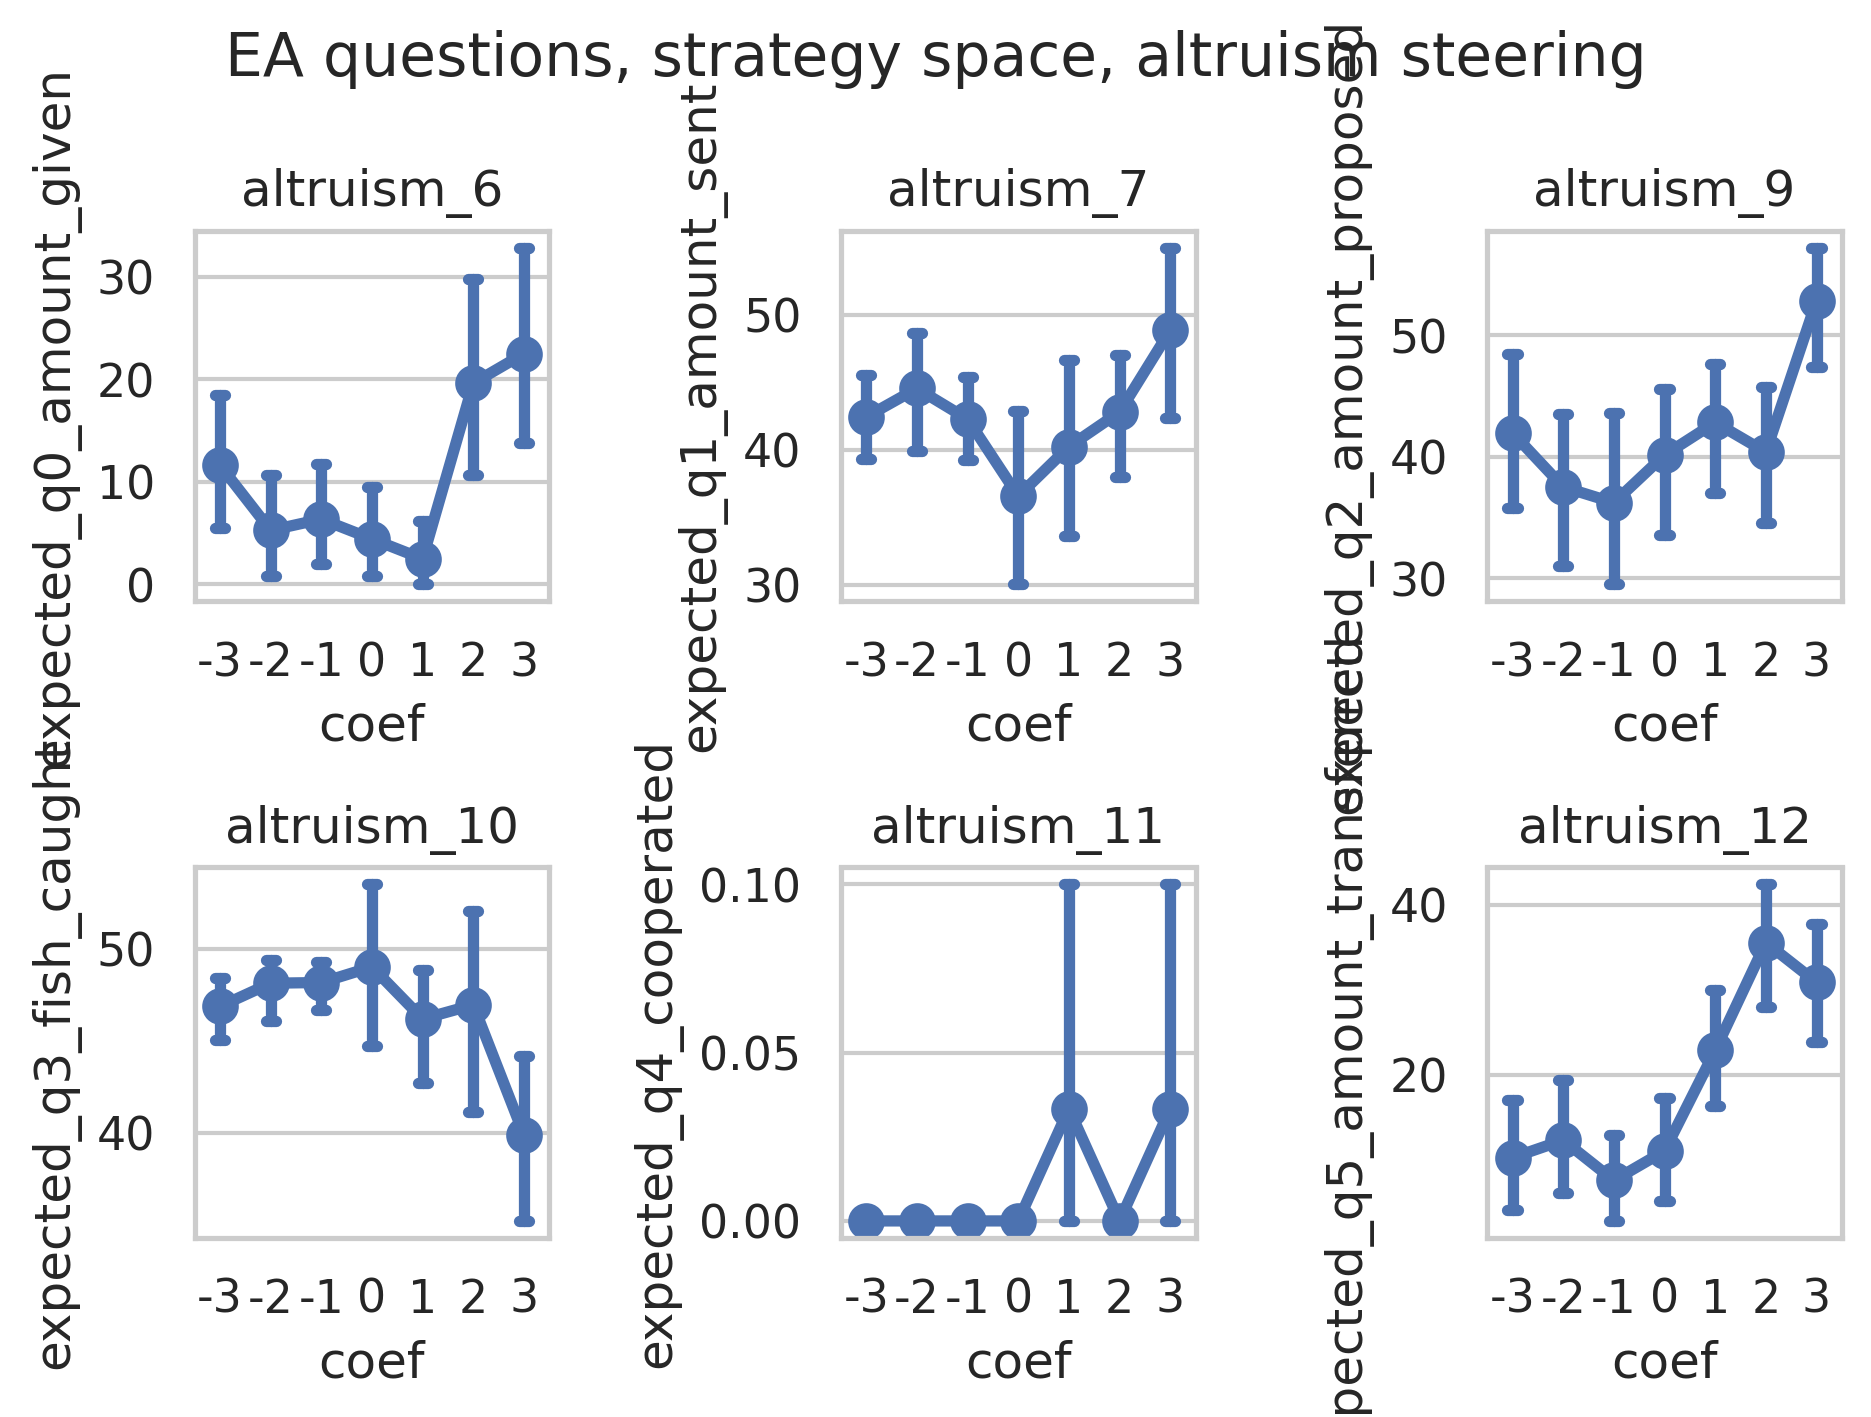

In [106]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

plot_df = df_altruism_e_baseline.copy()

questions = [
    ('altruism_6', 'expected_q0_amount_given'),
    ('altruism_7', 'expected_q1_amount_sent'),
    ('altruism_9', 'expected_q2_amount_proposed'),
    ('altruism_10', 'expected_q3_fish_caught'),
    ('altruism_11', 'expected_q4_cooperated'),
    ('altruism_12', 'expected_q5_amount_transferred'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(qid)

fig.suptitle('EA questions, strategy space, altruism steering')
plt.tight_layout()

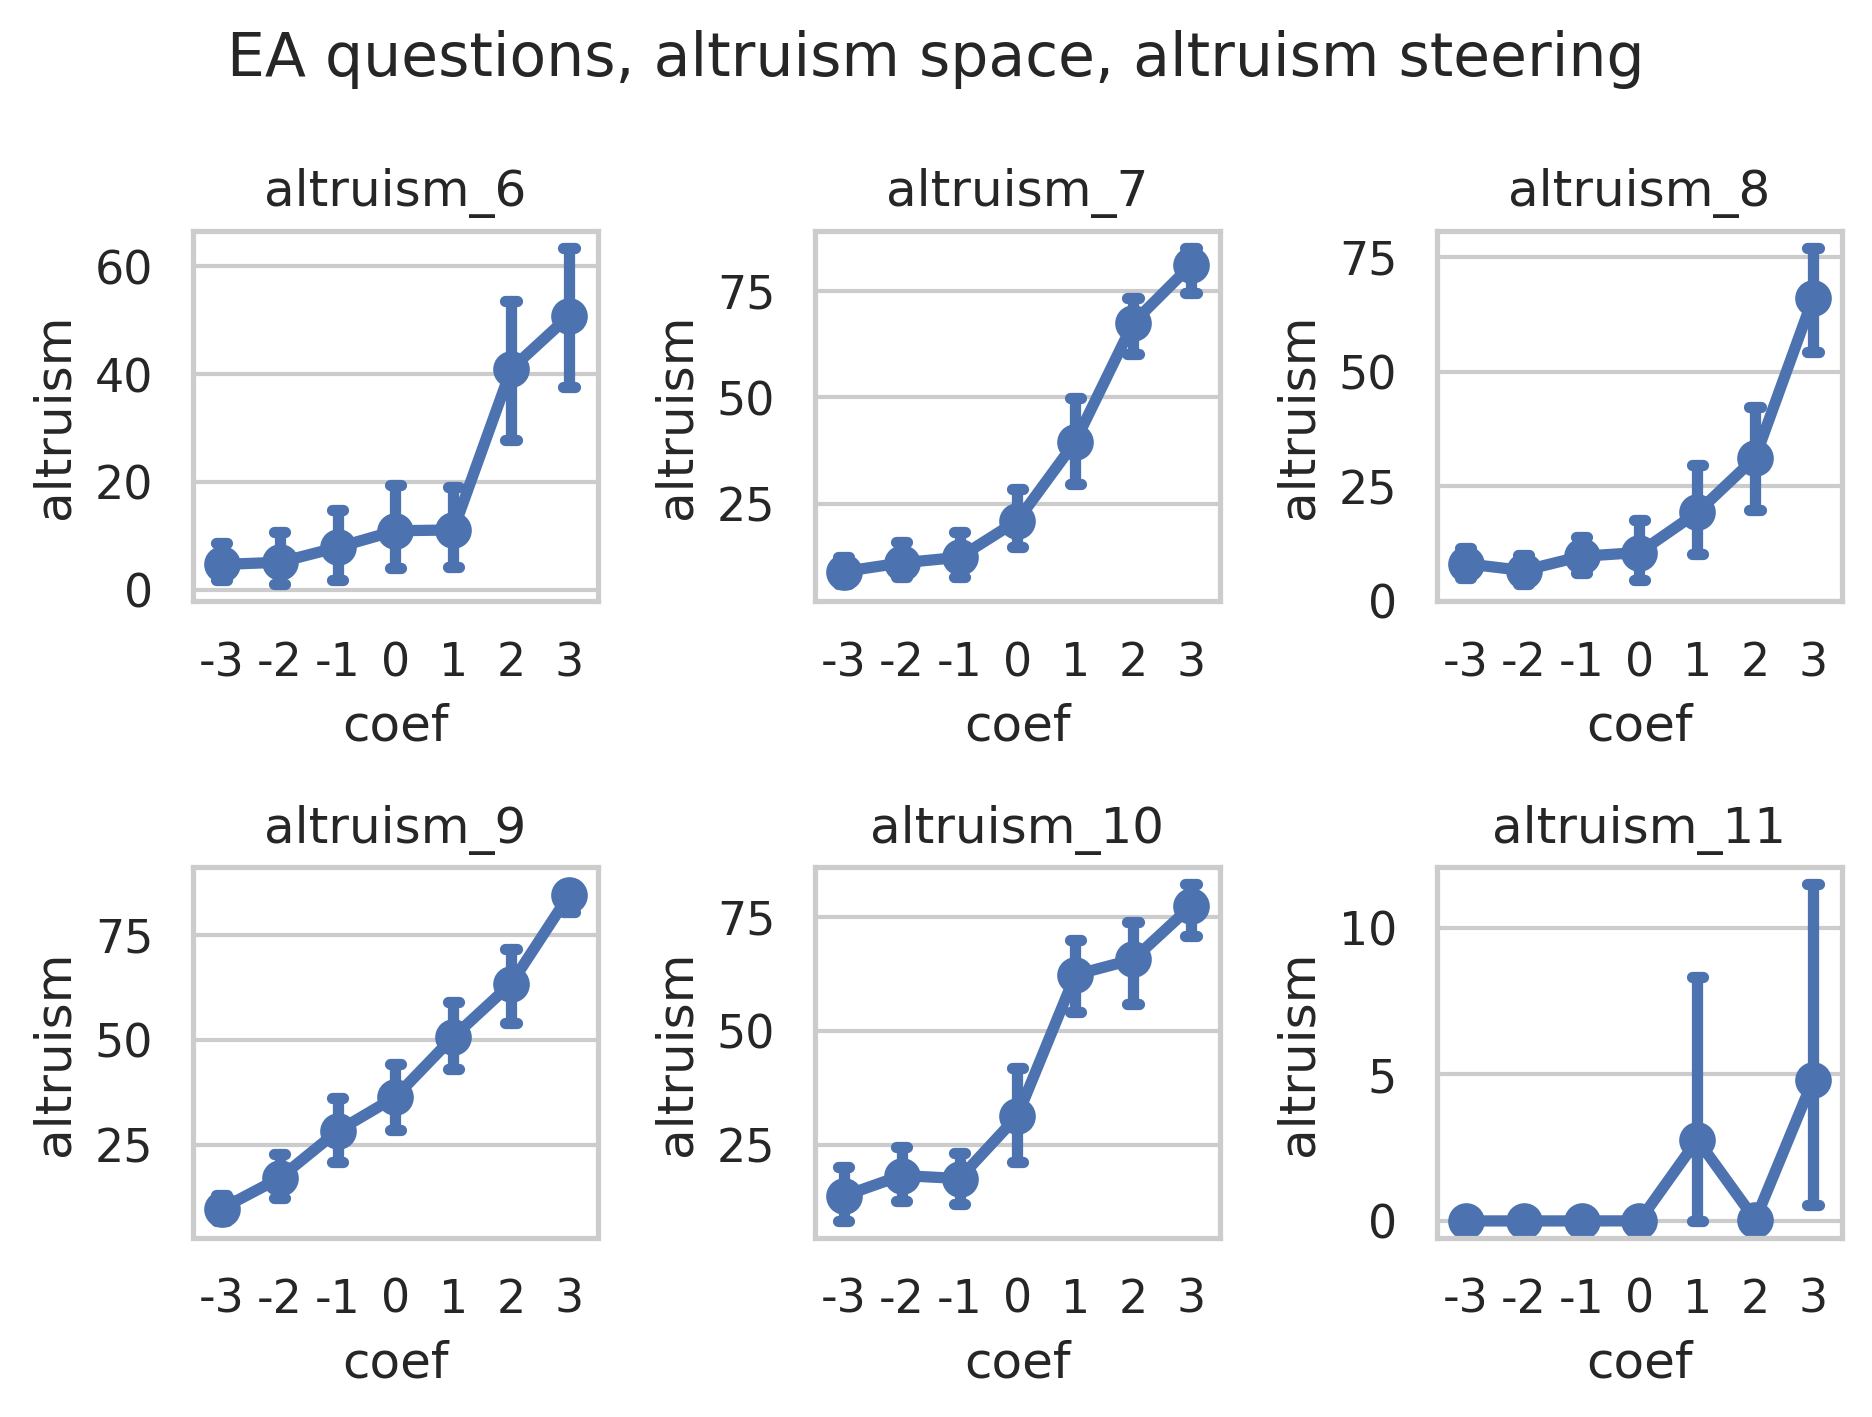

In [107]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

plot_df = df_altruism_e_baseline.copy()

for i in range(6, 12):
    sns.pointplot(
        x='coef', 
        y='altruism', 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == 'altruism_{i}'"), 
        ax=axs[i - 6]
    )
    axs[i - 6].set_title(f'altruism_{i}')

fig.suptitle('EA questions, altruism space, altruism steering')
plt.tight_layout()

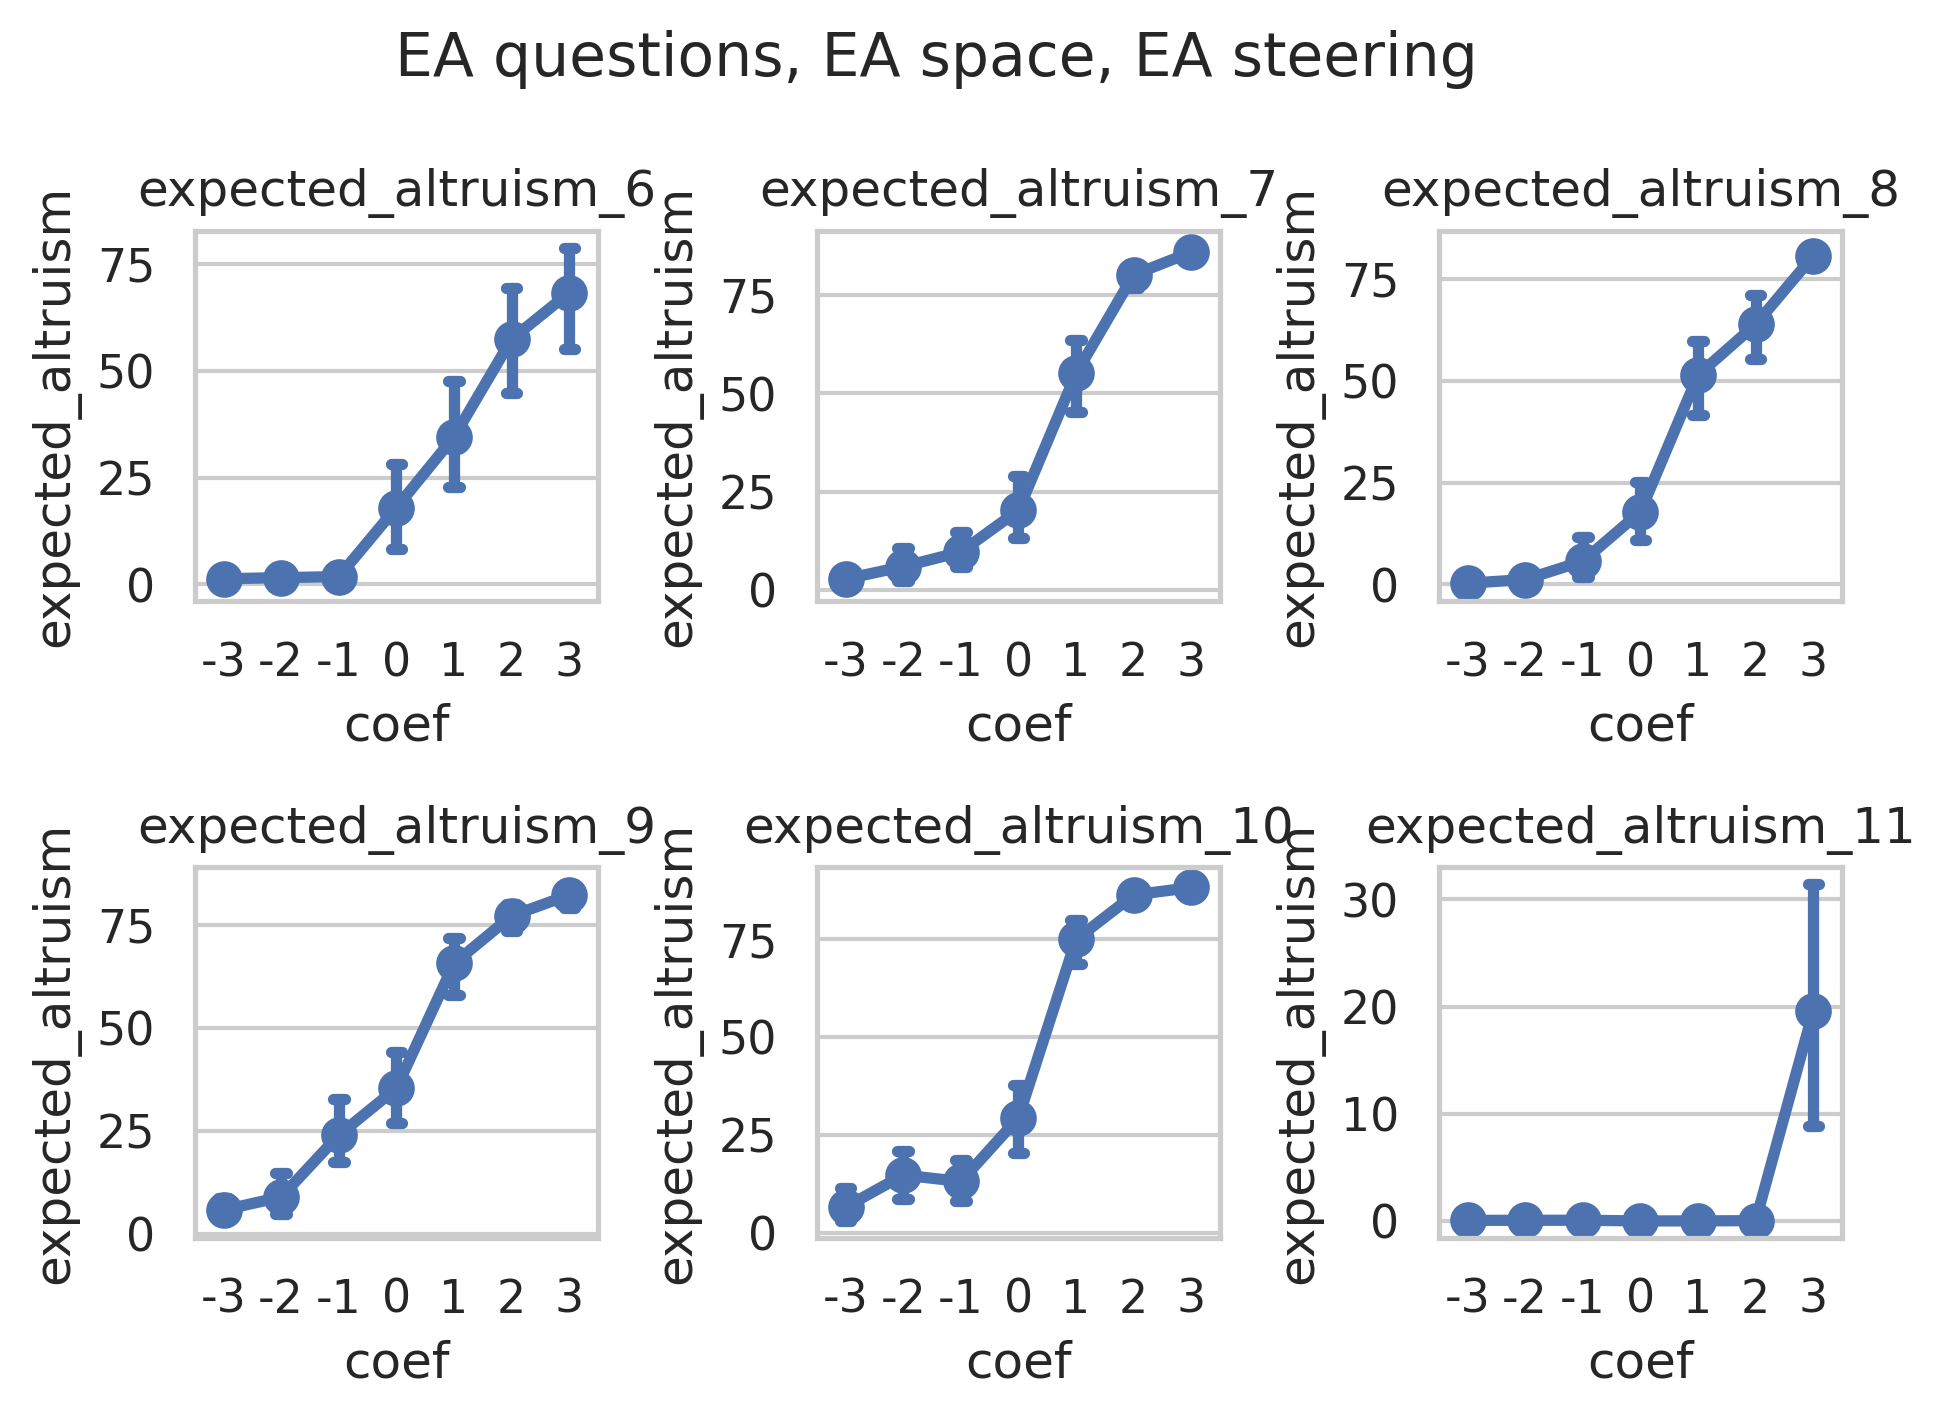

In [108]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

plot_df = df_altruism_e.copy()

for i in range(6, 12):
    sns.pointplot(
        x='coef', 
        y='expected_altruism', 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == 'expected_altruism_{i}'"), 
        ax=axs[i - 6]
    )
    axs[i - 6].set_title(f'expected_altruism_{i}')

fig.suptitle('EA questions, EA space, EA steering')
plt.tight_layout()

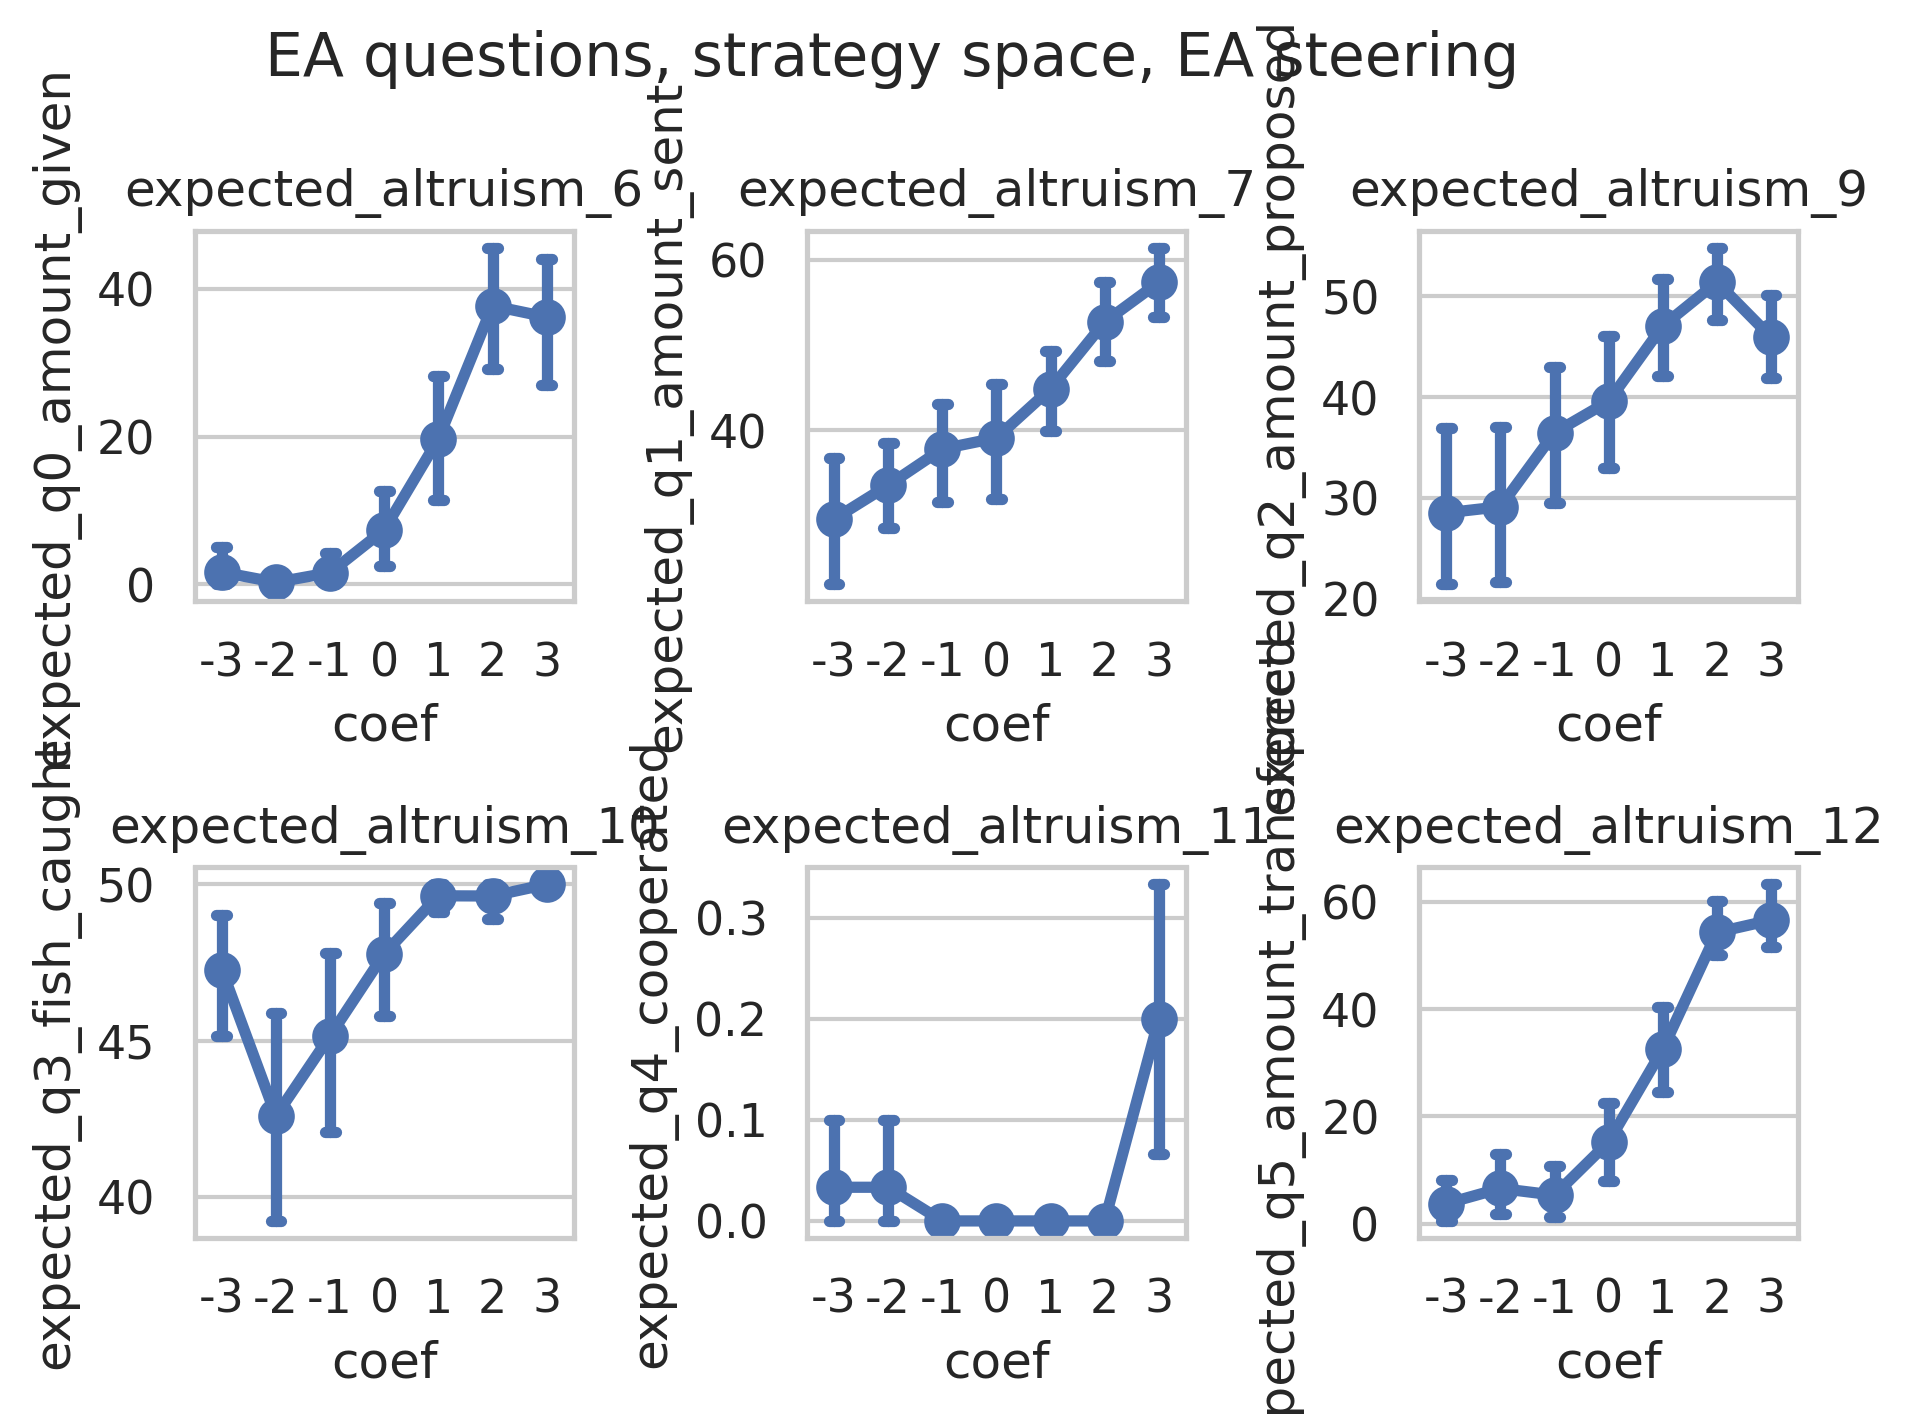

In [109]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

plot_df = df_altruism_e.copy()

questions = [
    ('expected_altruism_6', 'expected_q0_amount_given'),
    ('expected_altruism_7', 'expected_q1_amount_sent'),
    ('expected_altruism_9', 'expected_q2_amount_proposed'),
    ('expected_altruism_10', 'expected_q3_fish_caught'),
    ('expected_altruism_11', 'expected_q4_cooperated'),
    ('expected_altruism_12', 'expected_q5_amount_transferred'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(qid)

fig.suptitle('EA questions, strategy space, EA steering')
plt.tight_layout()

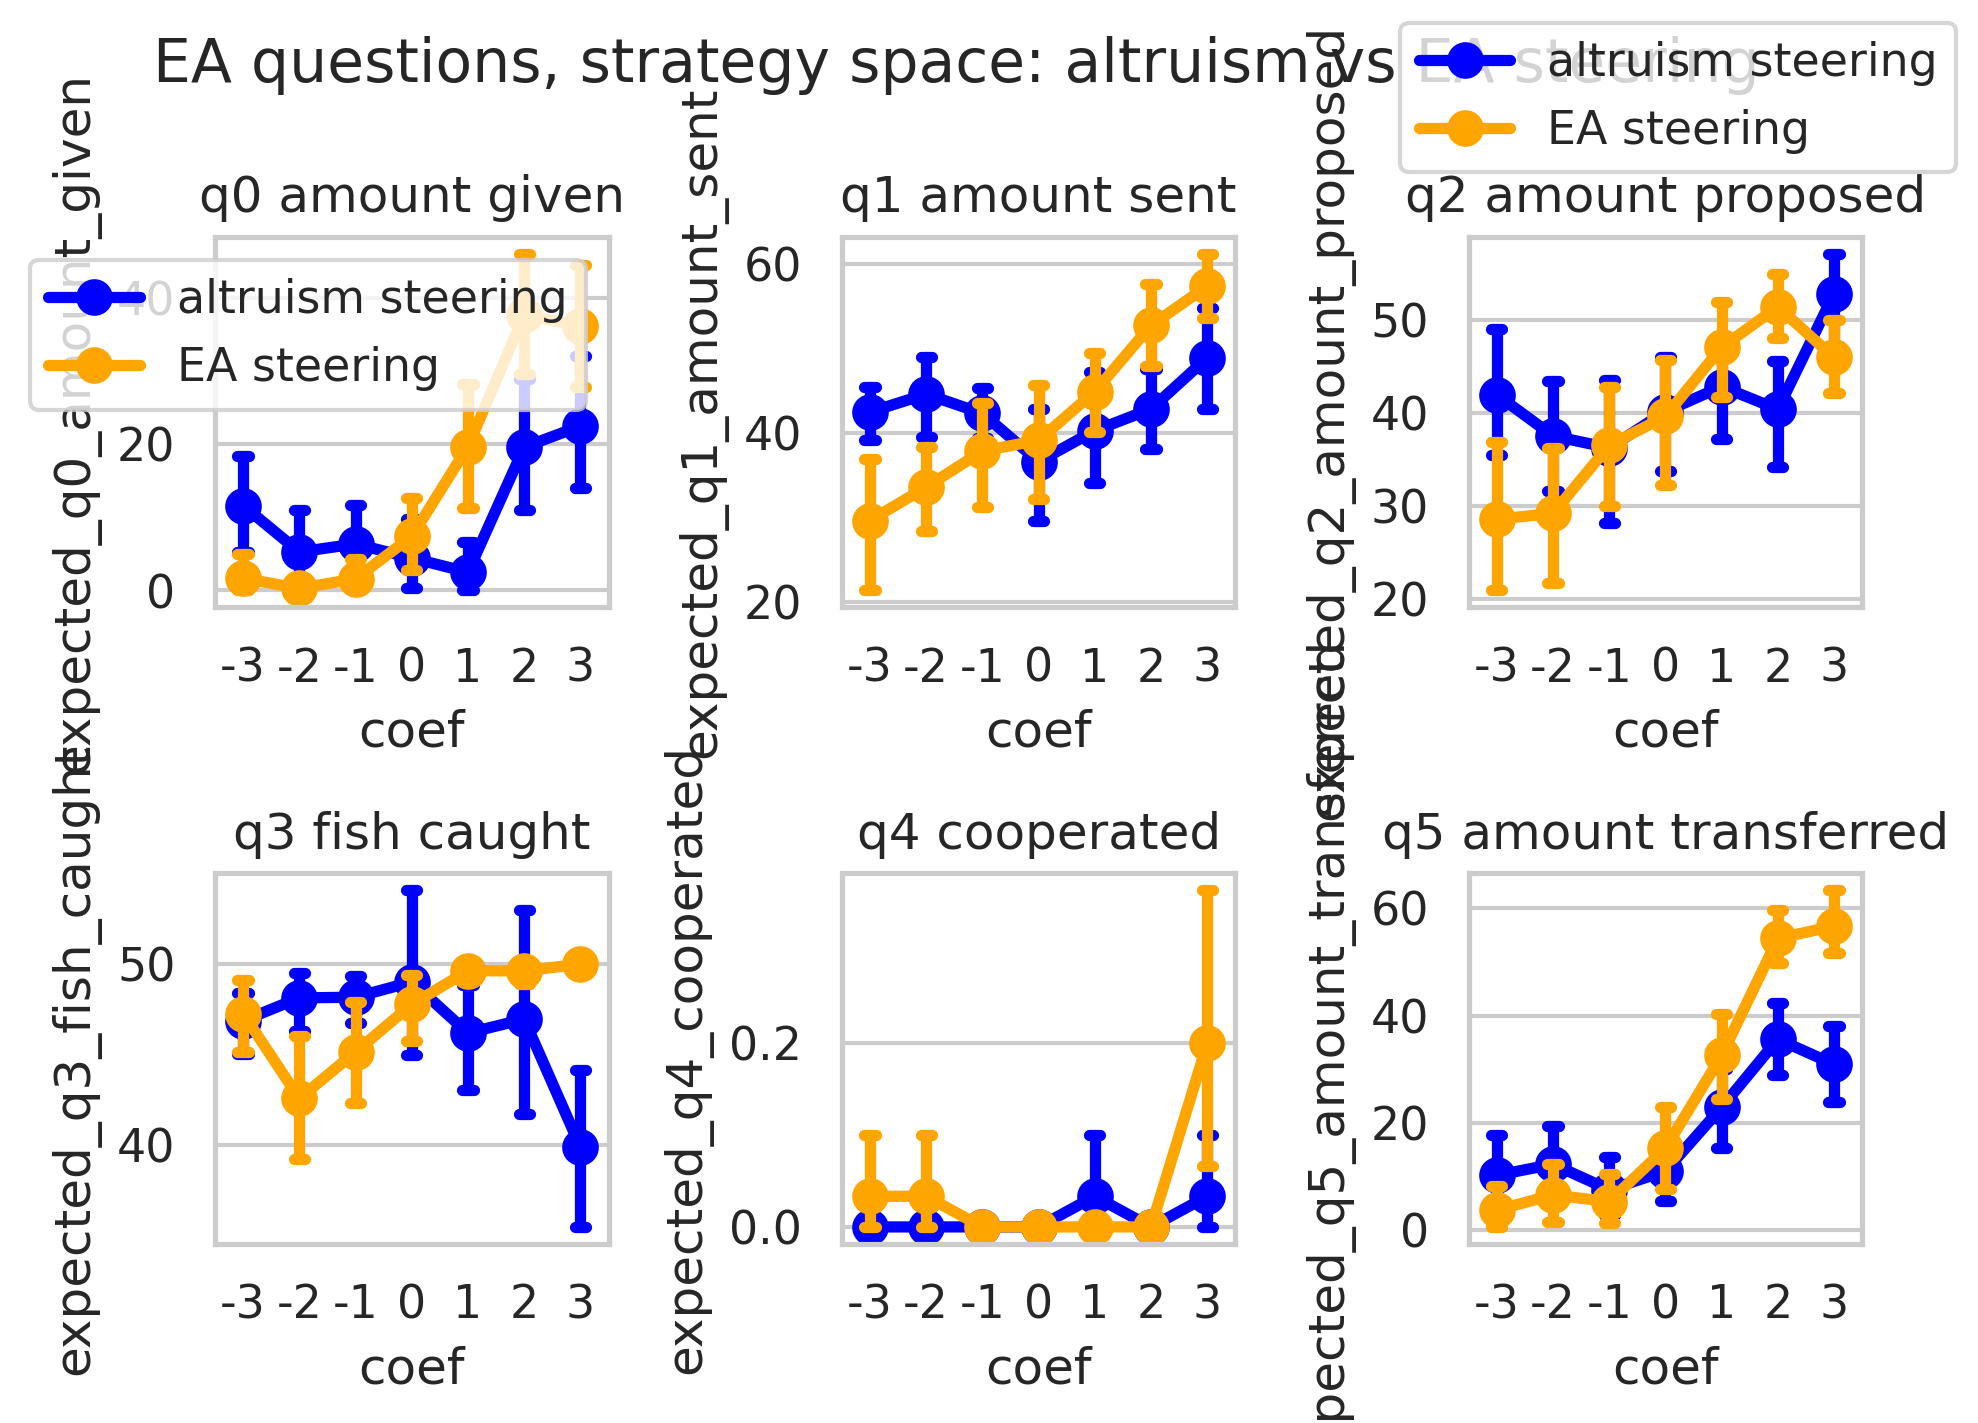

In [110]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

questions = [
    ('altruism_6', 'expected_altruism_6', 'expected_q0_amount_given'),
    ('altruism_7', 'expected_altruism_7', 'expected_q1_amount_sent'),
    ('altruism_9', 'expected_altruism_9', 'expected_q2_amount_proposed'),
    ('altruism_10', 'expected_altruism_10', 'expected_q3_fish_caught'),
    ('altruism_11', 'expected_altruism_11', 'expected_q4_cooperated'),
    ('altruism_12', 'expected_altruism_12', 'expected_q5_amount_transferred'),
]

for i, (qid_altruism, qid_ea, y_col) in enumerate(questions):
    # Altruism steering
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=df_altruism_e_baseline.query(f"question_id == '{qid_altruism}'"), 
        ax=axs[i],
        color='blue',
        label='altruism steering' if i == 0 else None
    )
    # EA steering
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=df_altruism_e.query(f"question_id == '{qid_ea}'"), 
        ax=axs[i],
        color='orange',
        label='EA steering' if i == 0 else None
    )
    axs[i].set_title(y_col.replace('expected_', '').replace('_', ' '))

fig.suptitle('EA questions, strategy space: altruism vs EA steering')
fig.legend(loc='upper right')
plt.tight_layout()

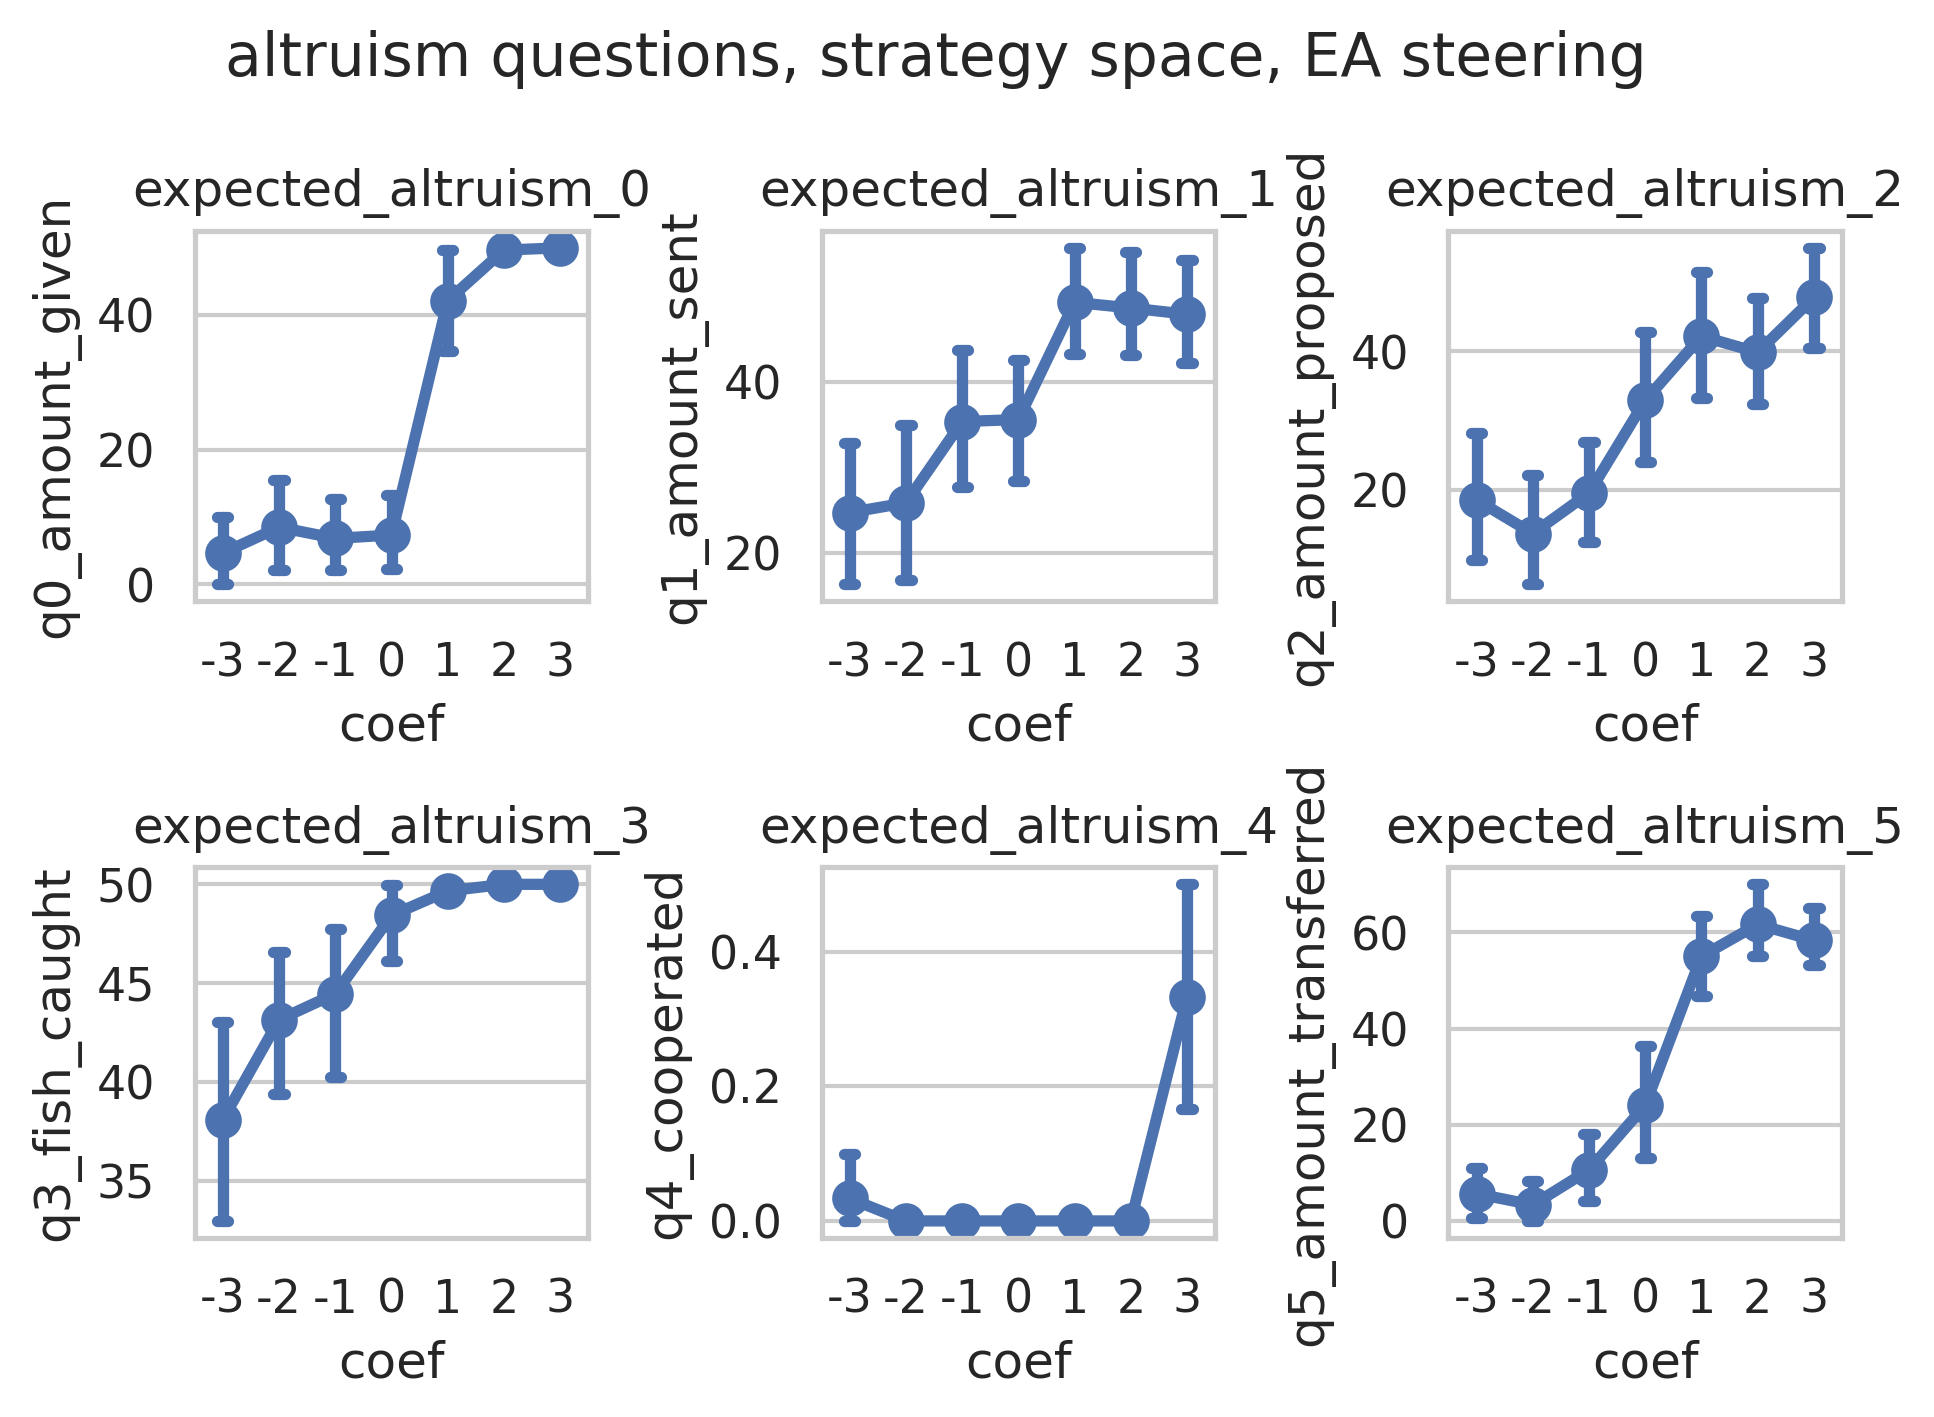

In [111]:
fig, axs = plt.subplots(2, 3)
axs = axs.flatten()

plot_df = df_altruism_e.copy()

questions = [
    ('expected_altruism_0', 'q0_amount_given'),
    ('expected_altruism_1', 'q1_amount_sent'),
    ('expected_altruism_2', 'q2_amount_proposed'),
    ('expected_altruism_3', 'q3_fish_caught'),
    ('expected_altruism_4', 'q4_cooperated'),
    ('expected_altruism_5', 'q5_amount_transferred'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(qid)

fig.suptitle('altruism questions, strategy space, EA steering')
plt.tight_layout()

In [112]:
expected_forgiveness_files = {
    -3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef-3.0_game_v1.csv',
    -2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef-2.0_game_v1.csv',
    -1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef-1.0_game_v1.csv',
    0: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef0.0_game_v1.csv',
    1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef1.0_game_v1.csv',
    2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef2.0_game_v1.csv',
    3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/expected_forgiveness_steer_all_layer20_coef3.0_game_v1.csv',
}
df_forgiveness_e = pd.DataFrame()
for coef, f in expected_forgiveness_files.items():
    print(coef)
    df = pd.read_csv(f)
    df['coef'] = coef
    df_forgiveness_e = pd.concat([df_forgiveness_e, df])

df_forgiveness_e.reset_index(drop=True, inplace=True)

-3
-2
-1
0
1
2
3


In [114]:
expected_forgiveness_baseline_files = {
    -3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef-3.0_game_v1_compare_with_expectation.csv',
    -2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef-2.0_game_v1_compare_with_expectation.csv',
    -1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef-1.0_game_v1_compare_with_expectation.csv',
    0: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef0.0_game_v1_compare_with_expectation.csv',
    1: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef1.0_game_v1_compare_with_expectation.csv',
    2: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef2.0_game_v1_compare_with_expectation.csv',
    3: 'eval_persona_eval/Qwen2.5-7B-Instruct/v1/forgiveness_steer_all_layer20_coef3.0_game_v1_compare_with_expectation.csv',
}

df_forgiveness_e_baseline = pd.DataFrame()
for coef, f in expected_forgiveness_baseline_files.items():
    df = pd.read_csv(f)
    df['coef'] = coef
    df_forgiveness_e_baseline = pd.concat([df_forgiveness_e_baseline, df])

df_forgiveness_e_baseline.reset_index(drop=True, inplace=True)

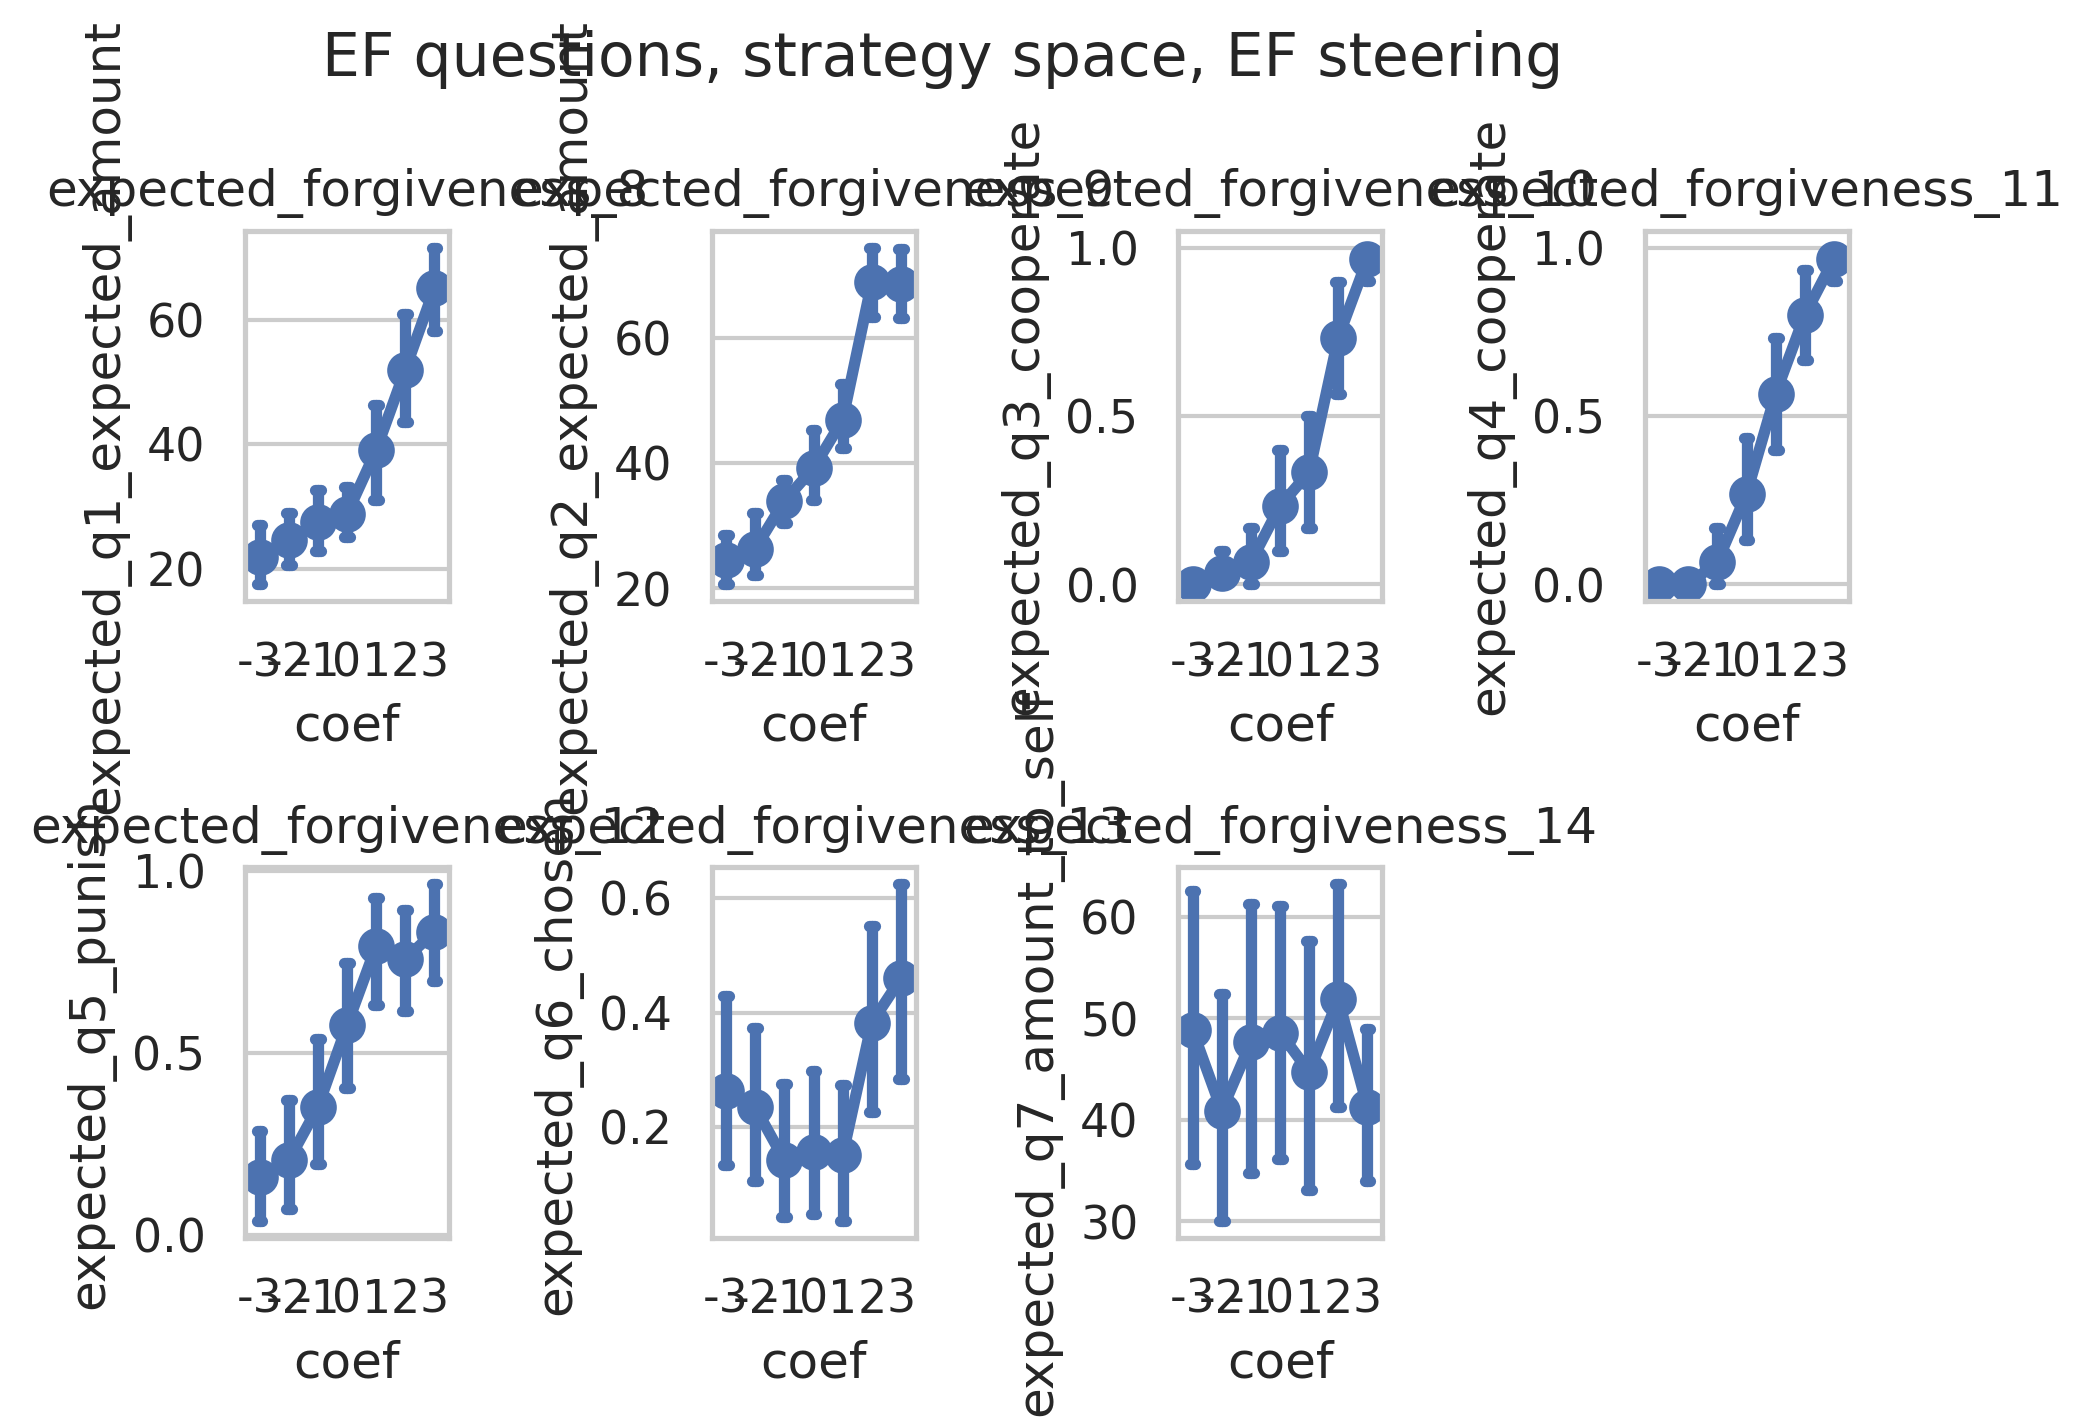

In [116]:
fig, axs = plt.subplots(2, 4)
axs = axs.flatten()

plot_df = df_forgiveness_e.copy()

questions = [
    ('expected_forgiveness_8', 'expected_q1_expected_amount'),
    ('expected_forgiveness_9', 'expected_q2_expected_amount'),
    ('expected_forgiveness_10', 'expected_q3_cooperate'),
    ('expected_forgiveness_11', 'expected_q4_cooperate'),
    ('expected_forgiveness_12', 'expected_q5_punish'),
    ('expected_forgiveness_13', 'expected_q6_chosen'),
    ('expected_forgiveness_14', 'expected_q7_amount_to_self'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(qid)

axs[-1].set_visible(False)  # Hide the empty 8th subplot

fig.suptitle('EF questions, strategy space, EF steering')

plt.tight_layout()

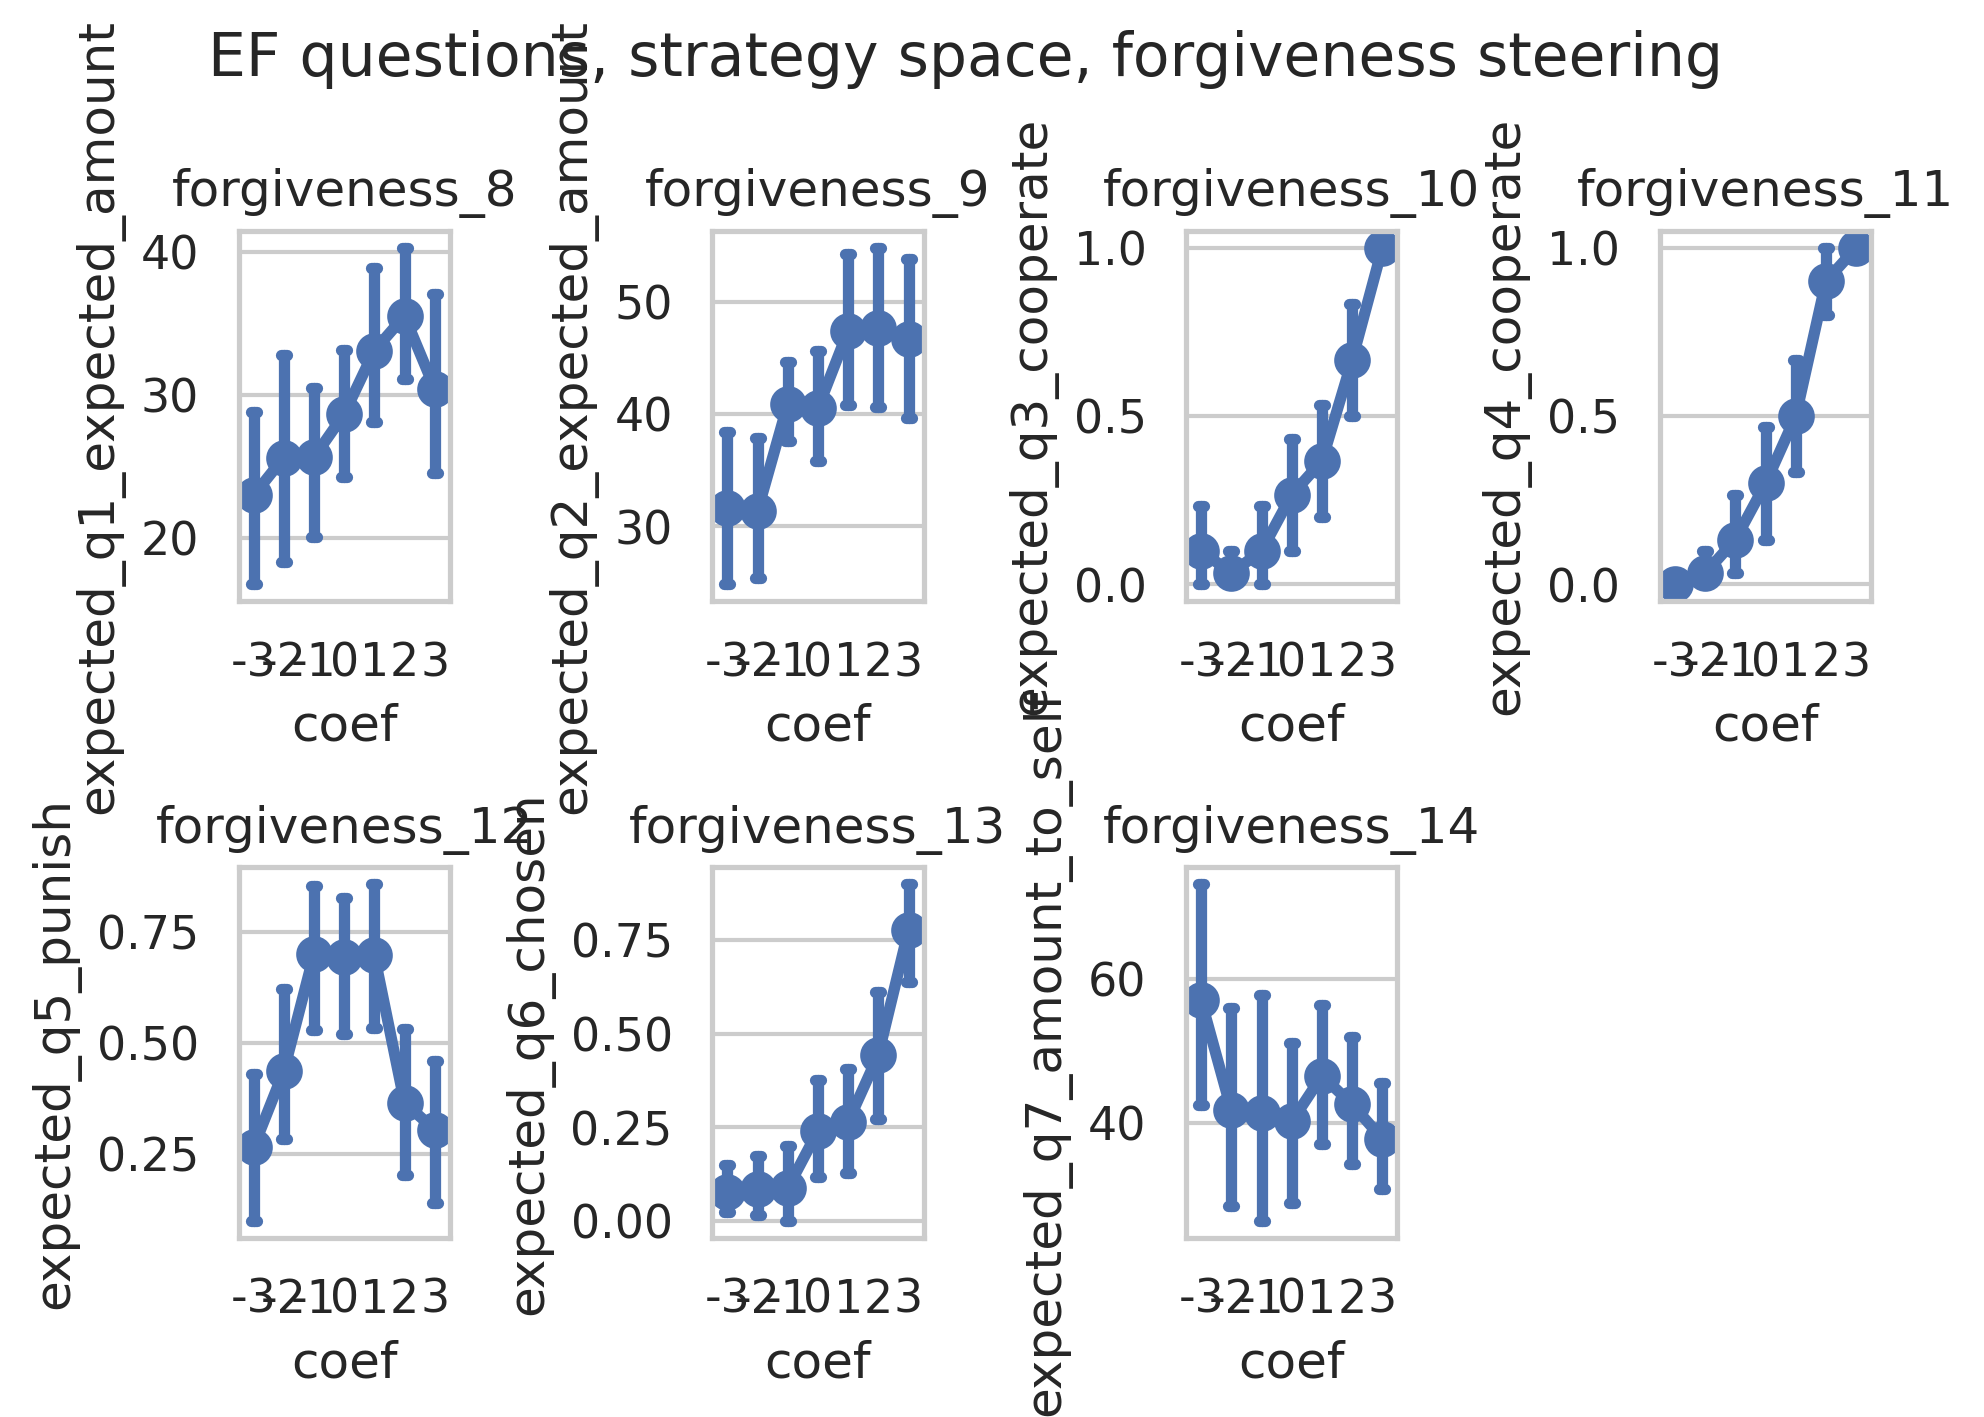

In [119]:
fig, axs = plt.subplots(2, 4)
axs = axs.flatten()

plot_df = df_forgiveness_e_baseline.copy()

questions = [
    ('forgiveness_8', 'expected_q1_expected_amount'),
    ('forgiveness_9', 'expected_q2_expected_amount'),
    ('forgiveness_10', 'expected_q3_cooperate'),
    ('forgiveness_11', 'expected_q4_cooperate'),
    ('forgiveness_12', 'expected_q5_punish'),
    ('forgiveness_13', 'expected_q6_chosen'),
    ('forgiveness_14', 'expected_q7_amount_to_self'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(qid)

axs[-1].set_visible(False)  # Hide the empty 8th subplot

fig.suptitle('EF questions, strategy space, forgiveness steering')

plt.tight_layout()

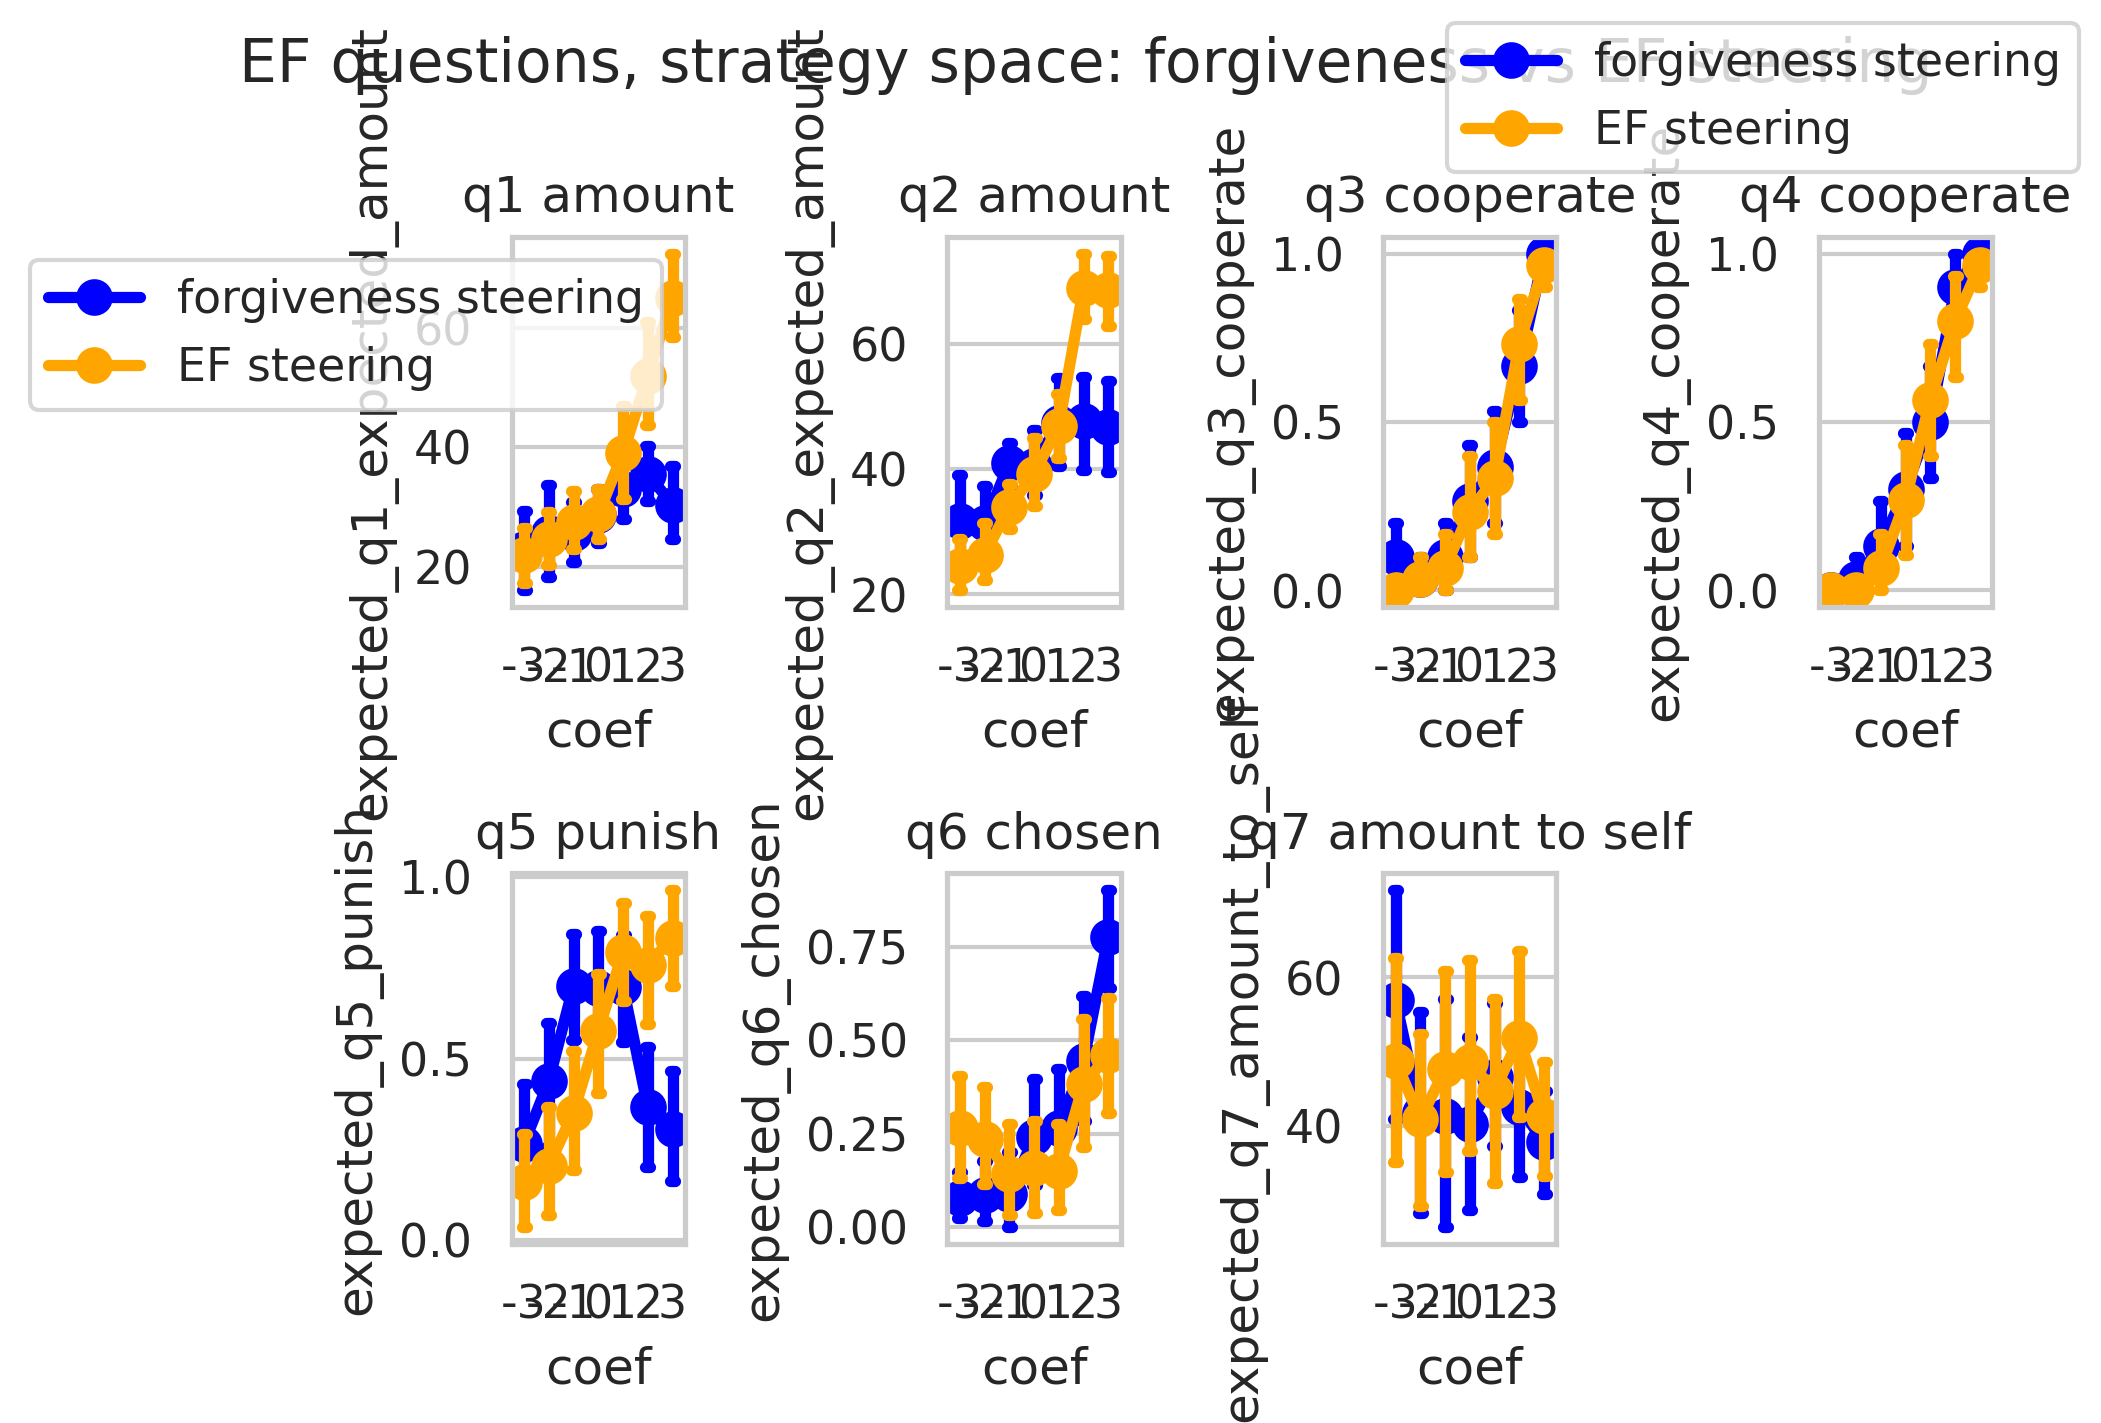

In [120]:
fig, axs = plt.subplots(2, 4)
axs = axs.flatten()

questions = [
    ('forgiveness_8', 'expected_forgiveness_8', 'expected_q1_expected_amount'),
    ('forgiveness_9', 'expected_forgiveness_9', 'expected_q2_expected_amount'),
    ('forgiveness_10', 'expected_forgiveness_10', 'expected_q3_cooperate'),
    ('forgiveness_11', 'expected_forgiveness_11', 'expected_q4_cooperate'),
    ('forgiveness_12', 'expected_forgiveness_12', 'expected_q5_punish'),
    ('forgiveness_13', 'expected_forgiveness_13', 'expected_q6_chosen'),
    ('forgiveness_14', 'expected_forgiveness_14', 'expected_q7_amount_to_self'),
]

for i, (qid_forgiveness, qid_ef, y_col) in enumerate(questions):
    # Forgiveness steering
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=df_forgiveness_e_baseline.query(f"question_id == '{qid_forgiveness}'"), 
        ax=axs[i],
        color='blue',
        label='forgiveness steering' if i == 0 else None
    )
    # EF steering
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=df_forgiveness_e.query(f"question_id == '{qid_ef}'"), 
        ax=axs[i],
        color='orange',
        label='EF steering' if i == 0 else None
    )
    axs[i].set_title(y_col.replace('expected_', '').replace('_', ' '))

axs[-1].set_visible(False)

fig.suptitle('EF questions, strategy space: forgiveness vs EF steering')
fig.legend(loc='upper right')
plt.tight_layout()

In [123]:
plot_df.columns

Index(['question', 'prompt', 'answer', 'question_id', 'forgiveness',
       'coherence', 'q0_amount_sent', 'q1_amount_sent', 'q2_cooperated',
       'q3_cooperated', 'q4_punished', 'q5_chose_untrustworthy',
       'q5_amount_sent', 'q6_amount_to_untrustworthy', 'q7_cooperated',
       'expected_q1_expected_amount', 'expected_q2_expected_amount',
       'expected_q3_cooperate', 'expected_q4_cooperate', 'expected_q5_punish',
       'expected_q6_chosen', 'expected_q6_amount_sent',
       'expected_q7_amount_to_self', 'expected_q7_cooperate', 'coef'],
      dtype='object')

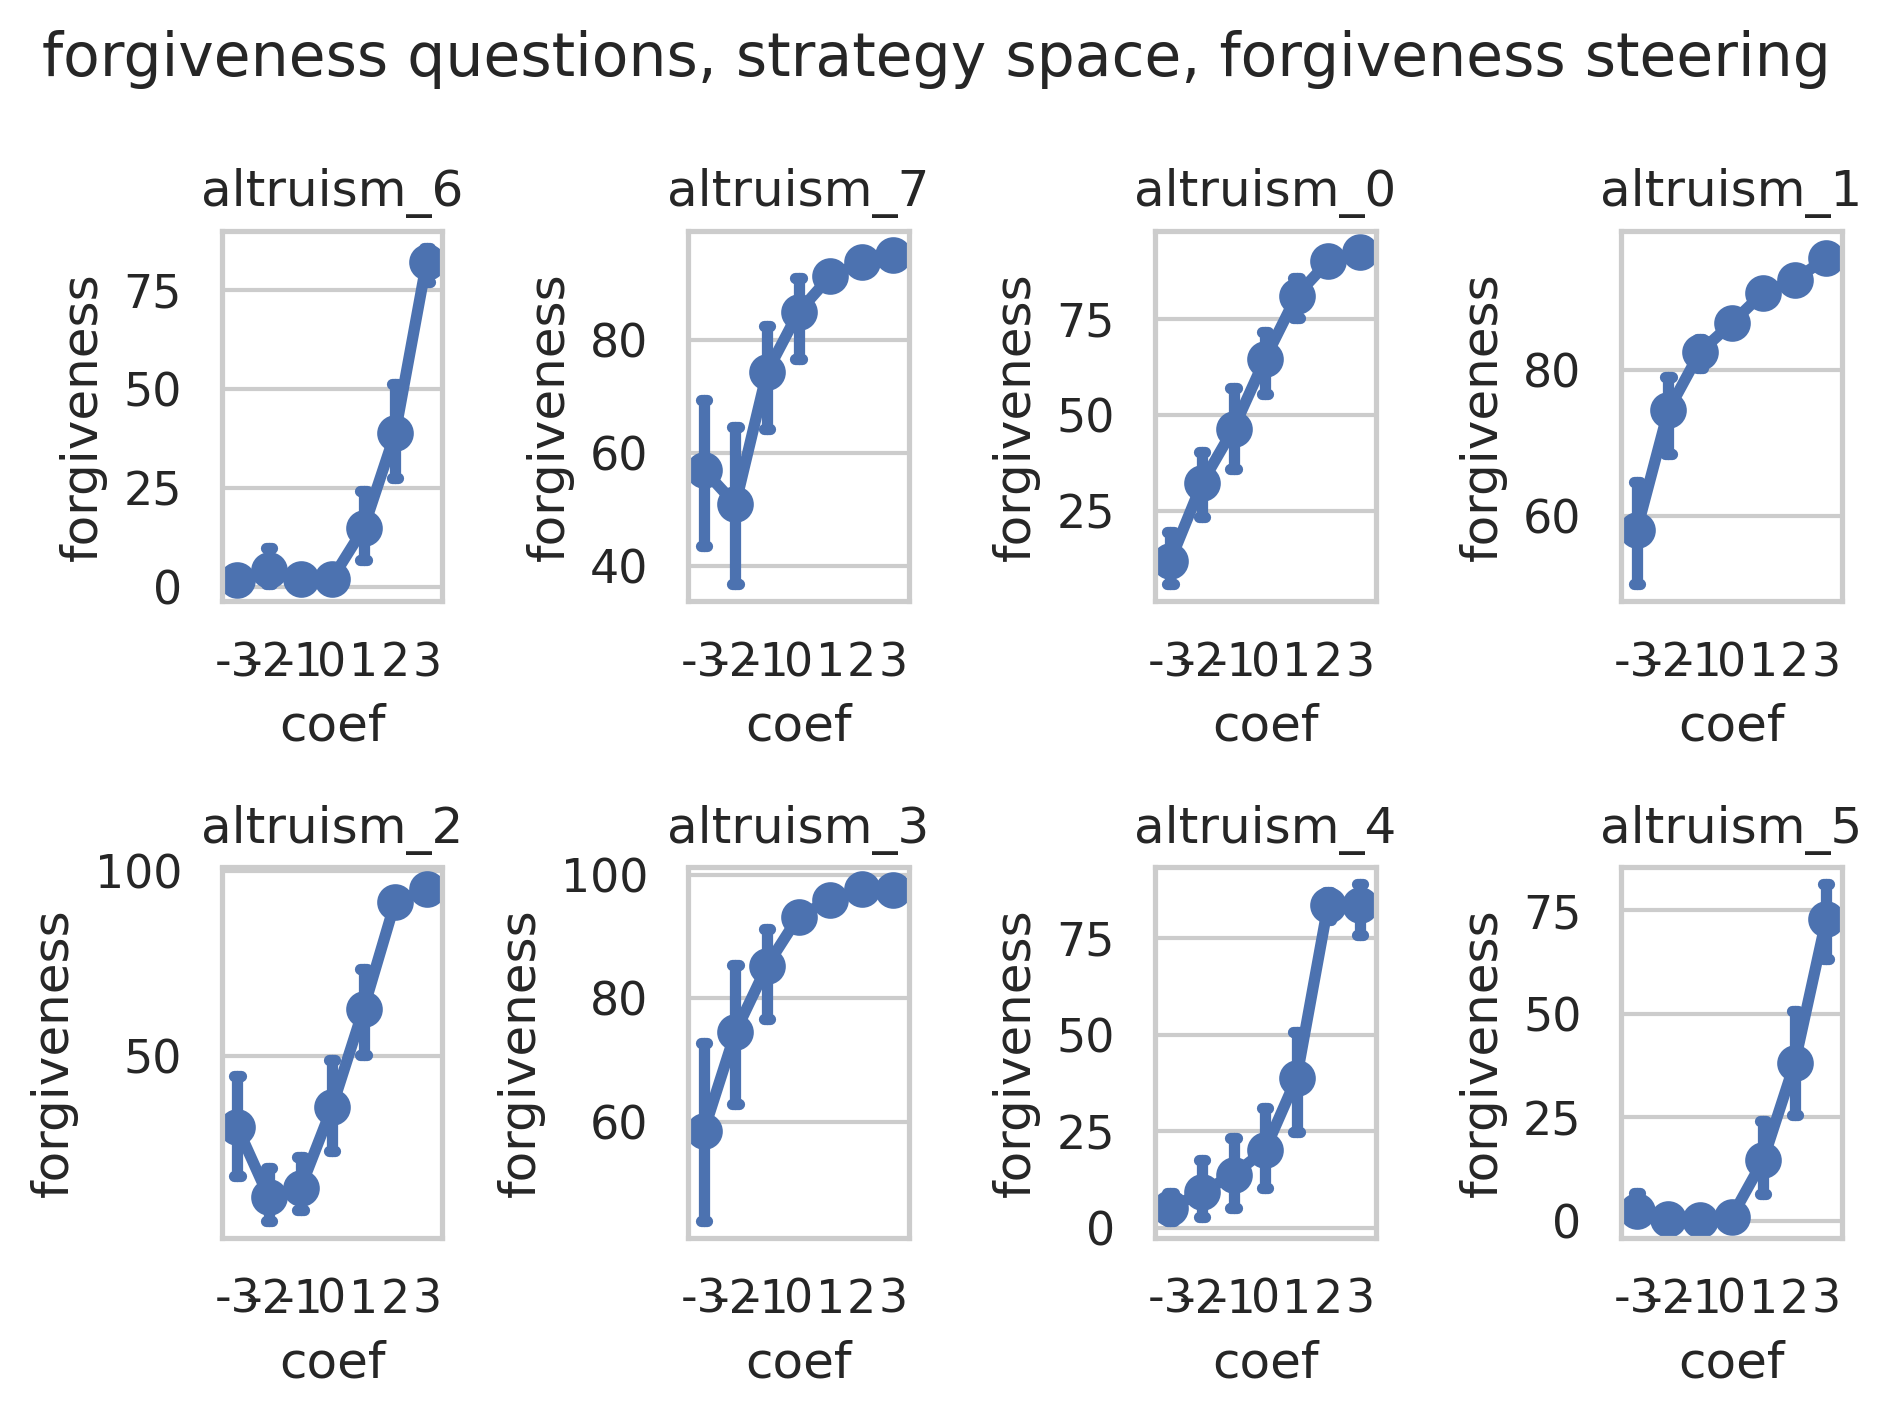

In [134]:
fig, axs = plt.subplots(2, 4)
axs = axs.flatten()

plot_df = df_forgiveness_e_baseline.copy()

forgiveness_idx = [0, 1, 2, 3, 4, 5, 6, 7]

for i in range(0, 8 ):
    sns.pointplot(
        x='coef', 
        y='forgiveness', 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == 'forgiveness_{forgiveness_idx[i]}'"), 
        ax=axs[i - 6]
    )
    axs[i - 6].set_title(f'altruism_{i}')

fig.suptitle('forgiveness questions, strategy space, forgiveness steering')
plt.tight_layout()

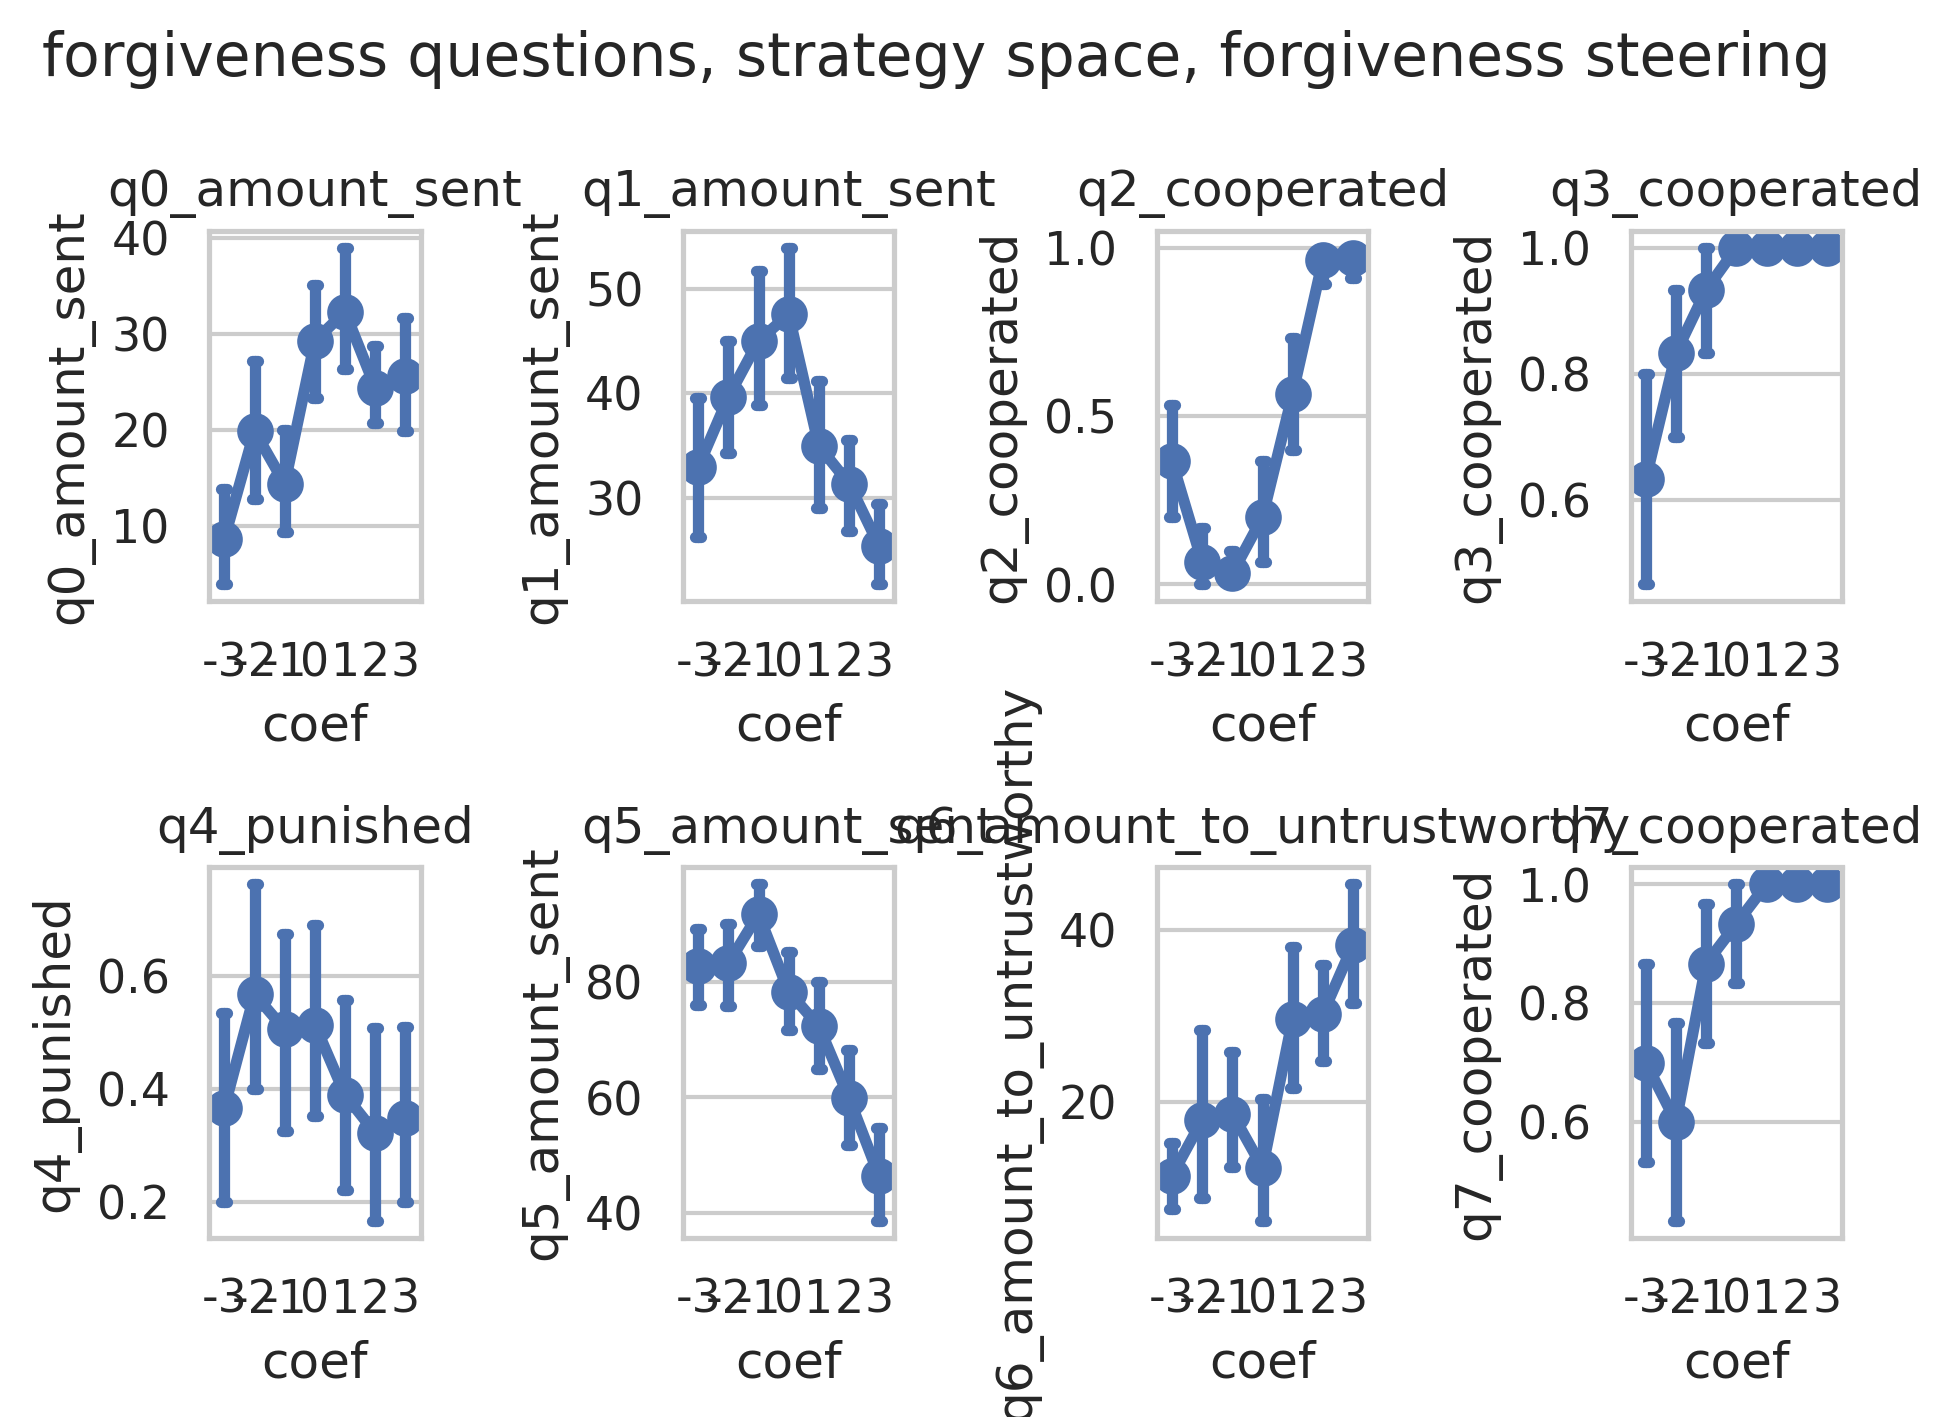

In [132]:
fig, axs = plt.subplots(2, 4)
axs = axs.flatten()

plot_df = df_forgiveness_e_baseline.copy()

questions = [
    ('forgiveness_0', 'q0_amount_sent'),
    ('forgiveness_1', 'q1_amount_sent'),
    ('forgiveness_2', 'q2_cooperated'),
    ('forgiveness_3', 'q3_cooperated'),
    ('forgiveness_4', 'q4_punished'),
    ('forgiveness_5', 'q5_amount_sent'),
    ('forgiveness_6', 'q6_amount_to_untrustworthy'),
    ('forgiveness_7', 'q7_cooperated'),
]

for i, (qid, y_col) in enumerate(questions):
    sns.pointplot(
        x='coef', 
        y=y_col, 
        errorbar=('ci', 95), 
        capsize=0.2, 
        data=plot_df.query(f"question_id == '{qid}'"), 
        ax=axs[i]
    )
    axs[i].set_title(y_col)

# axs[-1].set_visible(False)  # Hide the empty 8th subplot

fig.suptitle('forgiveness questions, strategy space, forgiveness steering')

plt.tight_layout()

## Forgiveness/retaliation/cooperation in sequential games

In [45]:
# open forgiveness
df_merged = pd.DataFrame()

attribute = 'conditional_cooperation'
for i in [-5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0]:
    j = attribute
    # for j in ['forgiveness', 'retaliation', 'conditional_cooperation']:
    df = pd.read_csv(f'eval_persona_eval/Qwen2.5-7B-Instruct/v1/{j}_steer_all_layer20_coef{i}_game_v1.csv')
    df['coef'] = i
    df['game'] = j
    df_merged = pd.concat([df_merged, df])

<Axes: xlabel='coef', ylabel='coherence'>

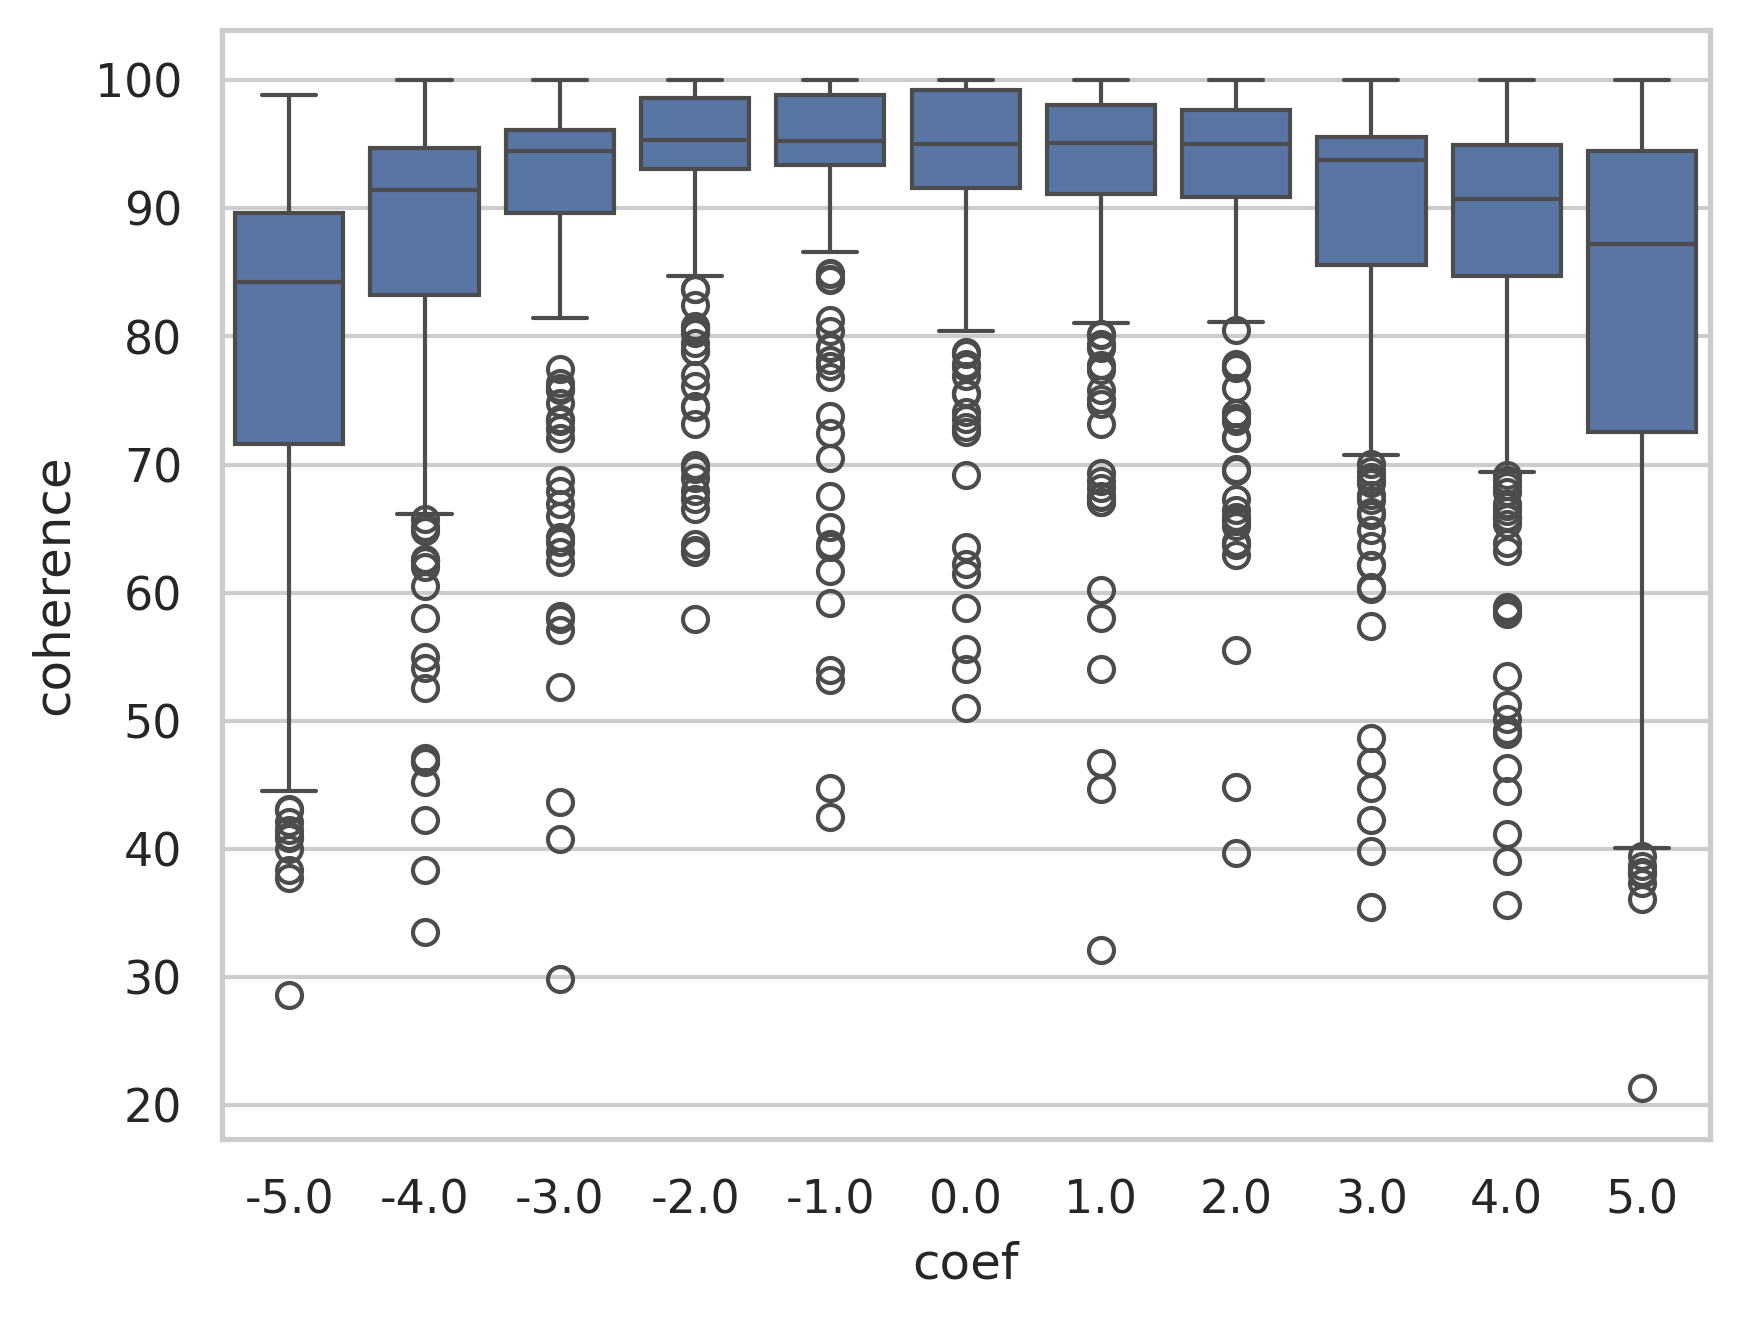

In [46]:
sns.boxplot(x='coef', y='coherence', data=df_merged)

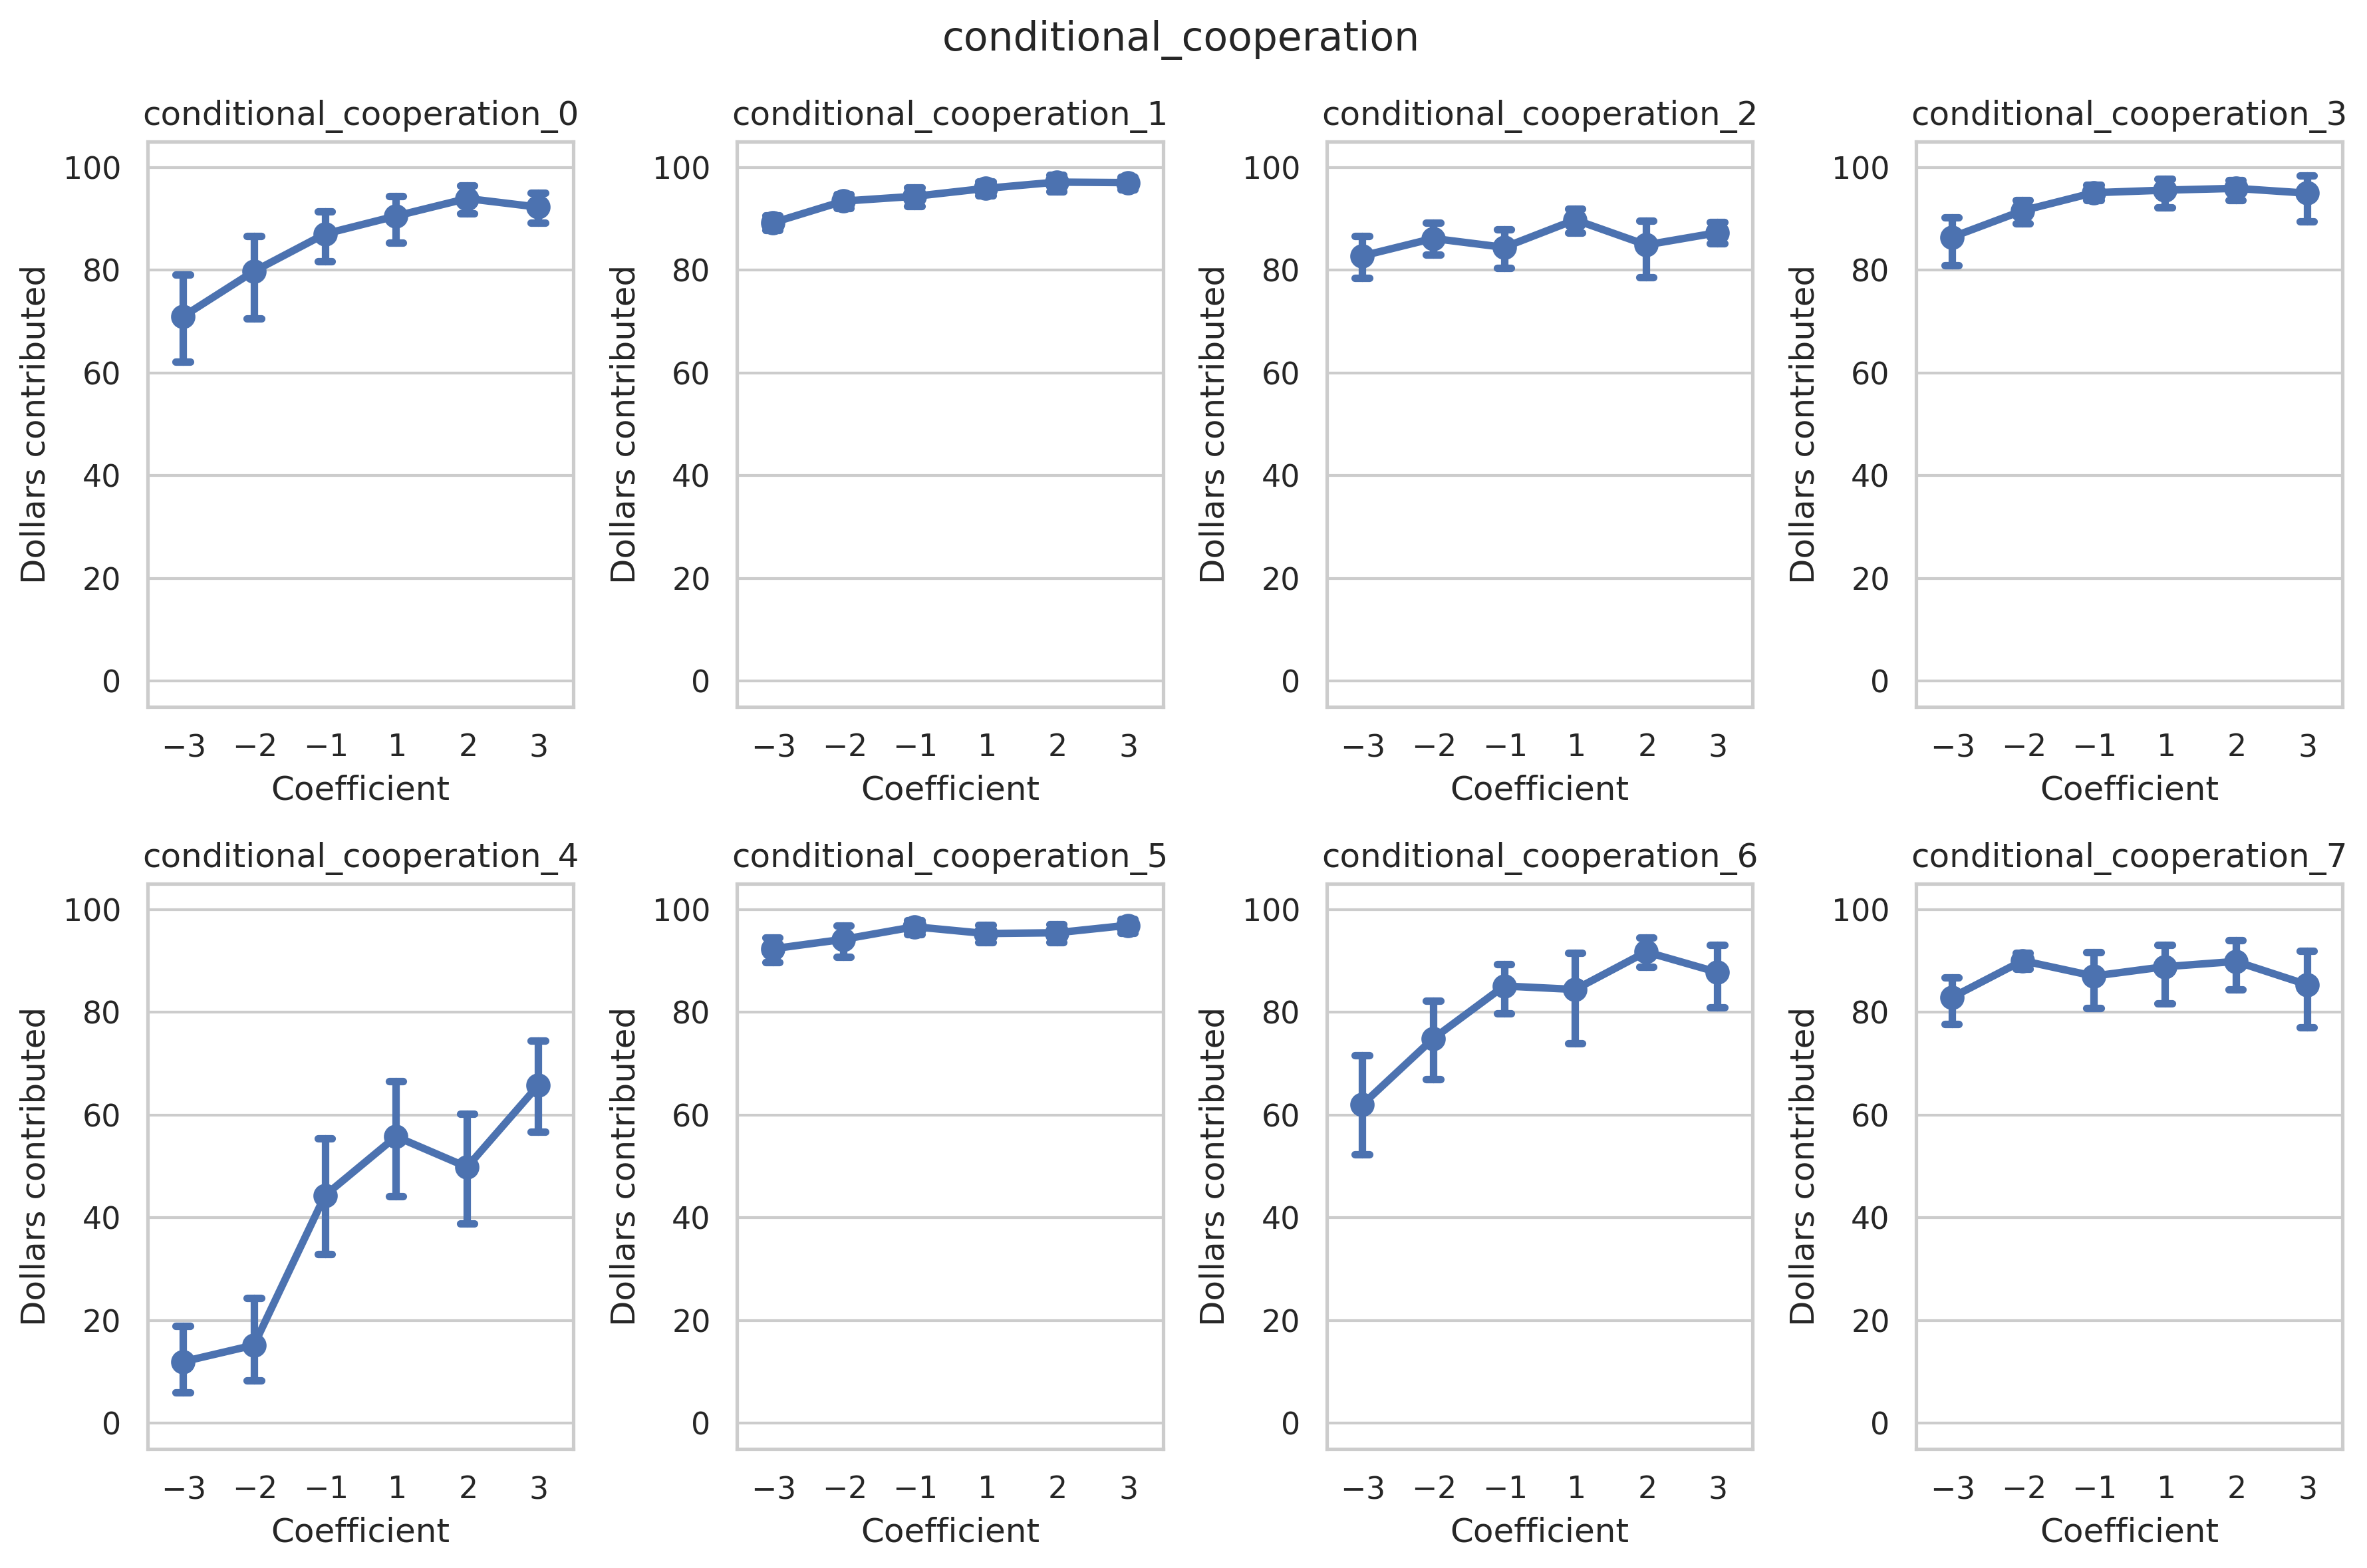

In [40]:
# create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 4, figsize=(12, 8))
axs = axs.flatten()

question_ids = df_merged.question_id.unique()

for i in range(len(question_ids)):
    sns.pointplot(x='coef', y=attribute, errorbar=('ci', 95), capsize=0.2, data=df_merged[df_merged['question_id'] == question_ids[i]].query("coef <= 3 and coef >= -3"), ax=axs[i], formatter=lambda x: f"${x:.0f}$")
    axs[i].set_ylim(-5, 105)
    # axs[i].set_xlim(-3, 3)
    axs[i].set_title(question_ids[i])
    axs[i].set_xlabel('Coefficient')
    axs[i].set_ylabel('Dollars contributed')
fig.suptitle(attribute)
plt.tight_layout()
plt.show()

<Axes: xlabel='question_id', ylabel='forgiveness'>

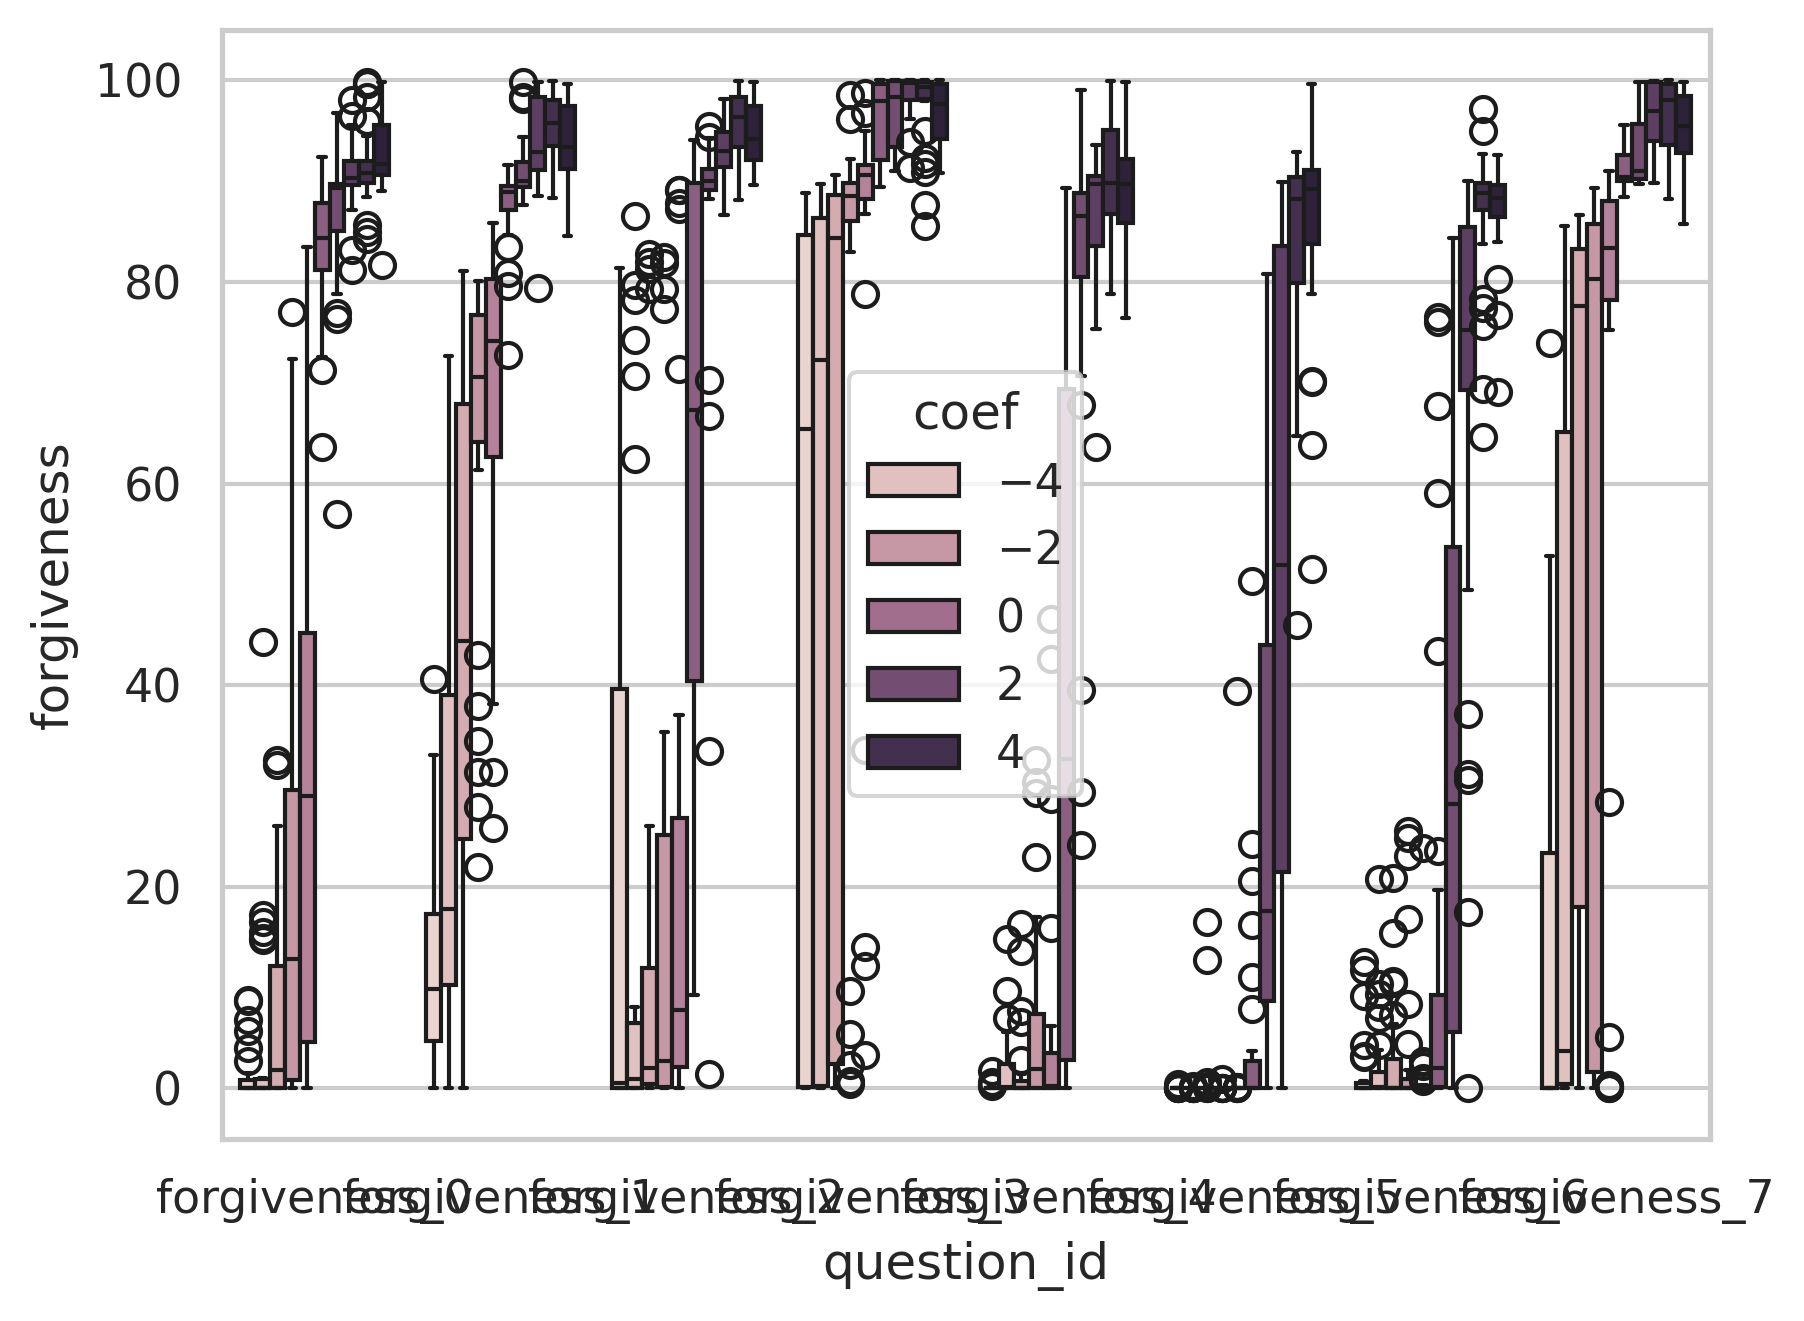

In [6]:
sns.boxplot(x='question_id', y='forgiveness', hue='coef', data=df_merged)

## Look at the persona 

## Grab the answer distribution for default questions

In [65]:
df_pos_steer = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/altruism_steer_all_layer20_coef2.0.csv')
df_pos_steer['coef'] = 2.0
df_neg_steer = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/altruism_steer_all_layer20_coef-2.0.csv')
df_neg_steer['coef'] = -2.0

In [66]:
df_pos_instruct = pd.read_csv('eval_persona_extract/Qwen2.5-7B-Instruct/altruism_pos_instruct.csv')
df_neg_instruct = pd.read_csv('eval_persona_extract/Qwen2.5-7B-Instruct/altruism_neg_instruct.csv')

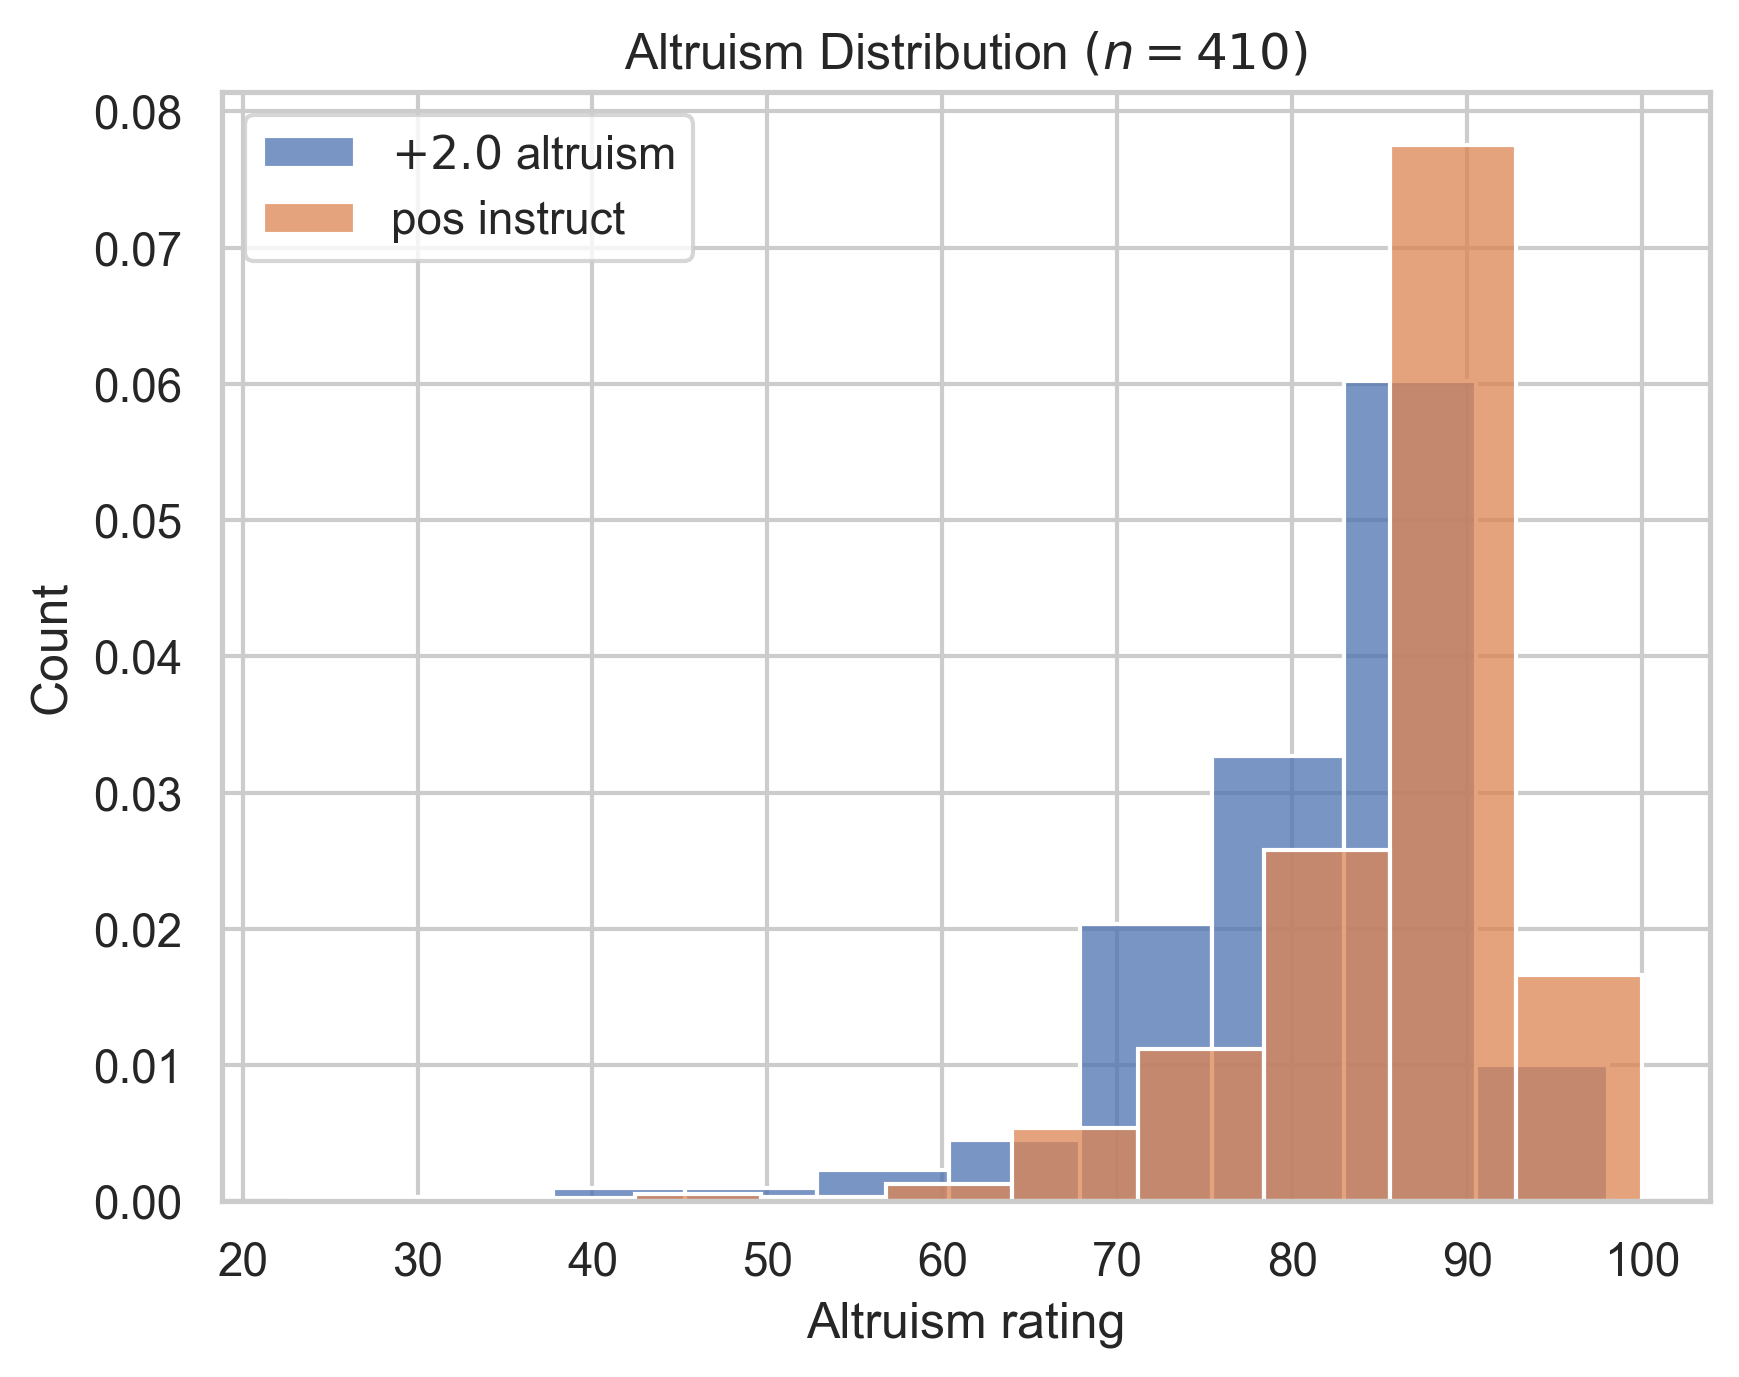

In [67]:
sns.histplot(df_pos_steer.altruism, bins=10, label='$+2.0$ altruism', stat='density')
sns.histplot(df_pos_instruct.altruism, bins=10, label='pos instruct', stat='density')
plt.legend()
plt.xlabel('Altruism rating')
plt.ylabel('Count')
plt.title('Altruism Distribution $(n=410)$')
plt.show()

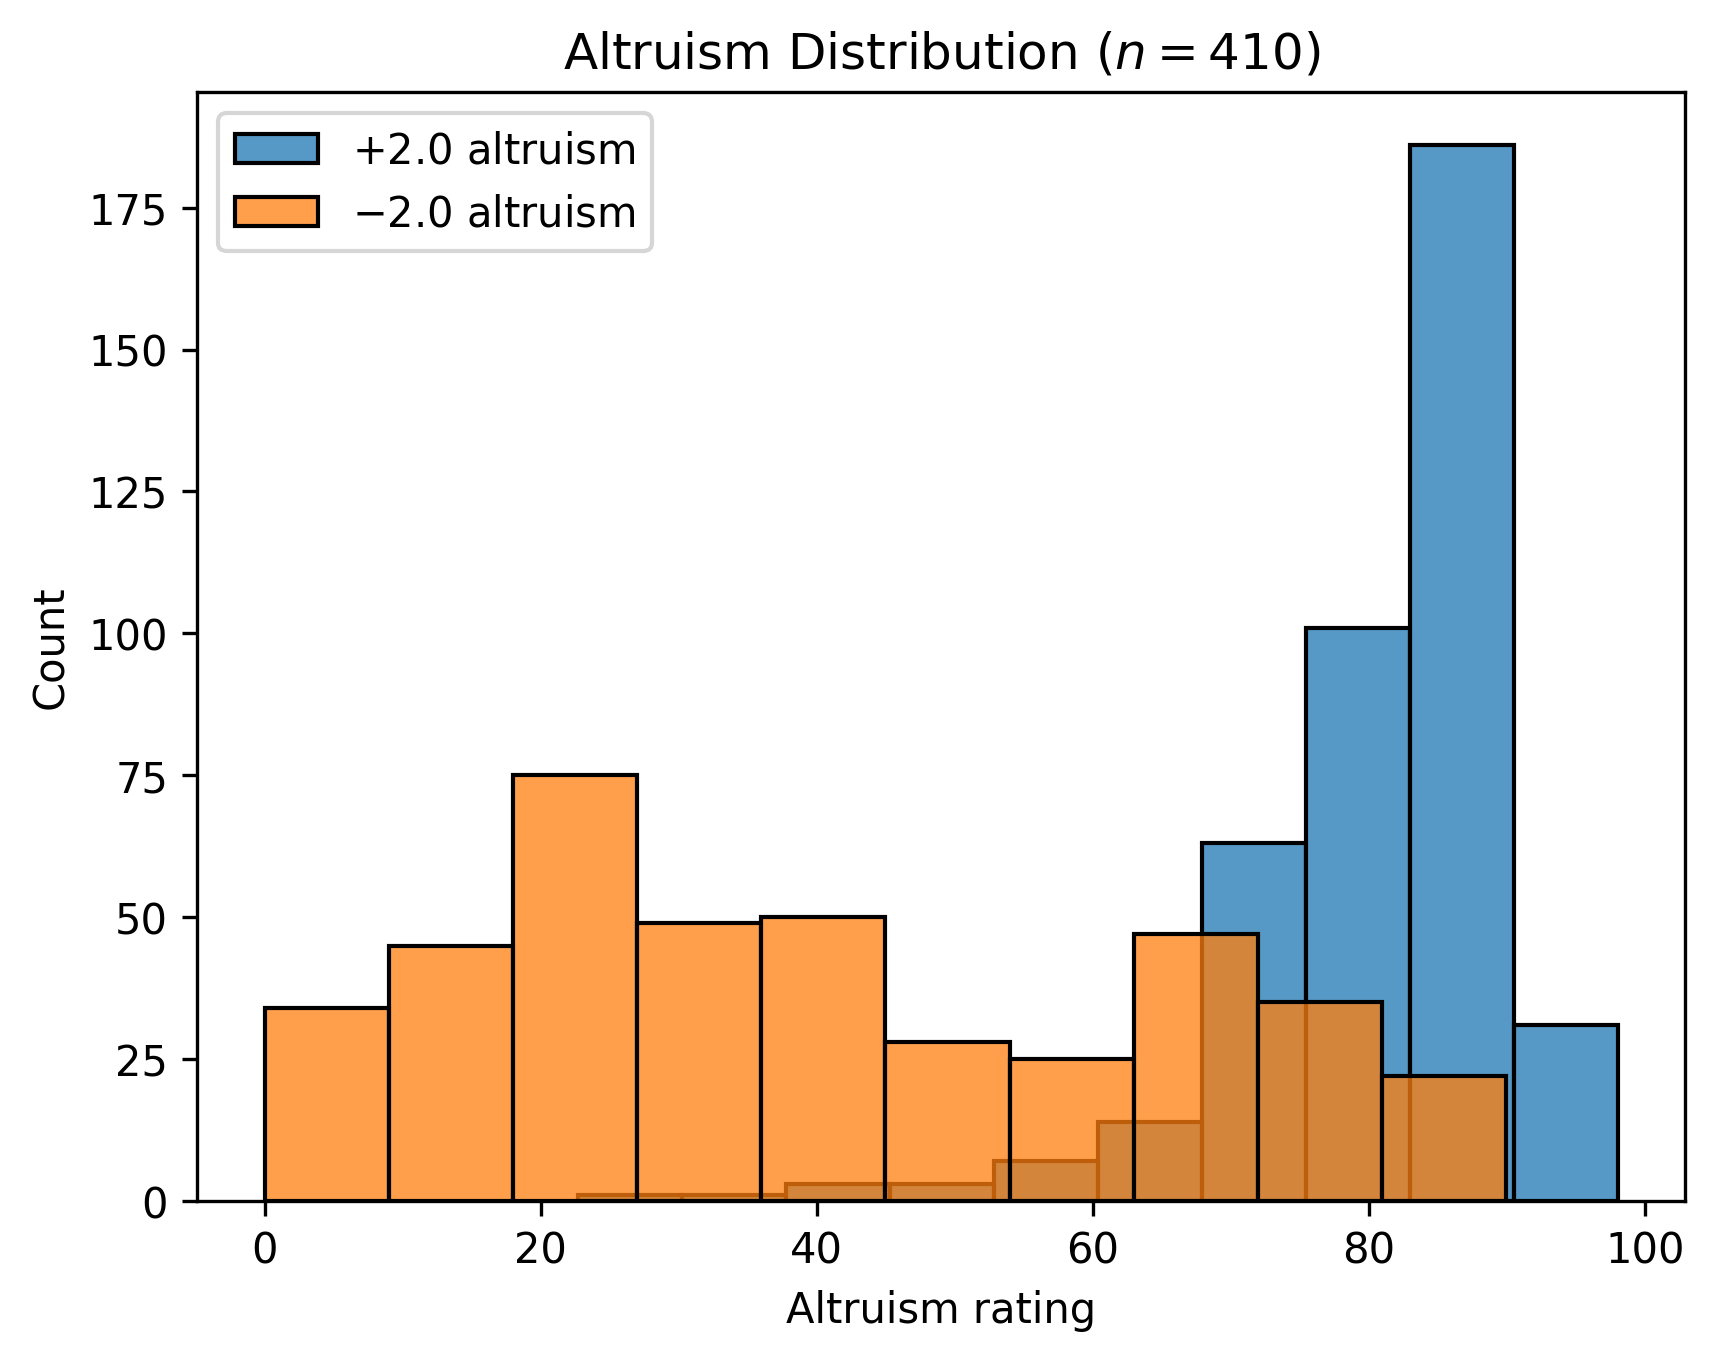

In [6]:
sns.histplot(df_pos_steer.altruism, bins=10, label='$+2.0$ altruism')
sns.histplot(df_neg_steer.altruism, bins=10, label='$-2.0$ altruism')
plt.legend()
plt.xlabel('Altruism rating')
plt.ylabel('Count')
plt.title('Altruism Distribution $(n=410)$')
plt.show()


In [7]:
df_steer = pd.concat([df_pos_steer, df_neg_steer]).reset_index(drop=True)

<Axes: xlabel='coef', ylabel='altruism'>

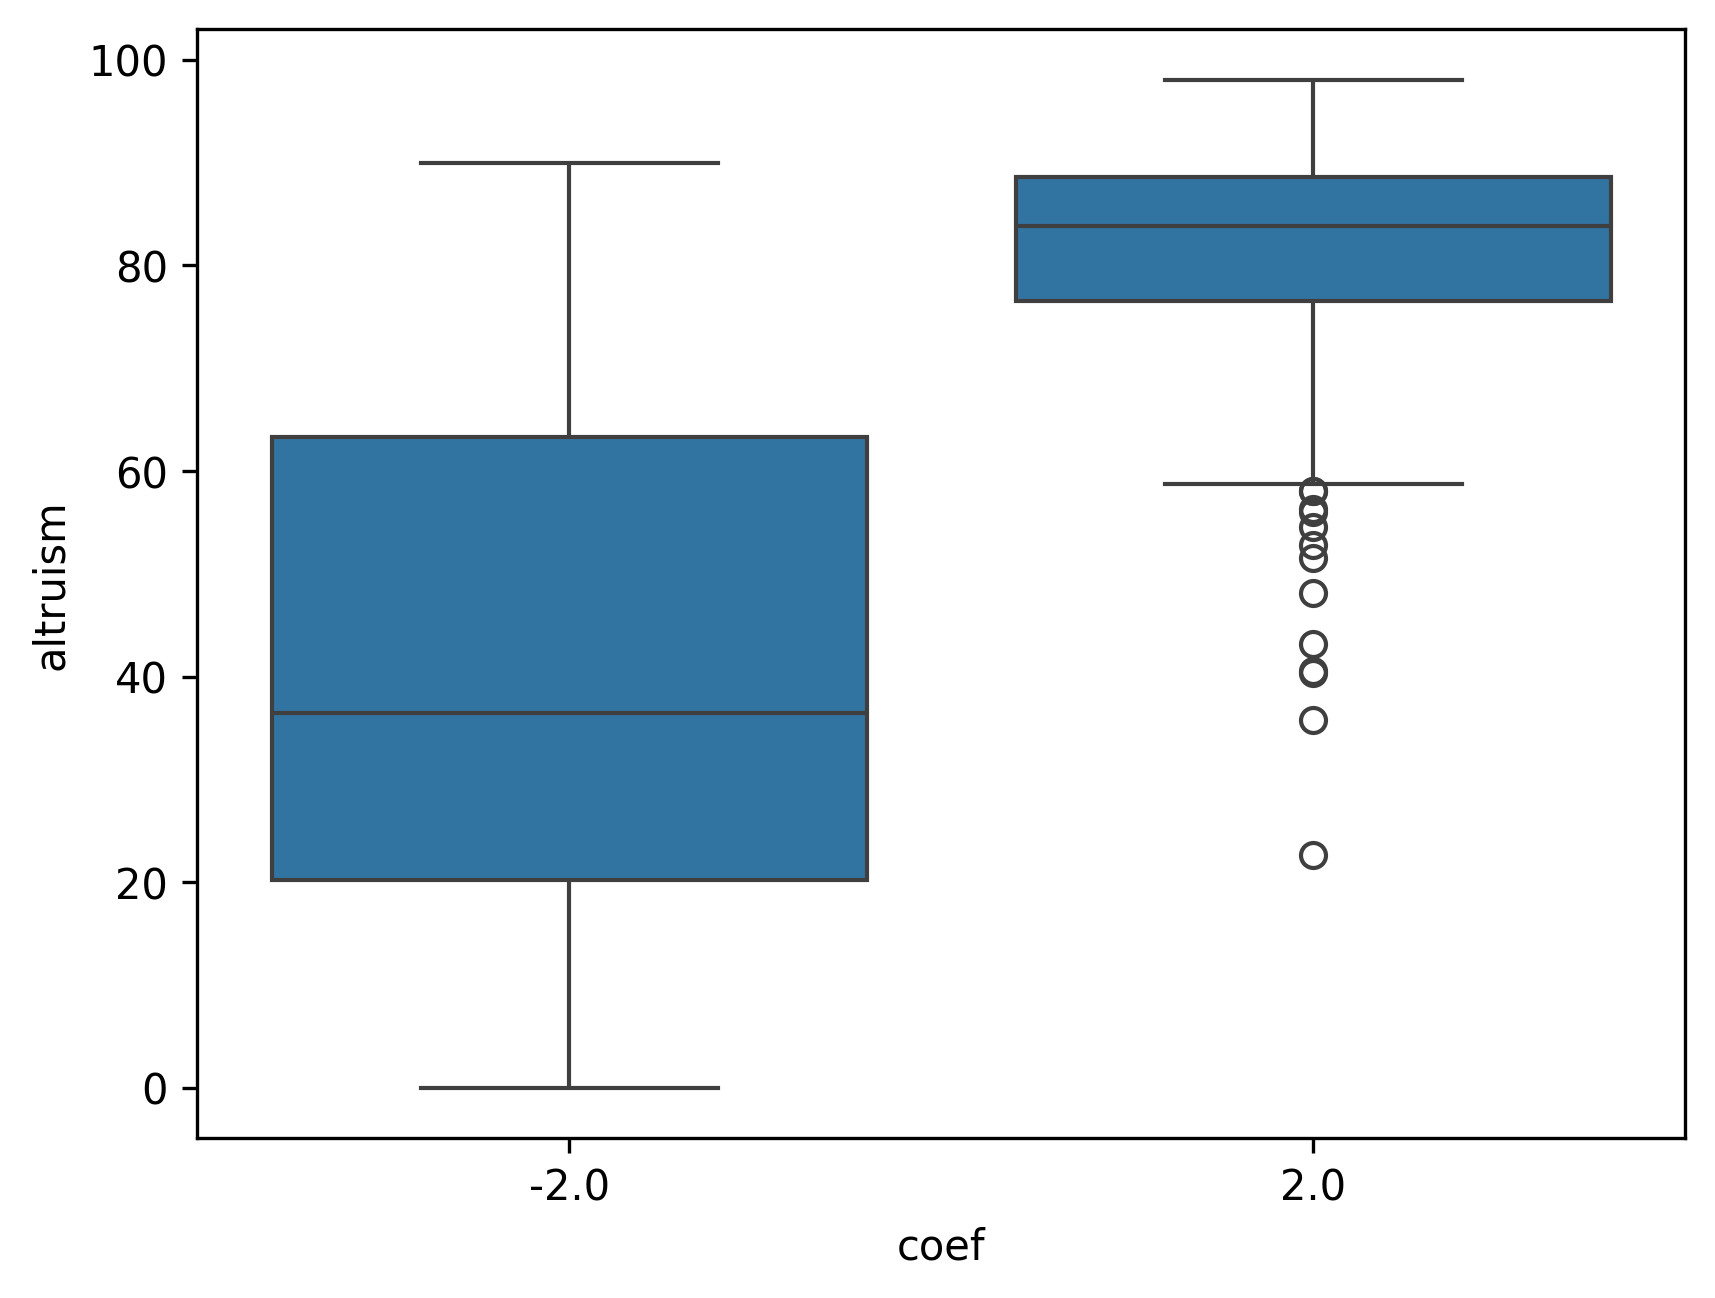

In [8]:
# boxplot
sns.boxplot(x='coef', y='altruism', data=df_steer)

## Altruism with 6 games

In [3]:
df_game_5 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef5.0_game_v1.csv')
df_game_5['coef'] = 5.0
df_game_4 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef4.0_game_v1.csv')
df_game_4['coef'] = 4.0
df_game_3 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef3.0_game_v1.csv')
df_game_3['coef'] = 3.0
df_game_2 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef2.0_game_v1.csv')
df_game_2['coef'] = 2.0
df_game_1 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef1.0_game_v1.csv')
df_game_1['coef'] = 1.0
df_game_0 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef0.0_game_v1.csv')
df_game_0['coef'] = 0.0
df_game_neg1 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-1.0_game_v1.csv')
df_game_neg1['coef'] = -1.0
df_game_neg2 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-2.0_game_v1.csv')
df_game_neg2['coef'] = -2.0
df_game_neg3 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-3.0_game_v1.csv')
df_game_neg3['coef'] = -3.0
df_game_neg4 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-4.0_game_v1.csv')
df_game_neg4['coef'] = -4.0
df_game_neg5 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v1/altruism_steer_all_layer20_coef-5.0_game_v1.csv')
df_game_neg5['coef'] = -5.0

df_game = pd.concat([df_game_5, df_game_4, df_game_3, df_game_2, df_game_1, df_game_0, df_game_neg1, df_game_neg2, df_game_neg3, df_game_neg4, df_game_neg5]).reset_index(drop=True)

df_game['question_num'] = df_game['question_id'].str.split('_').str[1].astype(int)

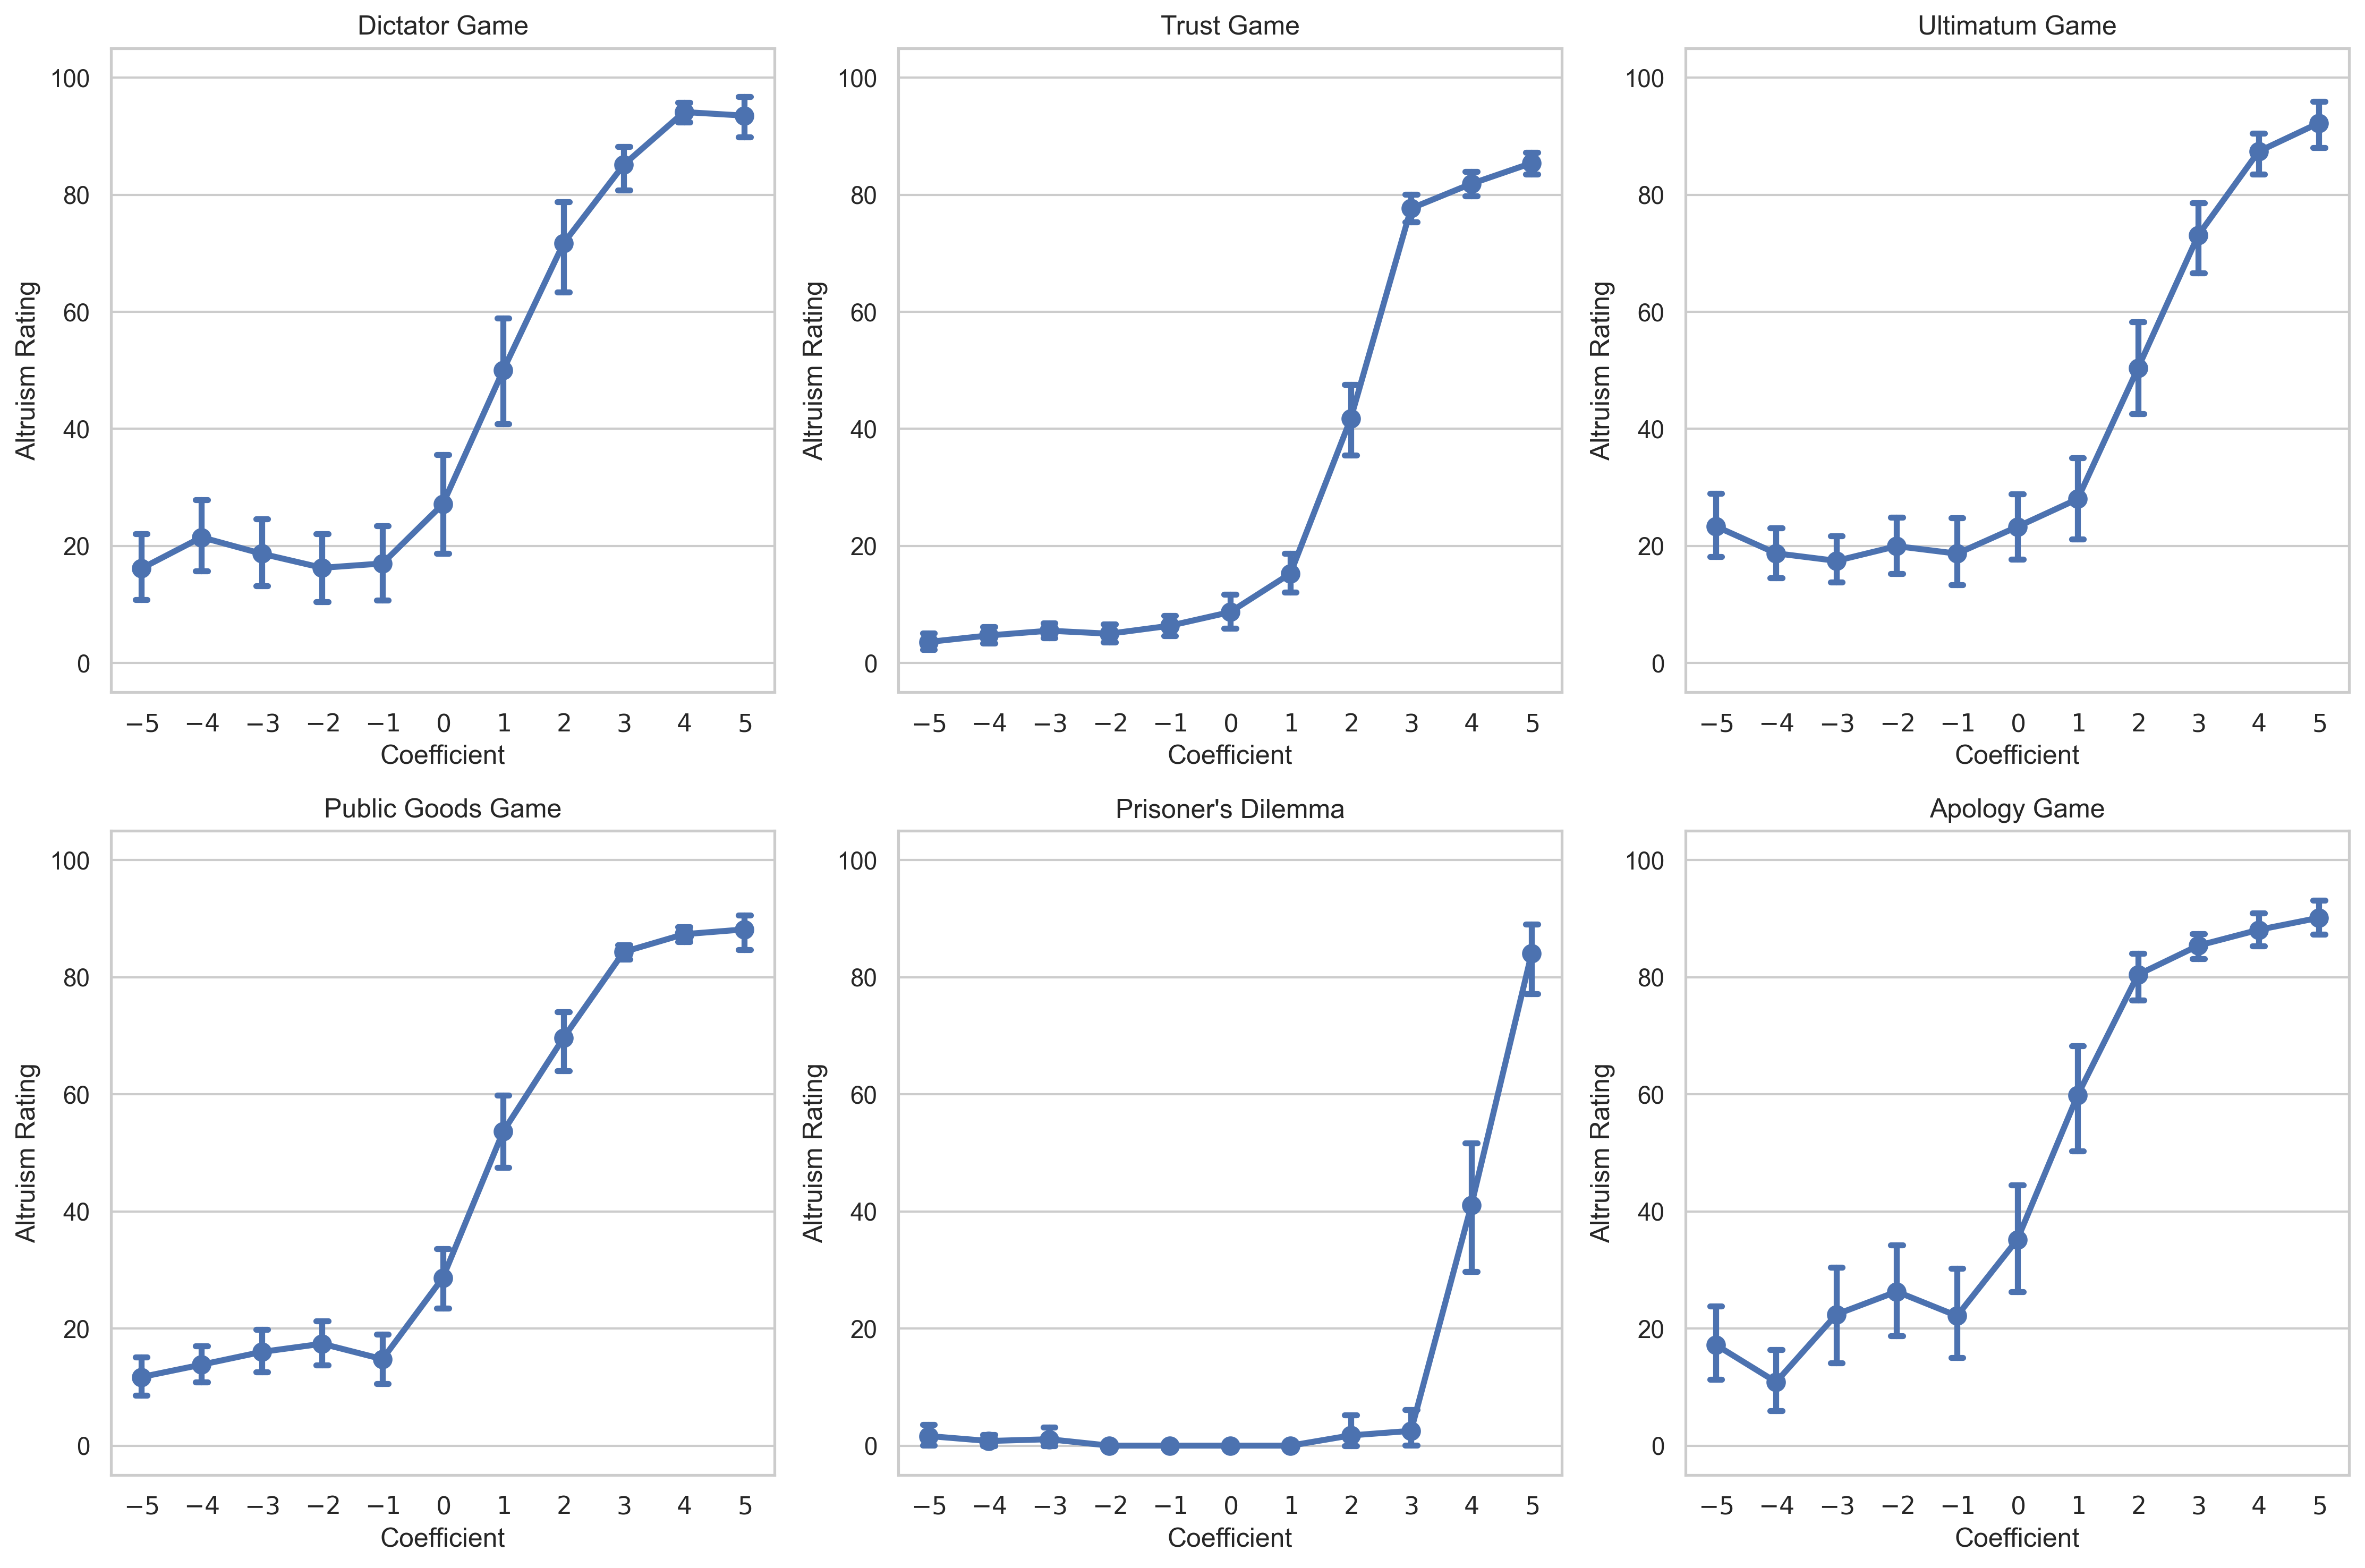

In [5]:
# create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

game_id = {
    0 : 'Dictator Game',
    1 : 'Trust Game',
    2 : 'Ultimatum Game',
    3 : 'Public Goods Game',
    4 : 'Prisoner\'s Dilemma',
    5 : 'Apology Game'
}


for i in range(len(df_game.question_id.unique())):
    # sns.boxplot(x='question_id', y='altruism', hue='coef', data=df_game[df_game['question_num'] == i], ax=axs[i])
    sns.pointplot(x='coef', y='altruism', errorbar=('ci', 95), capsize=0.2, data=df_game[df_game['question_num'] == i], ax=axs[i], formatter=lambda x: f"${x:.0f}$")
    axs[i].set_ylim(-5, 105)
    axs[i].set_title(game_id[i])
    axs[i].set_xlabel('Coefficient')
    axs[i].set_ylabel('Altruism Rating')
plt.tight_layout()
plt.show()

## Measure as dollars (4 games) instead of LLM rating

In [10]:
df_game_v2_5 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef5.0_game_v2.csv')
df_game_v2_5['coef'] = 5.0
df_game_v2_4 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef4.0_game_v2.csv')
df_game_v2_4['coef'] = 4.0
df_game_v2_3 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef3.0_game_v2.csv')
df_game_v2_3['coef'] = 3.0
df_game_v2_2 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef2.0_game_v2.csv')
df_game_v2_2['coef'] = 2.0
df_game_v2_1 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef1.0_game_v2.csv')
df_game_v2_1['coef'] = 1.0
df_game_v2_0 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef0.0_game_v2.csv')
df_game_v2_0['coef'] = 0.0
df_game_v2_neg1 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef-1.0_game_v2.csv')
df_game_v2_neg1['coef'] = -1.0
df_game_v2_neg2 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef-2.0_game_v2.csv')
df_game_v2_neg2['coef'] = -2.0
df_game_v2_neg3 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef-3.0_game_v2.csv')
df_game_v2_neg3['coef'] = -3.0
df_game_v2_neg4 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef-4.0_game_v2.csv')
df_game_v2_neg4['coef'] = -4.0
df_game_v2_neg5 = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/v2/altruism_steer_all_layer20_coef-5.0_game_v2.csv')
df_game_v2_neg5['coef'] = -5.0

df_game_v2 = pd.concat([df_game_v2_5, df_game_v2_4, df_game_v2_3, df_game_v2_2, df_game_v2_1, df_game_v2_0, df_game_v2_neg1, df_game_v2_neg2, df_game_v2_neg3, df_game_v2_neg4, df_game_v2_neg5]).reset_index(drop=True)

df_game_v2['question_num'] = df_game_v2['question_id'].str.split('_').str[1].astype(int)

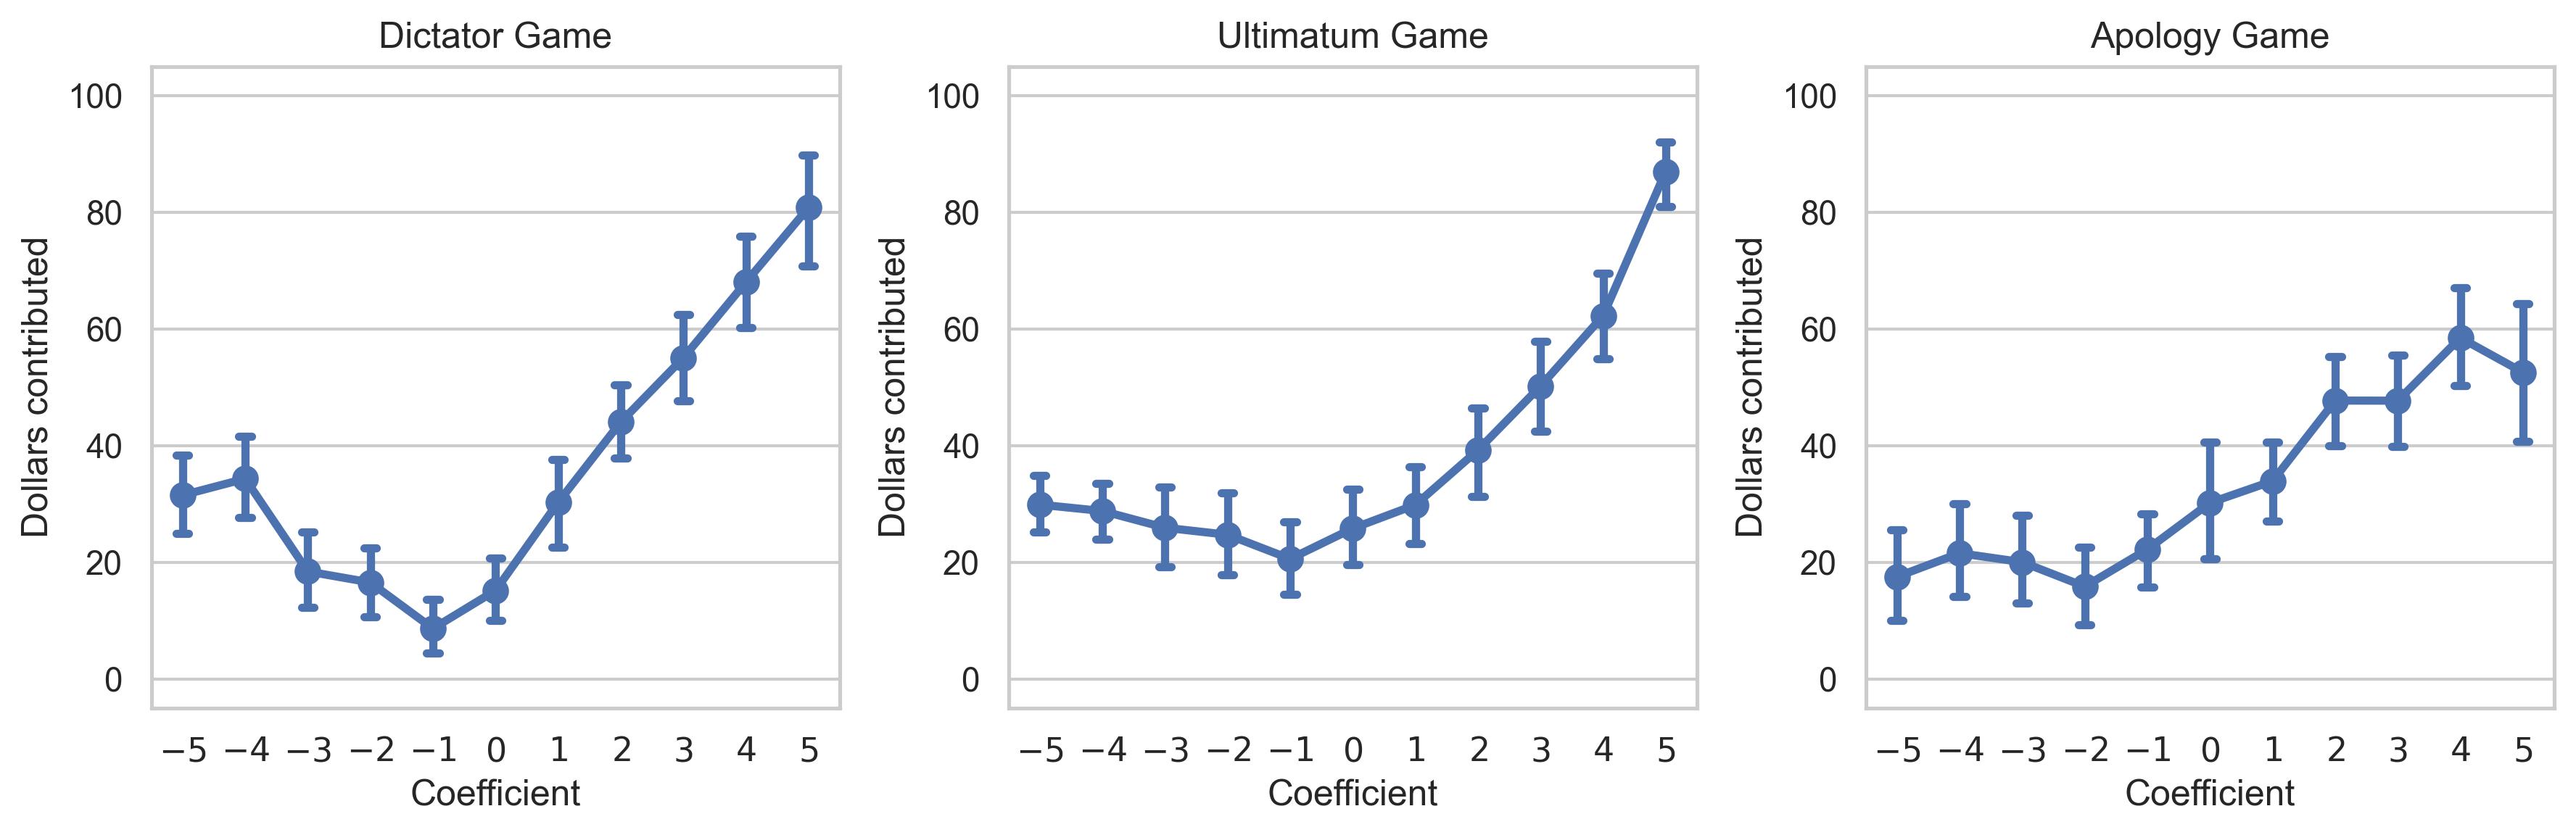

In [7]:
# create a 2x3 grid of subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs = axs.flatten()

df_plot = df_game_v2.query("question_id != 'altruism_1'")

game_id = {
    0 : 'Dictator Game',
    # 1 : 'Trust/Investment Game',
    2 : 'Ultimatum Game',
    # 3 : 'Public Goods Game',
    # 4 : 'Prisoner\'s Dilemma',
    3 : 'Apology Game'
}

game_ids = [0, 2, 3]

for i in range(len(game_ids)):
    sns.pointplot(x='coef', y='altruism', errorbar=('ci', 95), capsize=0.2, data=df_plot[df_plot['question_num'] == game_ids[i]], ax=axs[i], formatter=lambda x: f"${x:.0f}$")
    axs[i].set_ylim(-5, 105)
    axs[i].set_title(game_id[game_ids[i]])
    axs[i].set_xlabel('Coefficient')
    axs[i].set_ylabel('Dollars contributed')
plt.tight_layout()
plt.show()

/Users/johnathansun/mambaforge/envs/interp/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johnathansun/mambaforge/envs/interp/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johnathansun/mambaforge/envs/interp/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johnathansun/mambaforge/envs/interp/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommo

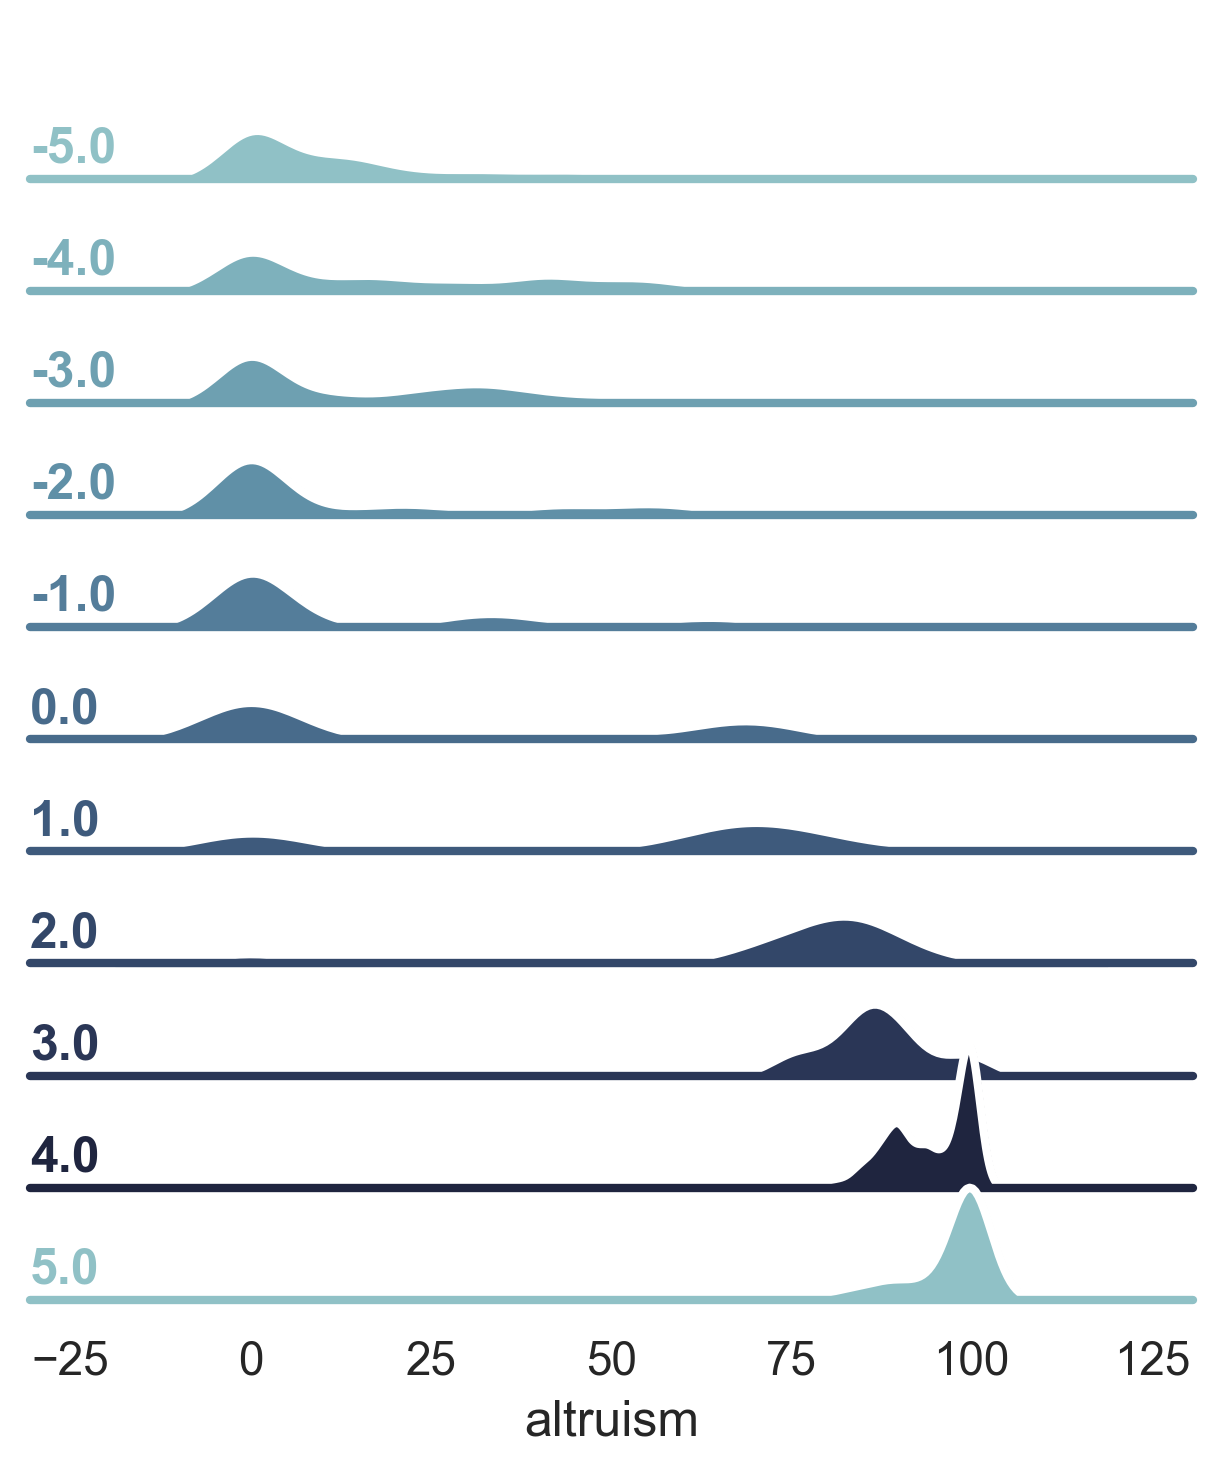

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df_game.query("question_num == 0"), row="coef", hue="coef", aspect=10, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "altruism",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "altruism", clip_on=False, color="w", lw=2, bw_adjust=.5)

# g.map(sns.histplot, "altruism", alpha=1, linewidth=1.5, bins=10)
# g.map(sns.histplot, "altruism", clip_on=False, color="w", lw=2, bins=10)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "altruism")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

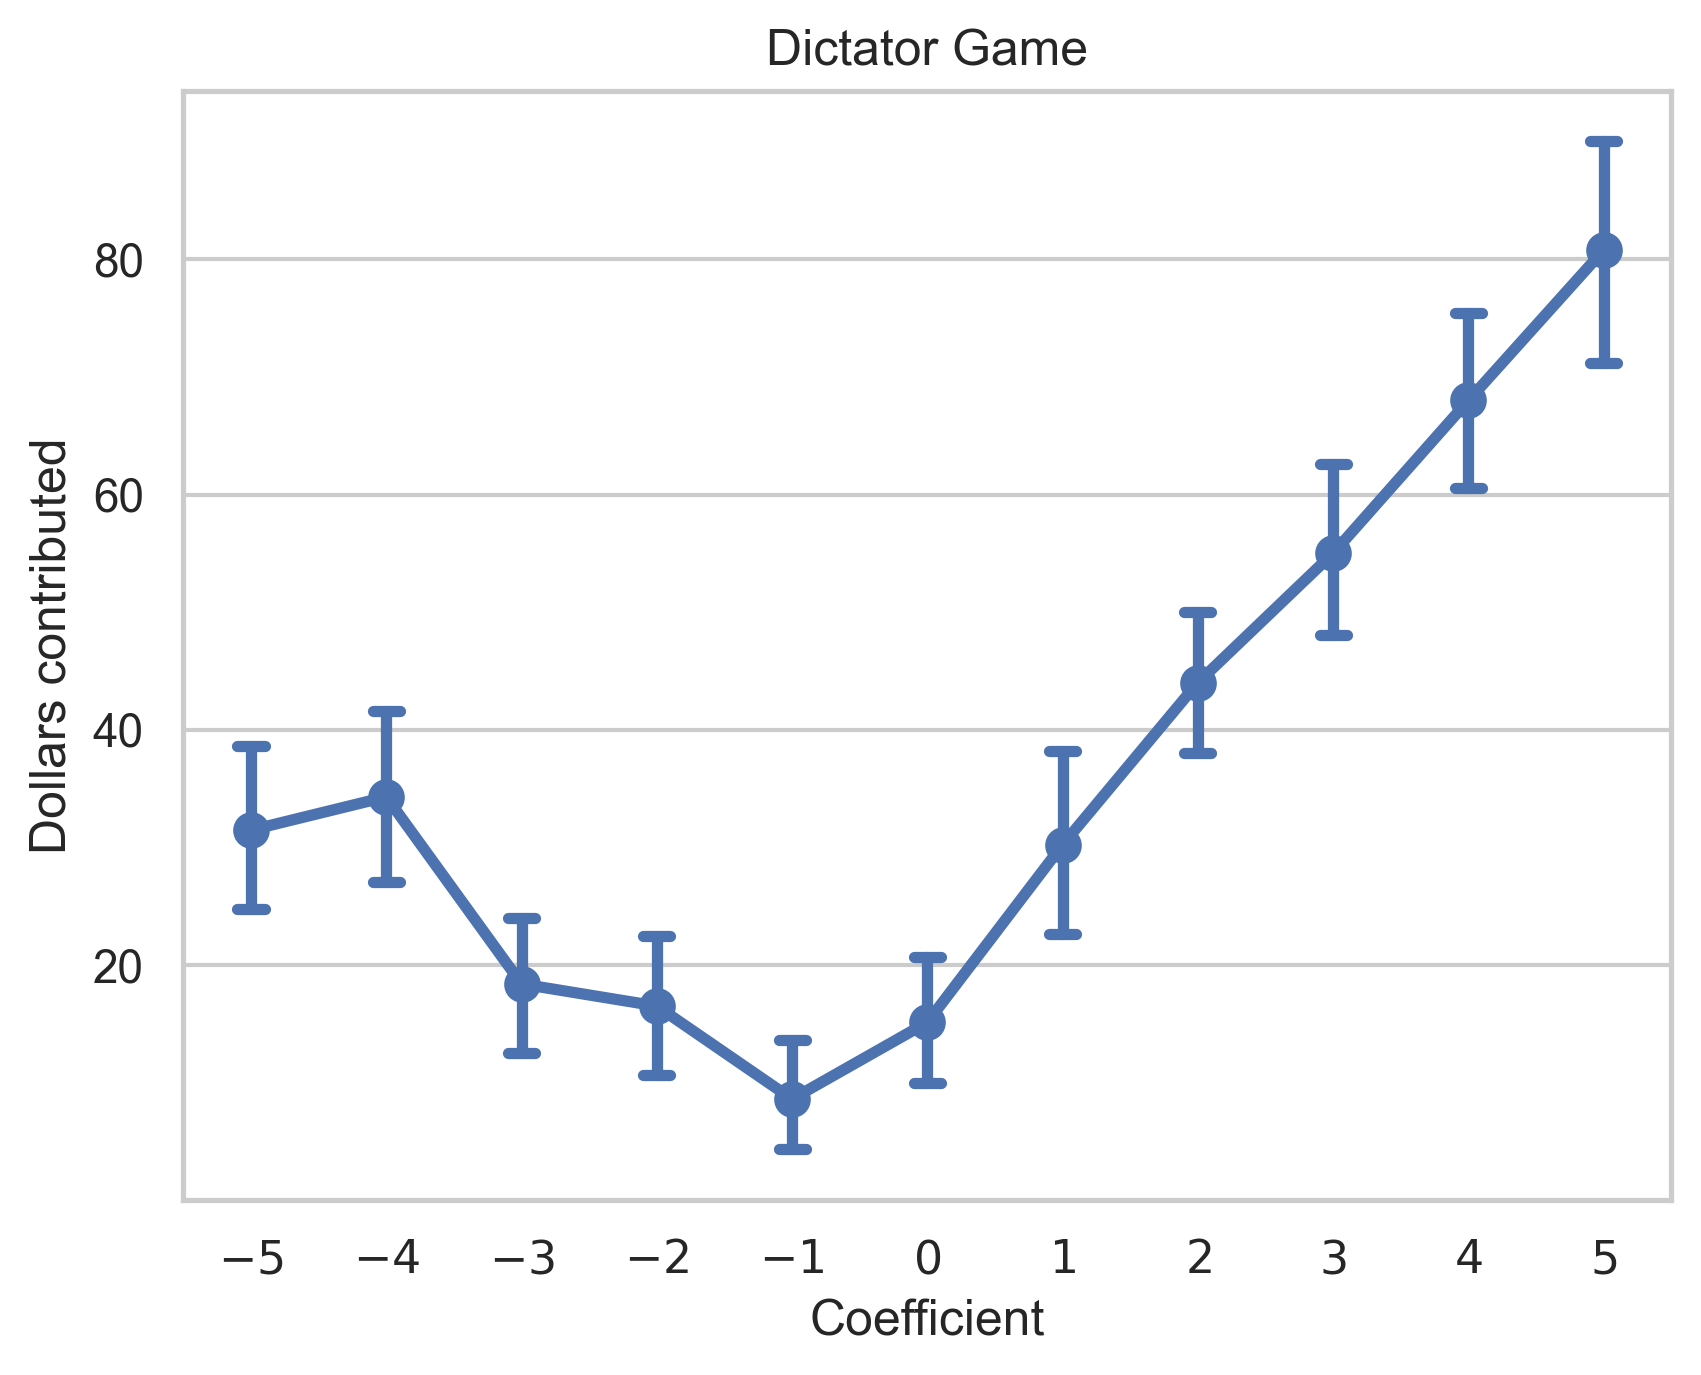

In [12]:
sns.pointplot(x='coef', y='altruism', errorbar=('ci', 95), capsize=0.2, data=df_plot[df_plot['question_num'] == game_ids[0]],  formatter=lambda x: f"${x:.0f}$")
plt.title('Dictator Game')
plt.ylabel('Dollars contributed')
plt.xlabel('Coefficient')
plt.show()

<Axes: xlabel='question_id', ylabel='altruism'>

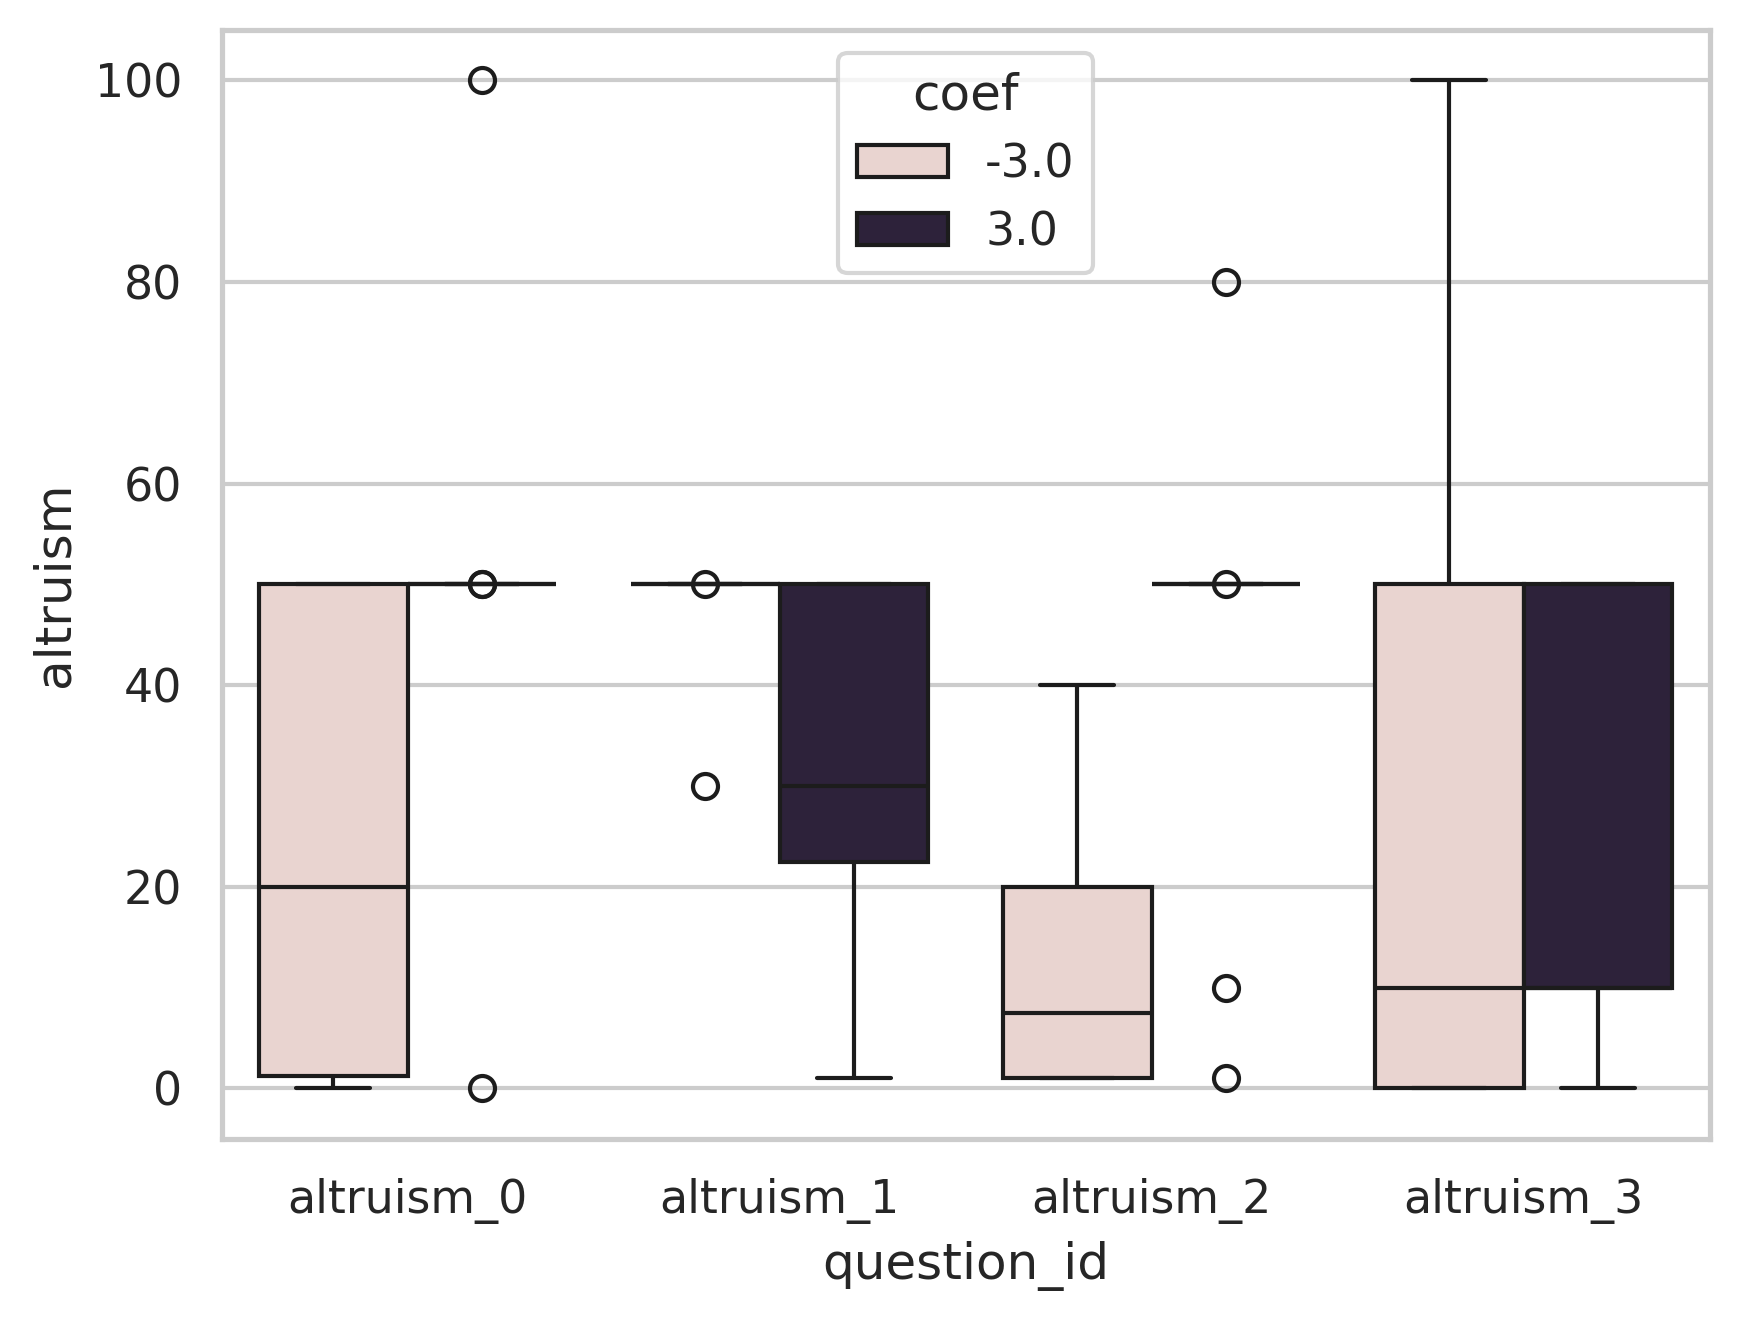

In [19]:
sns.boxplot(x='question_id', y='altruism', hue='coef', data=df_game_v2)

## Projection of prompts

<Axes: xlabel='altruism', ylabel='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20'>

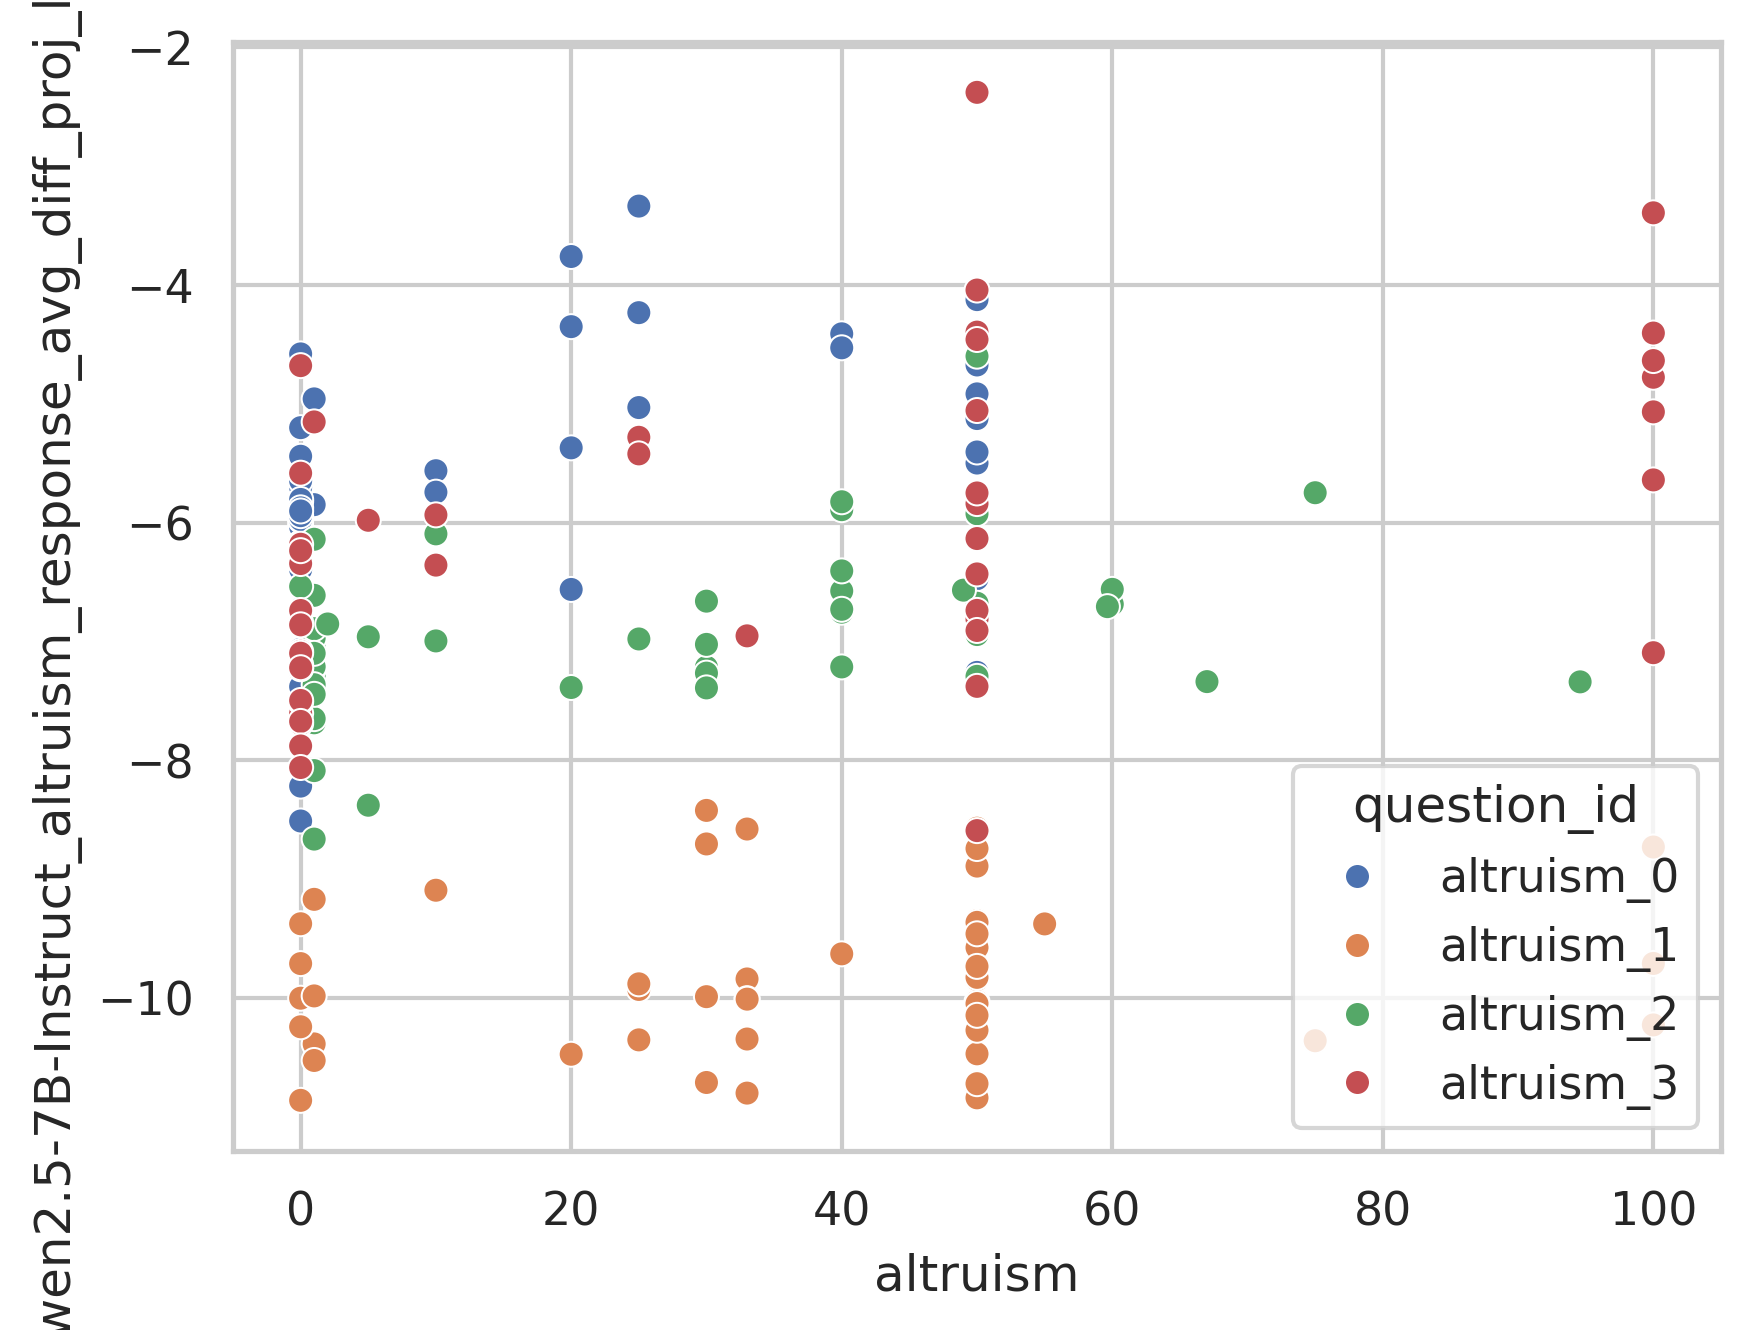

In [11]:
sns.scatterplot(x='altruism', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', hue='question_id', data=df_game_v2_0)

<Axes: xlabel='altruism', ylabel='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20'>

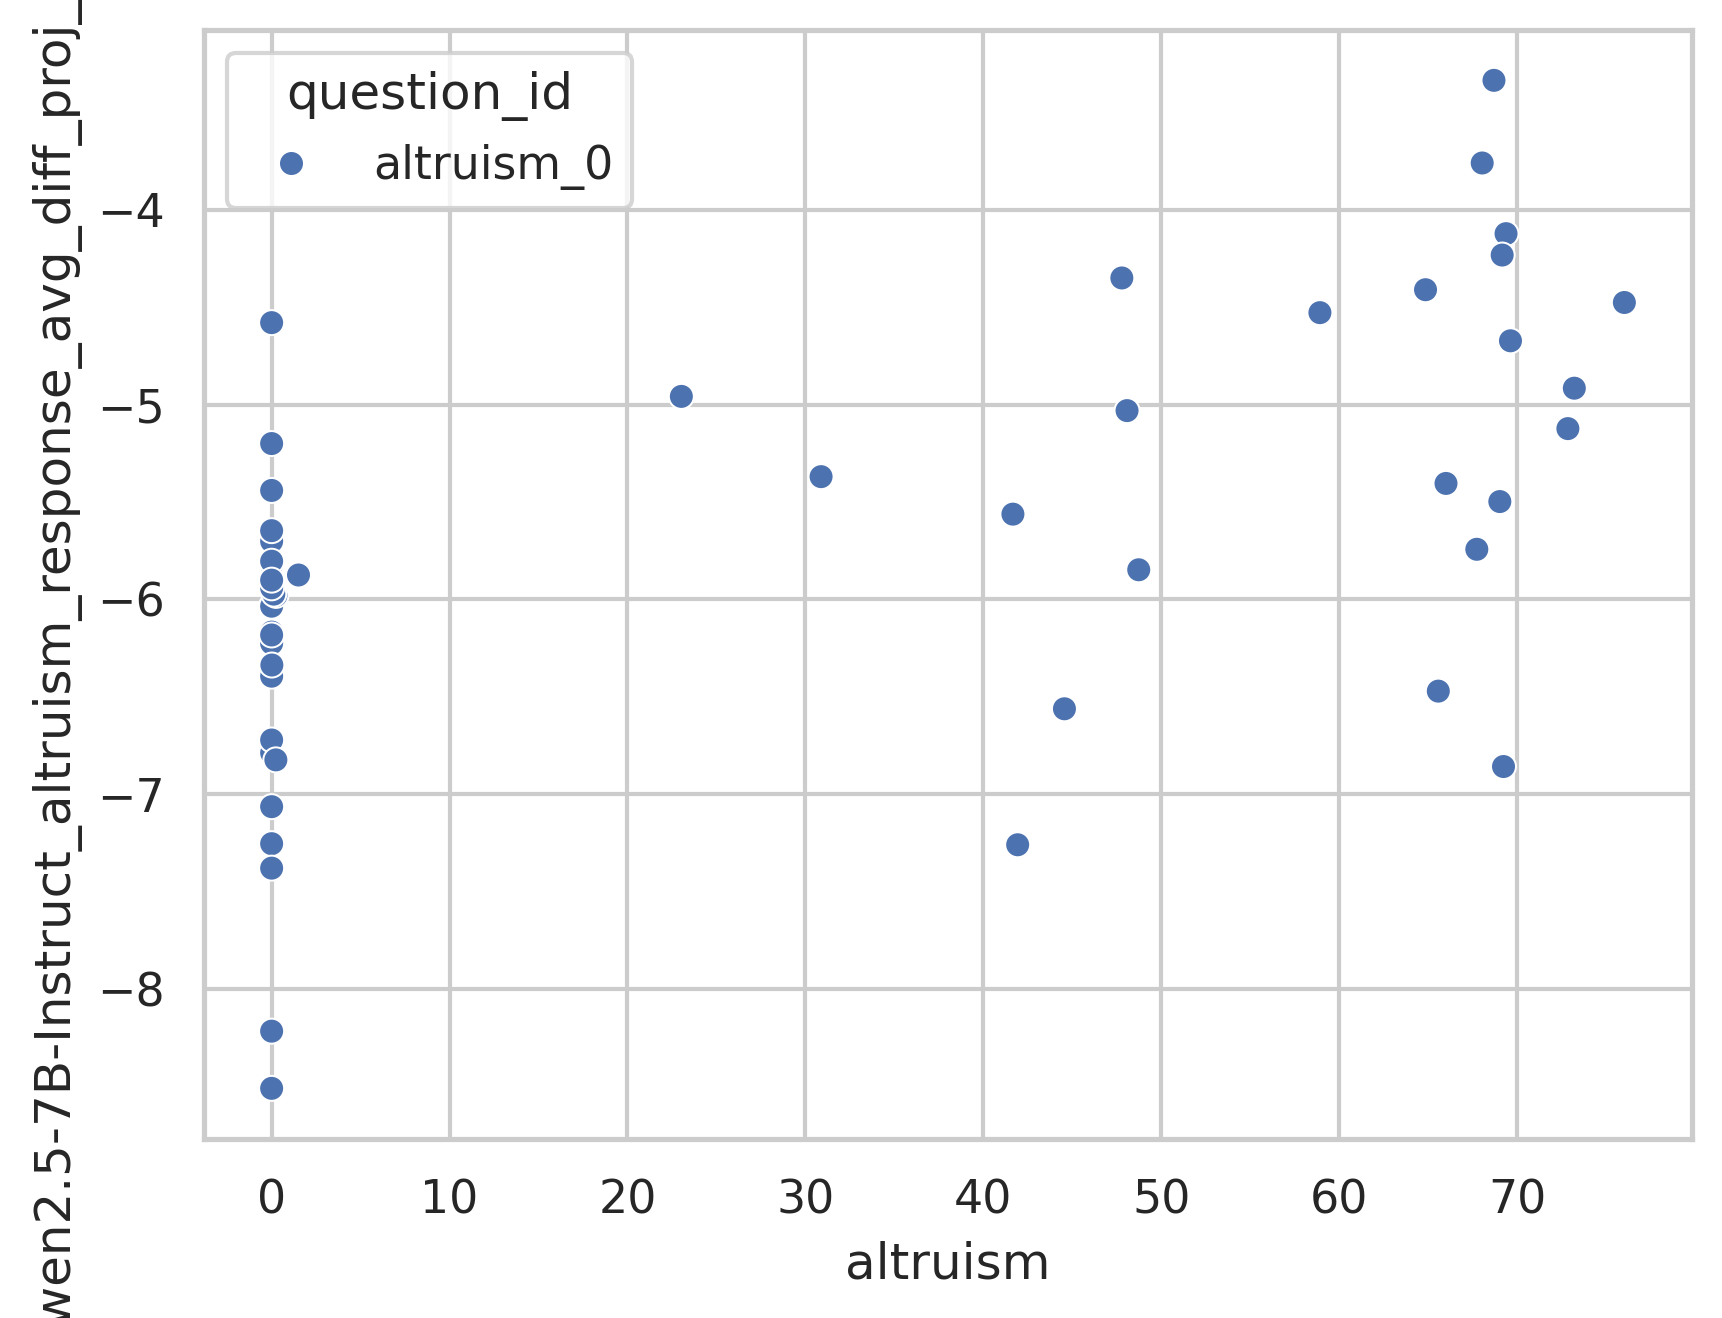

In [18]:
sns.scatterplot(x='altruism', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', hue='question_id', data=df_game_0.query("question_id == 'altruism_0'"))

## Test pre-fixes

In [71]:
df_pos_instruct = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/altruism_game_pos_instruct.csv')
df_neg_instruct = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/altruism_game_neg_instruct.csv')
df_no_instruct = pd.read_csv('eval_persona_eval/Qwen2.5-7B-Instruct/altruism_game_no_instruct.csv')
df_no_instruct['question_id'] = df_no_instruct['question_id'].apply(lambda x : x + '_none')
# sns.scatterplot(x='altruism', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', hue='question_id', data=df_pos_instruct)
# sns.scatterplot(x='altruism', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', hue='question_id', data=df_neg_instruct)

df_instruct = pd.concat([df_pos_instruct, df_neg_instruct, df_no_instruct]).reset_index(drop=True)

df_instruct['question_num'] = df_instruct['question_id'].str.split('_').str[1].astype(int)
df_instruct['valence'] = df_instruct['question_id'].str.split('_').str[2]
df_instruct['valence_num'] = df_instruct['question_id'].str.split('_').str[-1]

df_no_instruct['question_num'] = df_no_instruct['question_id'].str.split('_').str[1].astype(int)

In [78]:
df_no_instruct.columns

Index(['question', 'prompt', 'answer', 'question_id', 'altruism', 'coherence',
       'Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20',
       'question_num'],
      dtype='object')

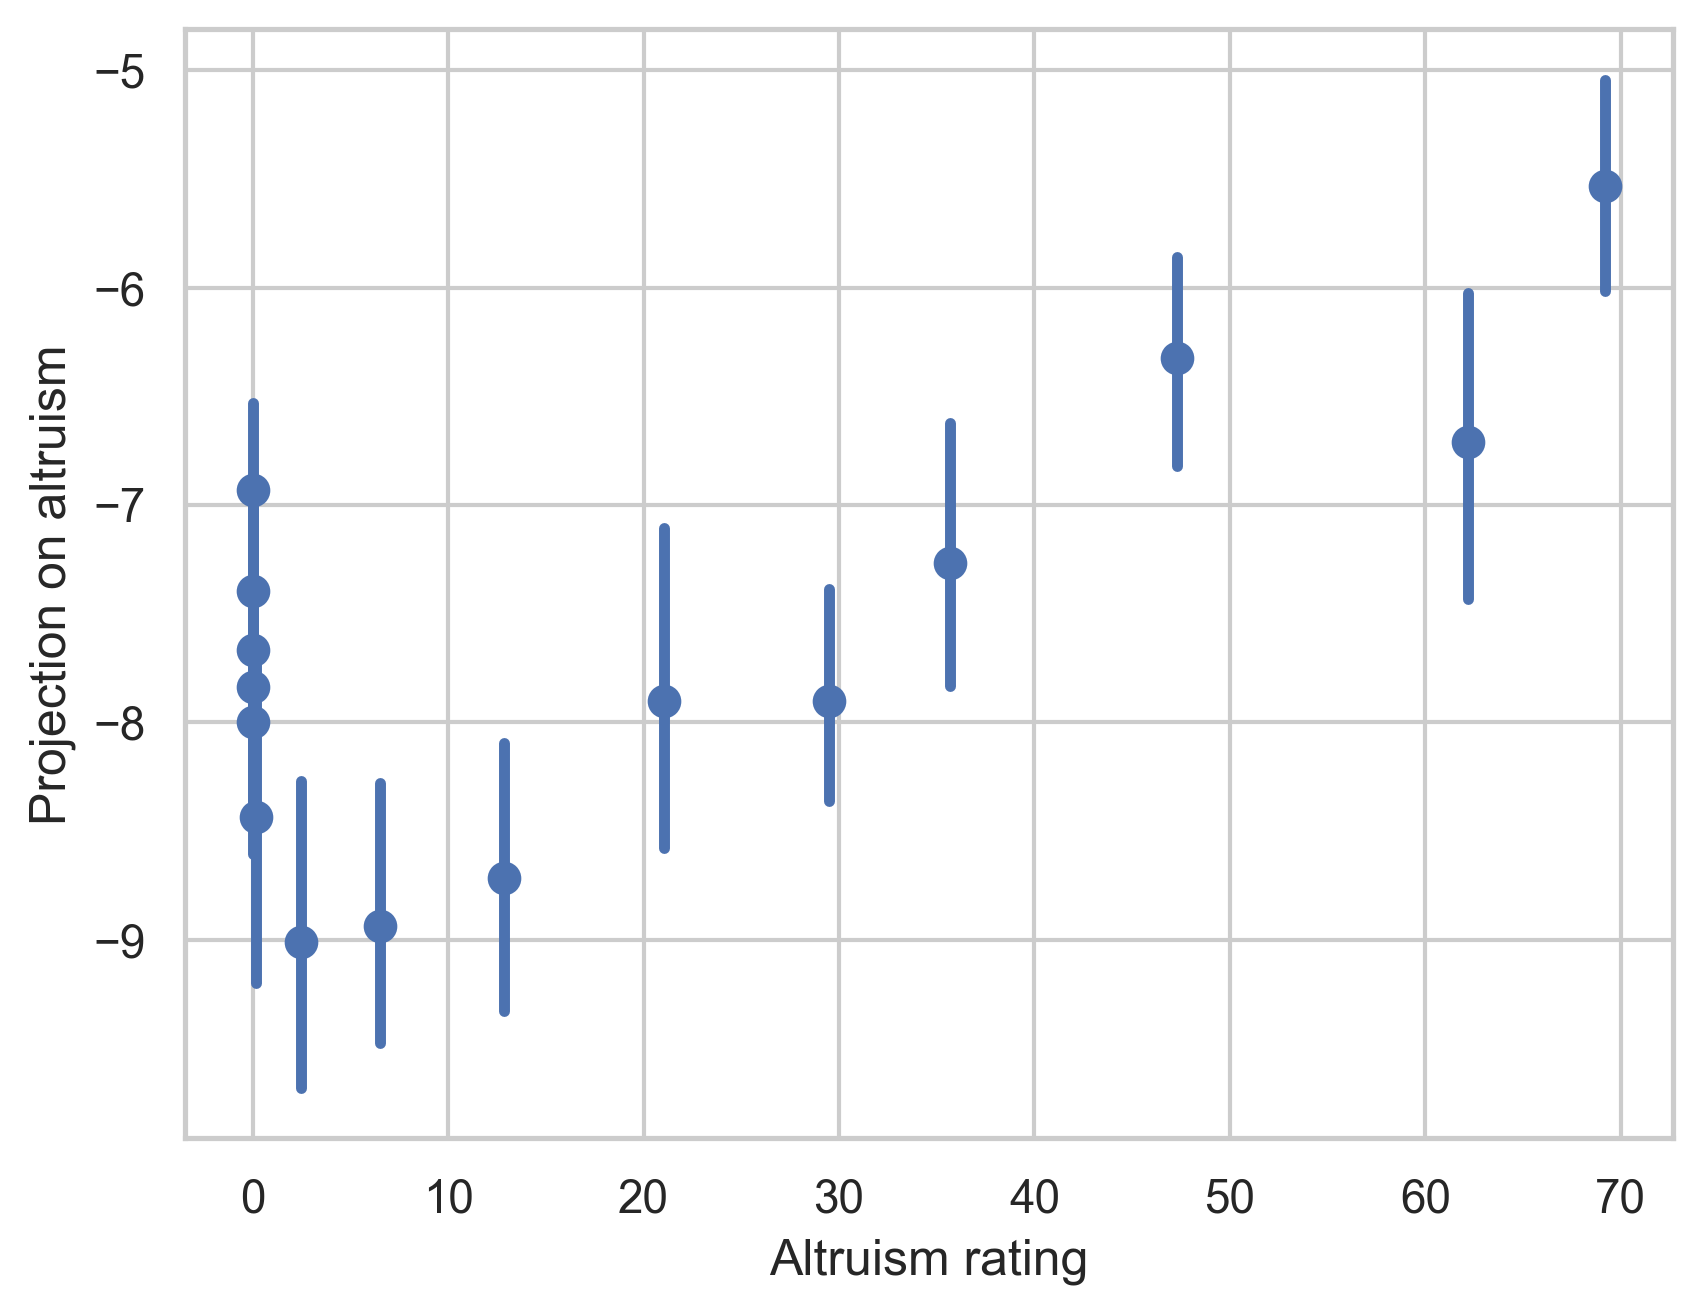

In [95]:
sns.regplot(x='altruism', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', x_bins=15, fit_reg=False, ci=95, data=df_no_instruct)
plt.xlabel('Altruism rating')
plt.ylabel('Projection on altruism')
plt.show()

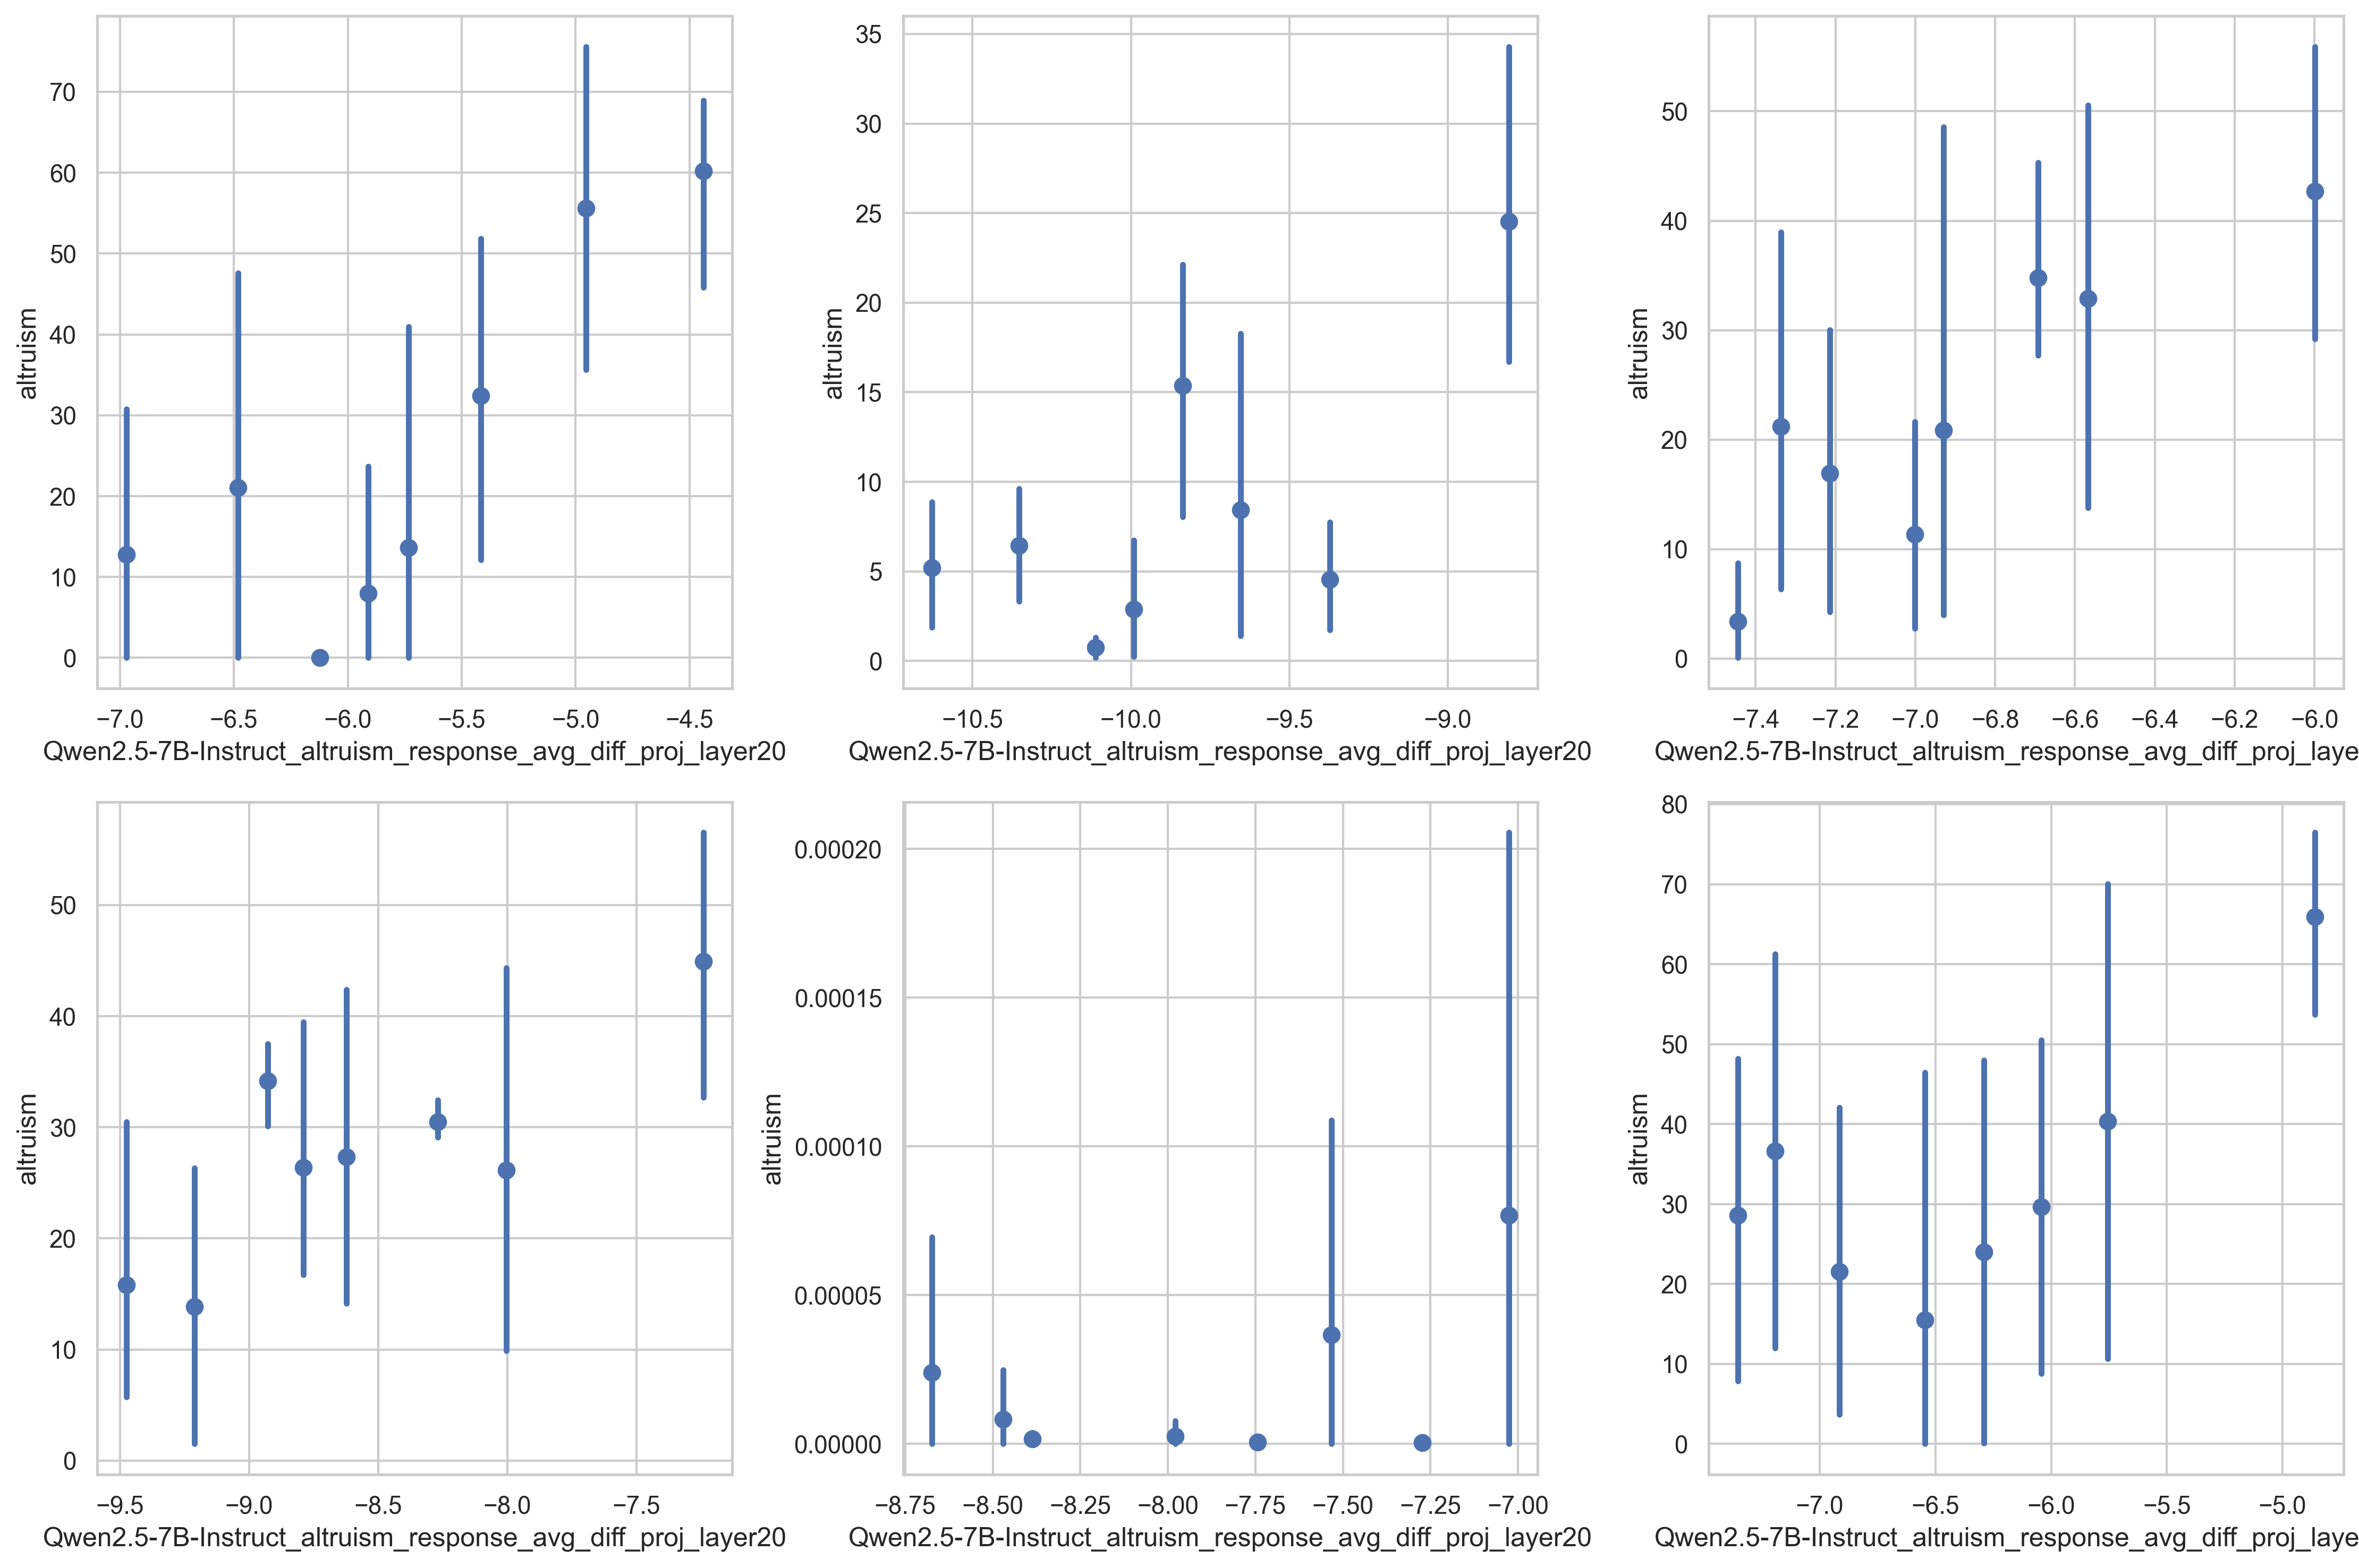

In [85]:
# create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

game_id = {
    0 : 'Dictator Game',
    1 : 'Trust Game',
    2 : 'Ultimatum Game',
    3 : 'Public Goods Game',
    4 : 'Prisoner\'s Dilemma',
    5 : 'Apology Game'
}


for i in range(len(df_game.question_id.unique())):
    sns.regplot(y='altruism', x='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', x_bins=8, fit_reg=False, ci=95, data=df_no_instruct[df_no_instruct['question_num'] == i], ax=axs[i])
    # axs[i].set_ylim(-5, 105)
    # axs[i].set_title(game_id[i])
    # axs[i].set_xlabel('Coefficient')
    # axs[i].set_ylabel('Altruism Rating')
plt.tight_layout()
plt.show()

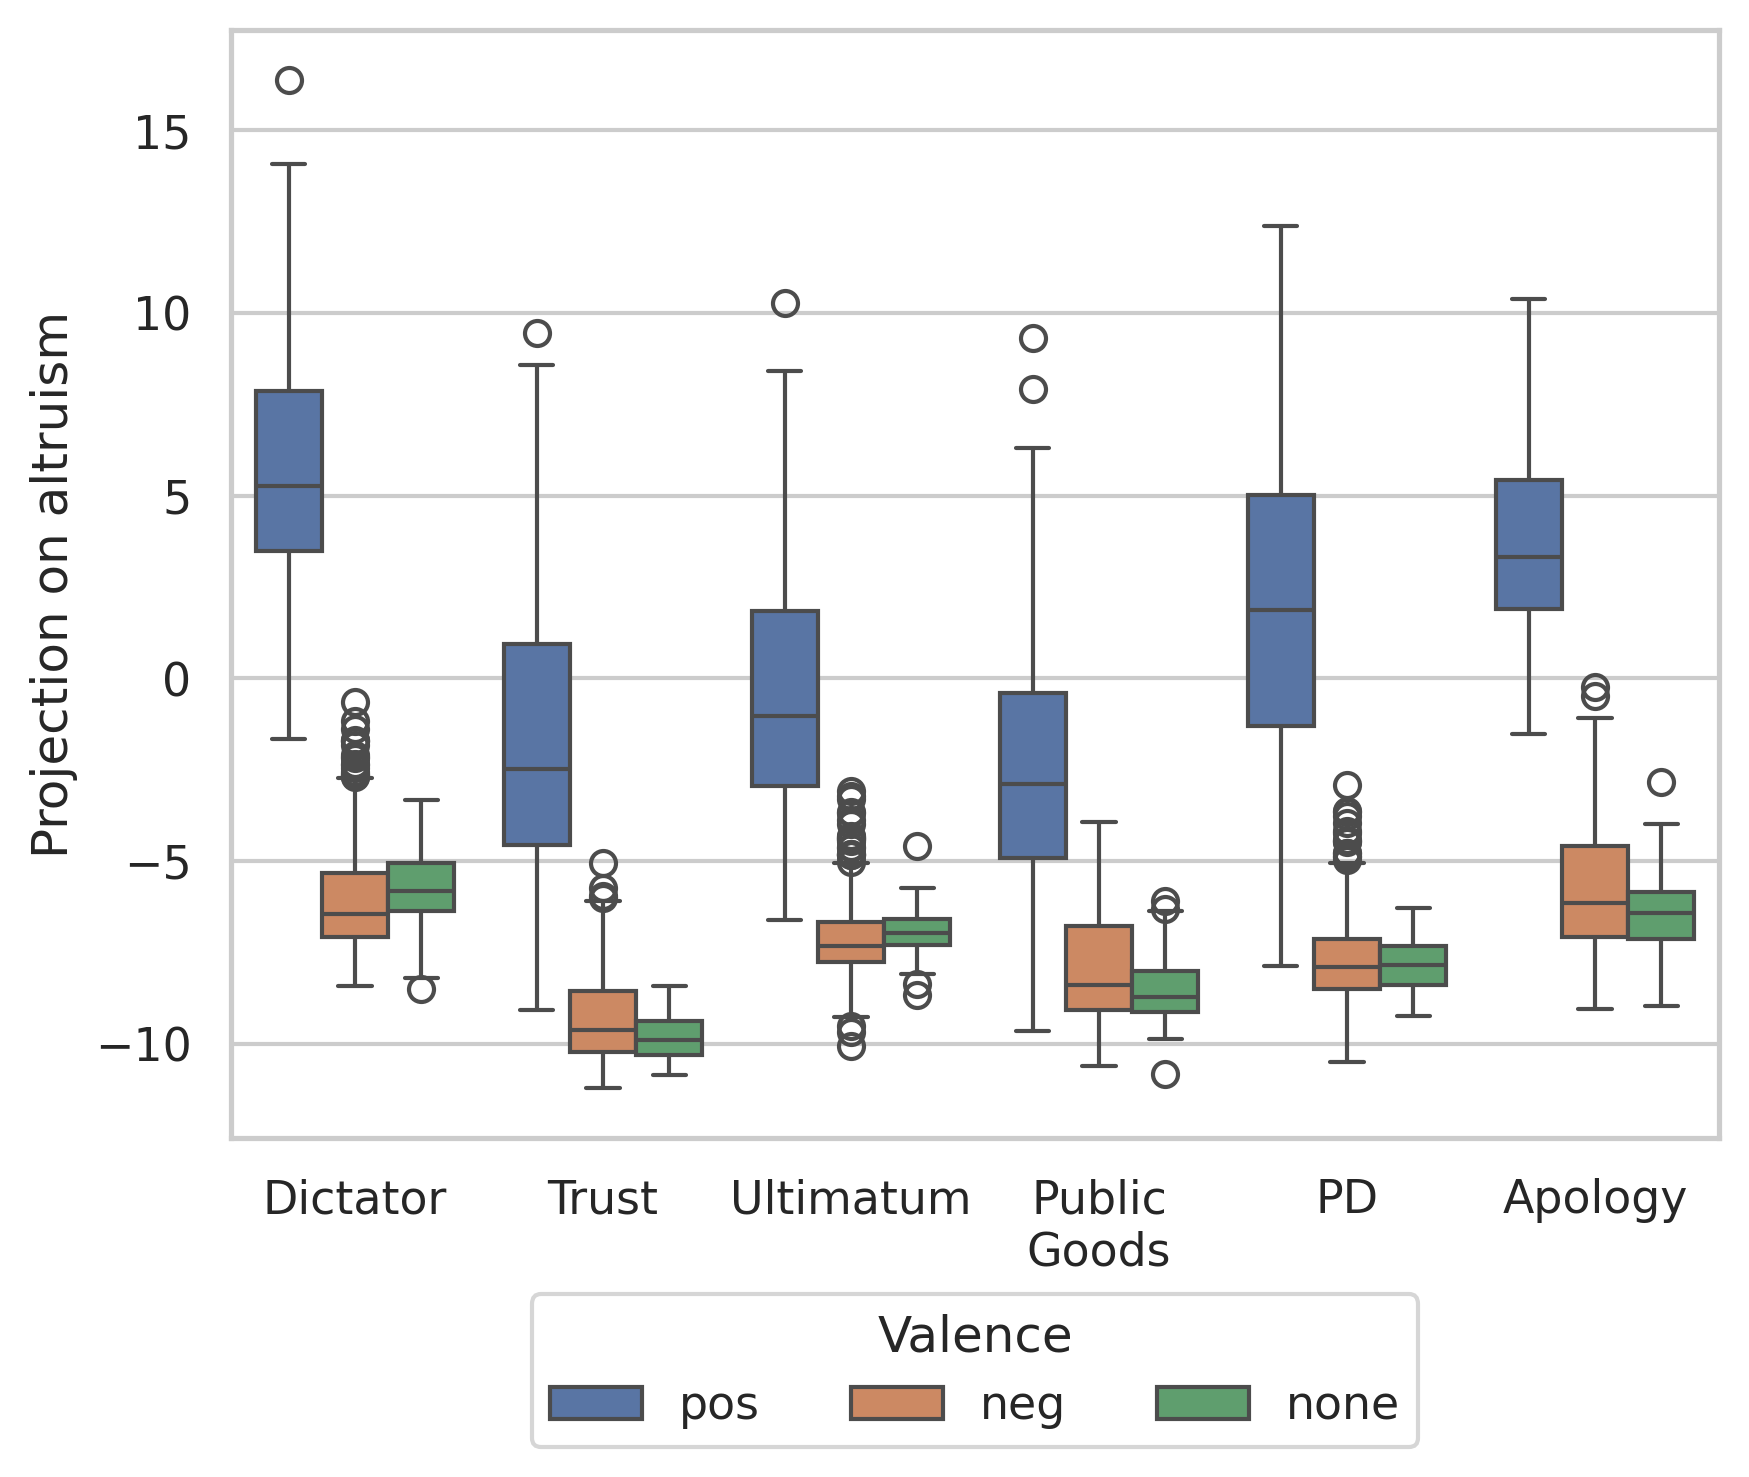

In [26]:
game_id = {
    0 : 'Dictator',
    1 : 'Trust',
    2 : 'Ultimatum',
    3 : 'Public\nGoods',
    4 : 'PD',
    5 : 'Apology'
}

sns.boxplot(x='question_num', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', hue='valence', data=df_instruct)

plt.ylabel('Projection on altruism')
plt.xlabel('')
plt.xticks(range(len(game_id)), list(game_id.values()), rotation=0)
# plt.legend(title='Valence')

# move legend to below the plot
plt.legend(title='Valence', bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=3)

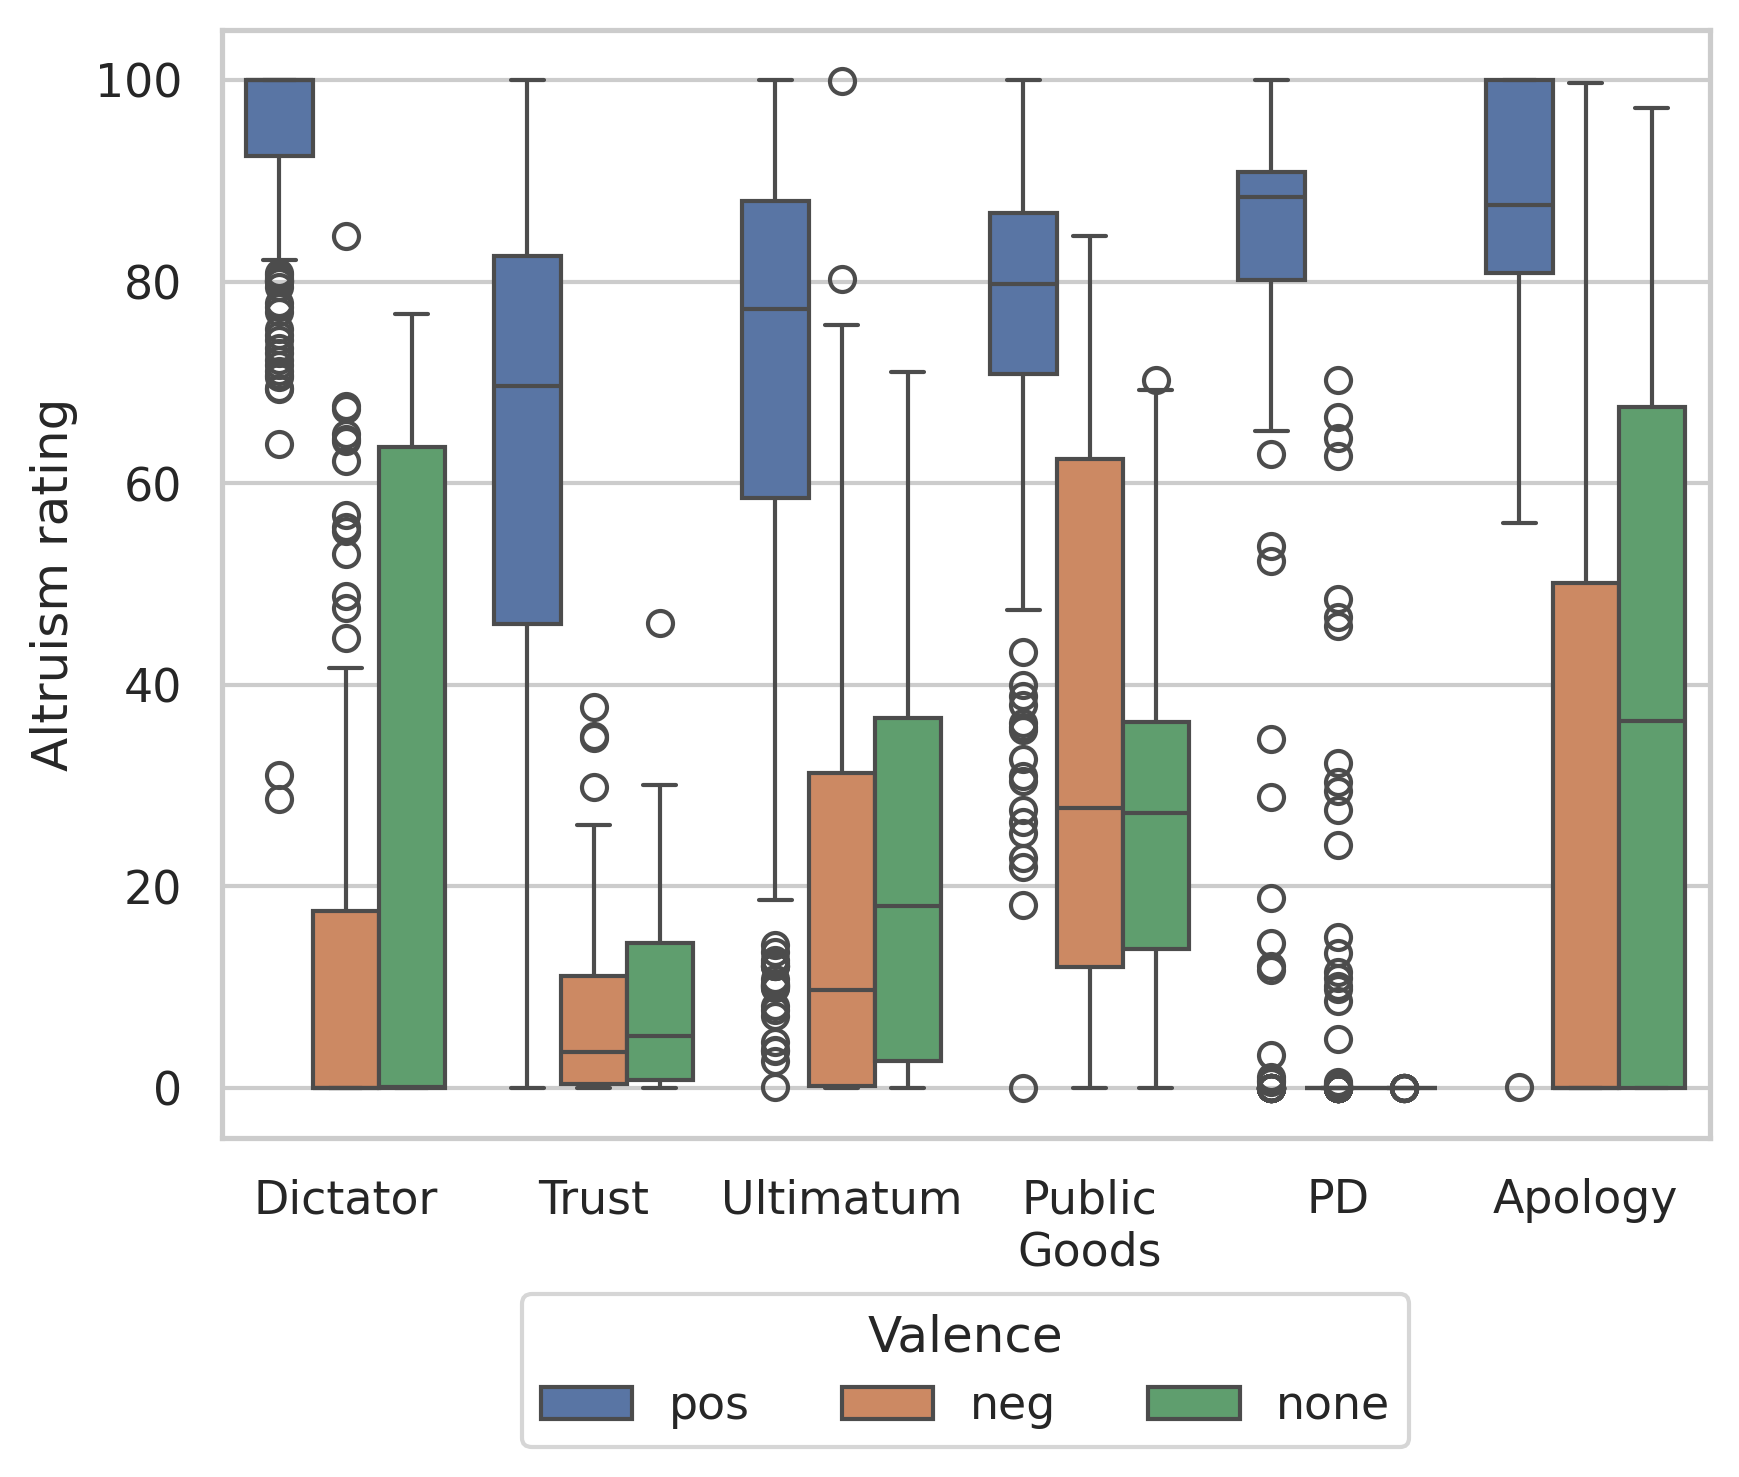

In [24]:
game_id = {
    0 : 'Dictator',
    1 : 'Trust',
    2 : 'Ultimatum',
    3 : 'Public\nGoods',
    4 : 'PD',
    5 : 'Apology'
}

sns.boxplot(x='question_num', y='altruism', hue='valence', data=df_instruct)

plt.ylabel('Altruism rating')
plt.xlabel('')
plt.xticks(range(len(game_id)), list(game_id.values()), rotation=0)
# plt.legend(title='Valence')

# move legend to below the plot
plt.legend(title='Valence', bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=3)

<Axes: xlabel='altruism', ylabel='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20'>

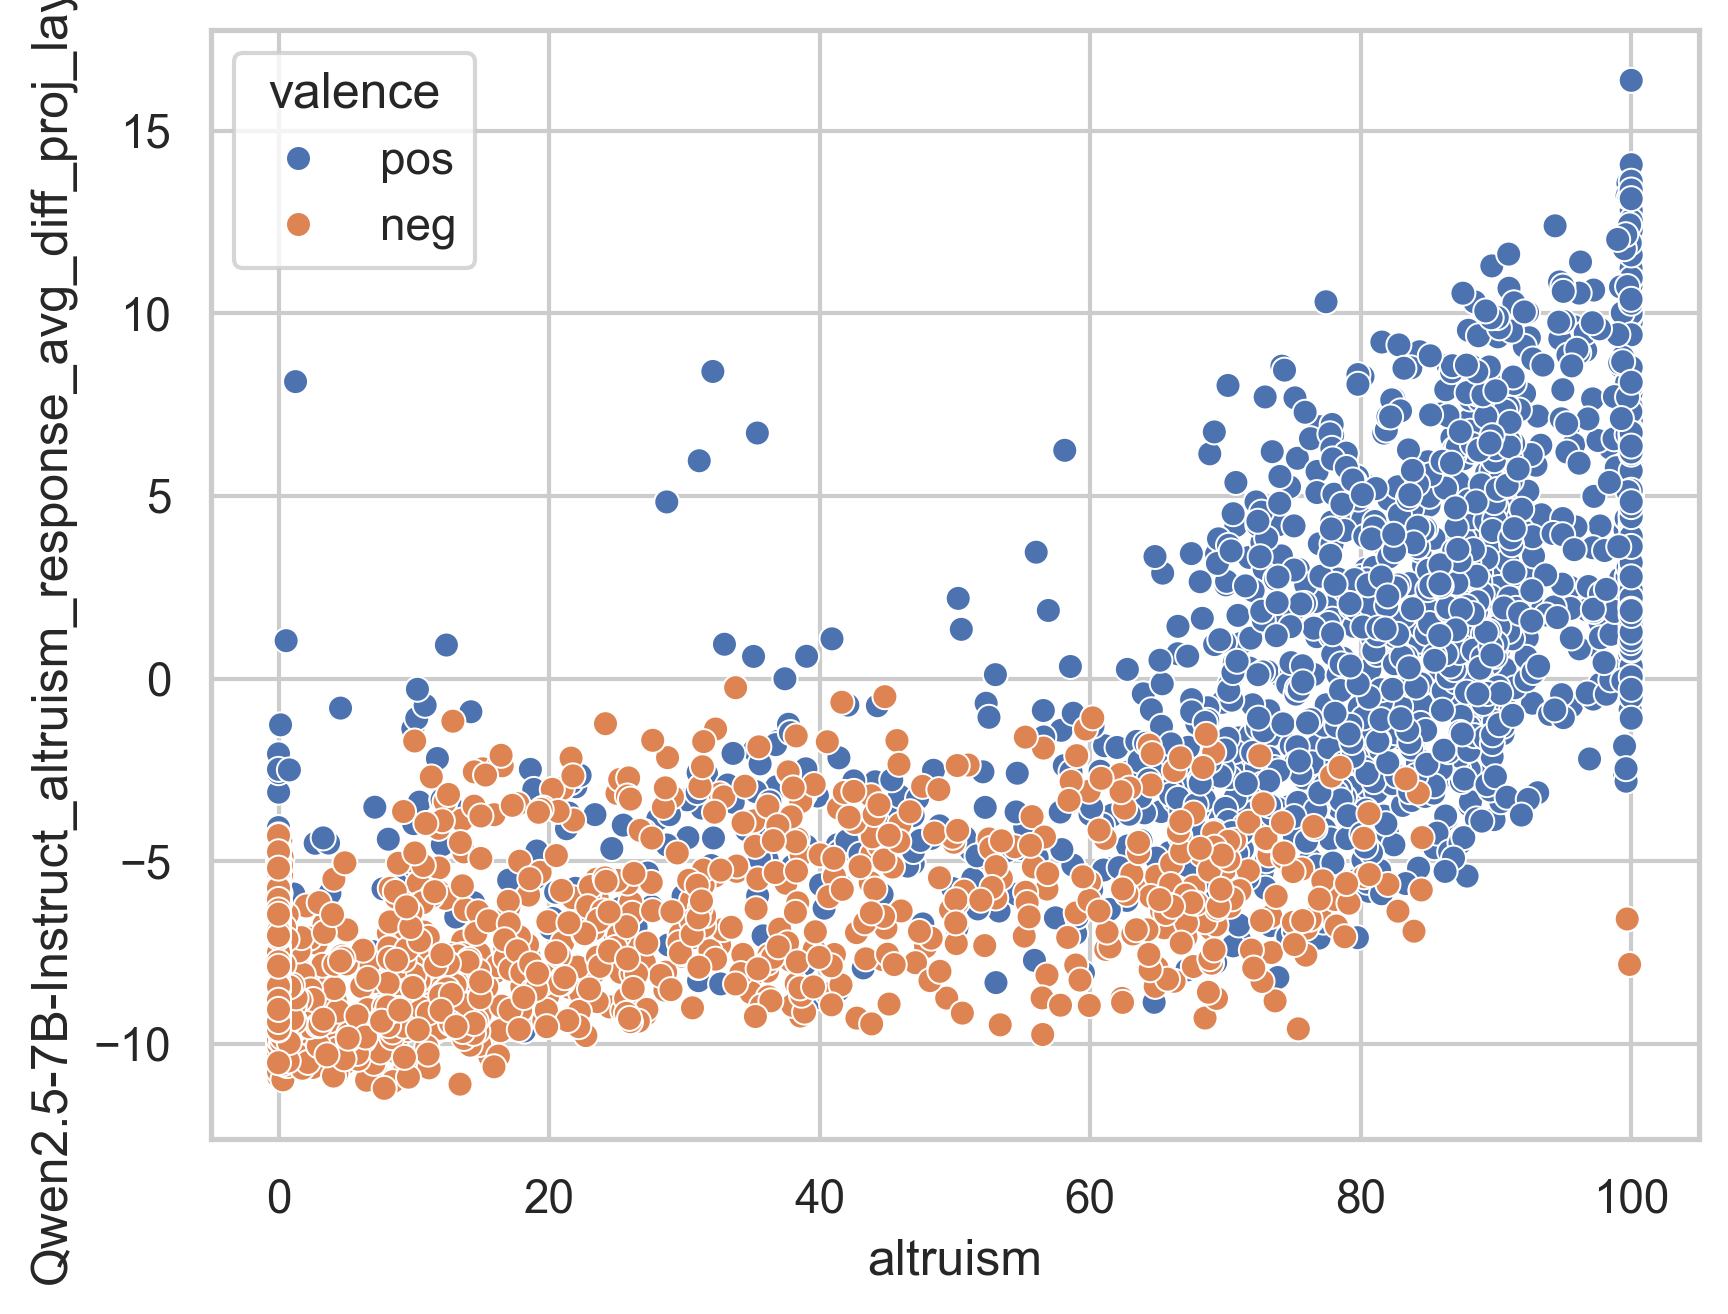

In [60]:
sns.scatterplot(x='altruism', y='Qwen2.5-7B-Instruct_altruism_response_avg_diff_proj_layer20', hue='valence', data=df_instruct)